# Target Authors citations analysis


In [3]:
from pyalex import Works, Authors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from scipy import stats
from scipy.stats import gaussian_kde
from pyalex import Sources
from collections import defaultdict

warnings.filterwarnings("ignore")
from scipy.stats import chi2_contingency

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

# ── Topic level for analysis ───────────────────────────────────────────────────
# Options: "topic_domain", "topic_field", "topic_subfield", "primary_topic"
TOPIC_COL = "primary_topic"
TOPIC_LEVEL_LABEL = TOPIC_COL.replace("topic_", "").replace("_", " ").capitalize()
ACTUAL_Y= pd.Timestamp.now().year
MIN_SHARED_PAPERS = 30

<!-- ##Function and Variables definitions -->

In [4]:
#--main helper funtions-----------------

# ── Target_author authors of interest ────────────────────────────────────────────────
author_ids = {
    "https://openalex.org/A5064124035": "Ciampitti",
    "https://openalex.org/A5074248754": "Basso",
    "https://openalex.org/A5053935458": "Kaiyu",
    "https://openalex.org/A5005128316": "Grassini",
    "https://openalex.org/A5010412338": "Archontoulis",
    "https://openalex.org/A5073947803": "Castellano",
    "https://openalex.org/A5026642372": "Lobell",
    "https://openalex.org/A5073721257": "Peng",
    "https://openalex.org/A5050045466": "Vara Prasad",
    "https://openalex.org/A5072153127": "Rattalino",
    "https://openalex.org/A5047677277": "Hoogenboom",
    "https://openalex.org/A5089812471": "Messina",
}
coauthors_ids = {}

# Coauthor eligibility criterion: must share at least this many DISTINCT papers
# with the target-author set (counted across all target authors).
MIN_SHARED_PAPERS = 30

def get_works(author_ids_dict, from_date="2018-01-01", to_date="2025-12-31"):
    """Fetch all works for a dict of {openalex_id: name}, enriching each work
    with queried_author, queried_author_id, author_position, and
    is_corresponding_author. If date filtering returns zero results, fall back
    to a publication_year range filter."""
    works_list = []
    author_stats = {}
    for aid, name in author_ids_dict.items():
        print(f"  Fetching: {name} …", end=" ")
        cursor = "*"
        n = 0
        try:
            year_range = f"{int(str(from_date)[:4])}-{int(str(to_date)[:4])}"
        except (TypeError, ValueError):
            year_range = None
        use_year_range = False
        if aid not in author_stats:
            try:
                author = Authors()[aid]
                summary = author.get("summary_stats") or {}
                author_stats[aid] = {
                    "h_index": summary.get("h_index"),
                    "i10_index": summary.get("i10_index"),
                }
            except Exception:
                author_stats[aid] = {"h_index": None, "i10_index": None}
        while cursor:
            if use_year_range and year_range:
                filters = {
                    "author.id": aid,
                    "publication_year": year_range,
                }
            else:
                filters = {
                    "author.id": aid,
                    "from_publication_date": from_date,
                    "to_publication_date": to_date,
                }
            results = Works().filter(**filters).get(per_page=200, cursor=cursor)
            if (not use_year_range) and year_range and results.meta.get("count", 0) == 0:
                # Fallback to year-range filter when date filter yields nothing.
                use_year_range = True
                cursor = "*"
                continue
            for work in results:
                author_position, is_corresponding = None, False
                for auth in work.get("authorships", []):
                    if auth.get("author", {}).get("id") == aid:
                        author_position = auth.get("author_position")
                        is_corresponding = auth.get("is_corresponding", False)
                        break
                work["queried_author"] = name
                work["queried_author_id"] = aid
                work["queried_author_h_index"] = author_stats[aid].get("h_index")
                work["queried_author_i10_index"] = author_stats[aid].get("i10_index")
                work["author_position"] = author_position
                work["is_corresponding_author"] = is_corresponding
                works_list.append(work)
                n += 1
            next_cursor = results.meta.get("next_cursor")
            cursor = next_cursor if next_cursor != cursor else None
            time.sleep(0.5)
    print(f"\nTotal works fetched: {len(works_list)}")
    return works_list

from pyalex import Sources
import pandas as pd

def get_journal_impact_factors(works_list):
    """
    Extract unique journals from a works_list (output of get_works) and
    fetch their 2yr_mean_citedness (impact factor equivalent) from OpenAlex.

    Returns a DataFrame with columns: journal_name, impact_factor
    """
    # Extract unique source IDs from works
    source_ids = {}
    for work in works_list:
        loc = work.get("primary_location") or {}
        source = loc.get("source") or {}
        sid = source.get("id")
        sname = source.get("display_name")
        if sid and sname:
            source_ids[sid] = sname  # deduplicate by ID

    print(f"  Found {len(source_ids)} unique journals. Fetching IFs…")

    rows = []
    for sid, fallback_name in source_ids.items():
        try:
            source_obj = Sources()[sid]
            name = source_obj.get("display_name") or fallback_name
            stats = source_obj.get("summary_stats") or {}
            impact_factor = stats.get("2yr_mean_citedness")
            rows.append({"journal_name": name, "impact_factor": impact_factor})
            time.sleep(0.3)
        except Exception as e:
            print(f"  Warning: could not fetch {sid}: {e}")
            rows.append({"journal_name": fallback_name, "impact_factor": None})

    df = pd.DataFrame(rows).sort_values("impact_factor", ascending=False).reset_index(drop=True)
    return df

def get_prolific_coauthors(
    Target_author_works,
    author_ids,
    coauthors_ids,
    min_shared_papers: int = MIN_SHARED_PAPERS,
    top_n: int | None = None,
 ):
    """
    Return {author_id: name} for co-authors who have collaborated with the
    target-author set on at least `min_shared_papers` DISTINCT papers.

    - Shared-paper count is based on distinct OpenAlex work IDs, so duplicates
      in `Target_author_works` (from querying multiple target authors) do not
      inflate counts.
    - Excludes anyone already in `author_ids` or `coauthors_ids`.
    - Updates both `author_ids` and `coauthors_ids` in-place with the new entries.
    - If `top_n` is provided, only the top_n by shared-paper count are returned;
      otherwise, all eligible coauthors are returned.
    """
    already_tracked = set(author_ids.keys()) | set(coauthors_ids.keys())

    shared_papers_by_aid = defaultdict(set)  # aid -> {work_id, ...}
    name_by_aid = {}
    for work in Target_author_works:
        work_id = work.get("id")
        if not work_id:
            continue
        qid = work.get("queried_author_id")
        for auth in work.get("authorships", []):
            author = auth.get("author") or {}
            aid = author.get("id")
            name = author.get("display_name")
            # Skip if same as the queried author, already tracked, or missing id
            if not aid or aid == qid or aid in already_tracked:
                continue
            shared_papers_by_aid[aid].add(work_id)
            if aid not in name_by_aid and name:
                name_by_aid[aid] = name

    eligible = [
        (aid, name_by_aid.get(aid), len(work_ids))
        for aid, work_ids in shared_papers_by_aid.items()
        if len(work_ids) >= min_shared_papers
    ]
    eligible.sort(key=lambda x: (x[2], x[1] or ""), reverse=True)

    if top_n is not None:
        eligible = eligible[:top_n]

    new_coauthors = {}
    for aid, name, n_shared in eligible:
        display_name = name or aid
        print(f"  {display_name}: {n_shared} shared papers")
        new_coauthors[aid] = display_name

    print(f"Selected coauthors: {len(new_coauthors)} (min_shared_papers={min_shared_papers})")

    # Add to both lists
    coauthors_ids.update(new_coauthors)
    author_ids.update(new_coauthors)

    return new_coauthors

def get_publications_table(works_list):
    """
    Flatten raw OpenAlex works into a tidy DataFrame.
    Extracts only fields present in needed_cols, keeping display names
    and counts while dropping IDs, URLs, and scores.
    """
    rows = []
    for work in works_list:
        pub_year = work.get("publication_year")

        # ── counts_by_year → year-offset citation columns ──────────────────
        citation_counts = {}
        for entry in work.get("counts_by_year", []):
            year  = entry.get("year")
            count = entry.get("cited_by_count", 0)
            if year and pub_year and year >= pub_year:
                citation_counts[f"citations_year_{year - pub_year}"] = count

        # ── authorships → team size ────────────────────────────────────────
        n_authors = len(work.get("authorships", []))

        # ── topics → hierarchy ─────────────────────────────────────────────
        topics = work.get("topics") or []
        primary_topic  = topics[0] if topics else {}
        topic_name     = primary_topic.get("display_name")
        topic_subfield = (primary_topic.get("subfield") or {}).get("display_name")
        topic_field    = (primary_topic.get("field")    or {}).get("display_name")
        topic_domain   = (primary_topic.get("domain")   or {}).get("display_name")

        # ── concepts → names only ─────────────────────────────────────────
        concepts = sorted(
            work.get("concepts") or [],
            key=lambda c: c.get("score", 0), reverse=True
        )
        concept_names = [c["display_name"] for c in concepts[:5] if c.get("display_name")]

        # ── keywords ──────────────────────────────────────────────────────
        keyword_names = [
            kw["display_name"]
            for kw in (work.get("keywords") or [])
            if kw.get("display_name")
        ]

        # ── SDGs ──────────────────────────────────────────────────────────
        sdg_names = [
            sdg["display_name"]
            for sdg in (work.get("sustainable_development_goals") or [])
            if sdg.get("display_name")
        ]

        # ── references ────────────────────────────────────────────────────
        n_references = len(work.get("referenced_works") or [])

        # ── percentiles ───────────────────────────────────────────────────
        pct_year       = work.get("cited_by_percentile_year") or {}
        percentile_min = pct_year.get("min")
        percentile_max = pct_year.get("max")

        norm_pct                 = work.get("citation_normalized_percentile") or {}
        citation_norm_percentile = norm_pct.get("value")

       
        # ── journal (FIX robusto) ─────────────────────────────────────────
        primary_location = work.get("primary_location") or {}
        source = primary_location.get("source") or {}

        journal_display_name = source.get("display_name")
        journal_publisher = source.get("host_organization_name")

        # ── open_access ───────────────────────────────────────────────────
        oa        = work.get("open_access") or {}
        is_oa     = oa.get("is_oa", False)
        oa_status = oa.get("oa_status")

        rows.append({
            "article_id":               work.get("id"),
            "title":                    work.get("title", ""),
            "publication_date":         work.get("publication_date"),
            "publication_year":         pub_year,
            "type":                     work.get("type"),
            "author_type":              work.get("author_type"),
            "queried_author":           work.get("queried_author"),
            "general_h_index":   work.get("queried_author_h_index"),
            "general_i10_index": work.get("queried_author_i10_index"),
            "author_position":          work.get("author_position"),
            "is_corresponding_author":  work.get("is_corresponding_author", False),
            "n_authors":                n_authors,
            "journal_display_name":     journal_display_name,
            "journal_publisher":        journal_publisher,
            "is_oa":                    is_oa,
            "oa_status":                oa_status,
            "primary_topic":            topic_name,
            "topic_subfield":           topic_subfield,
            "topic_field":              topic_field,
            "topic_domain":             topic_domain,
            "top_concepts":             concept_names,
            "keywords":                 keyword_names,
            "sdgs":                     sdg_names,
            "total_citations":          work.get("cited_by_count", 0),
            "percentile_min":           percentile_min,
            "percentile_max":           percentile_max,
            "citation_norm_percentile": citation_norm_percentile,
            "n_references":             n_references,
            **citation_counts,
        })

    df = pd.DataFrame(rows)
    df["total_citations"] = df["total_citations"].fillna(0)
    # Total citations by author across this table
    df["author_total_citations"] = df.groupby("queried_author")["total_citations"].transform("sum")
    df.sort_values("total_citations", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

def dedup_assign_to_corresponding(df):
    """
    Keep only corresponding-author rows for duplicate papers.
    If no corresponding author exists in the group, keep all rows.
    """
    def _pick(group):
        if group["is_corresponding_author"].any():
            return group[group["is_corresponding_author"]]
        return group

    df = df.copy()
    df["_article_id"] = df["article_id"]
    result = (
        df.groupby("_article_id", sort=False, group_keys=False)
        .apply(_pick)
    )
    result = result.reset_index()
    if "article_id" not in result.columns and "_article_id" in result.columns:
        result = result.rename(columns={"_article_id": "article_id"})
    if "_article_id" in result.columns:
        result = result.drop(columns=["_article_id"])
    return result

def print_dedup_report(name, df_raw, df_dedup):
    group = df_raw.groupby("article_id")
    n_groups = group.ngroups
    has_corr = group["is_corresponding_author"].any()
    n_with_corr = int(has_corr.sum())
    n_without_corr = int((~has_corr).sum())
    kept_from_corr = df_dedup["is_corresponding_author"].sum()
    kept_from_noncorr = len(df_dedup) - kept_from_corr
    print(f"\n[{name}]")
    print(f"  Raw rows: {len(df_raw):,}")
    print(f"  Unique papers: {n_groups:,}")
    print(f"  Papers with corresponding author in group: {n_with_corr:,}")
    print(f"  Papers without corresponding author in group: {n_without_corr:,}")
    print(f"  Dedup rows kept (from corr): {int(kept_from_corr):,}")
    print(f"  Dedup rows kept (from non-corr): {int(kept_from_noncorr):,}")

def _resolve_id_column(df):
    for col in ["article_id", "id", "work_id"]:
        if col in df.columns:
            return col
    id_like = [c for c in df.columns if "id" in c.lower()]
    if len(id_like) == 1:
        return id_like[0]
    return None

def _build_fallback_key(df):
    title = df.get("title", "").fillna("")
    pub_date = df.get("publication_date", "").fillna("")
    pub_year = df.get("publication_year", "").fillna("")
    return title.astype(str) + "|" + pub_date.astype(str) + "|" + pub_year.astype(str)

def print_author_keep_counts(name, df_dedup):
    if "queried_author" not in df_dedup.columns:
        print(f"\n[{name} - kept papers by author]")
        print("  Skipped: missing 'queried_author'.")
        return
    id_col = _resolve_id_column(df_dedup)
    if id_col is None:
        paper_key = _build_fallback_key(df_dedup)
        author_keep = (
            df_dedup.assign(_paper_key=paper_key)
            .groupby("queried_author")
            .agg(
                kept_papers=("_paper_key", "nunique"),
                kept_as_corr=("is_corresponding_author", "sum"),
            )
            .sort_values("kept_papers", ascending=False)
        )
        print(f"\n[{name} - kept papers by author]")
        print("  Using fallback paper key (title|publication_date|publication_year).")
        print(author_keep.to_string())
        return
    author_keep = (
        df_dedup.groupby("queried_author")
        .agg(
            kept_papers=(id_col, "nunique"),
            kept_as_corr=("is_corresponding_author", "sum"),
        )
        .sort_values("kept_papers", ascending=False)
    )
    print(f"\n[{name} - kept papers by author]")
    print(author_keep.to_string())
    
# ── Reconstruct abstract from inverted index ──────────────────────────────────
def reconstruct_abstract(inverted_index: dict | None) -> str:
    """
    OpenAlex stores abstracts as an inverted index:
        { "word": [pos1, pos2, ...], ... }
    This function inverts it back into a readable string.
    Returns an empty string if the index is None or empty.
    """
    if not inverted_index:
        return ""
    # Build a (position → word) mapping and sort by position
    position_word = {}
    for word, positions in inverted_index.items():
        for pos in positions:
            position_word[pos] = word
    return " ".join(position_word[p] for p in sorted(position_word))

def calculate_author_metrics(df, author_col='author_id', citations_col='cited_by_count'):
    """
    Calculate H-index and i10-index for each author and return a summary DataFrame.
    
    Parameters:
    - df: pandas DataFrame with author and citation info
    - author_col: column name for author identifier
    - citations_col: column name for citation counts
    
    Returns:
    - metrics_df: DataFrame with one row per author and columns: ['h_index', 'i10_index']
    """
    metrics_list = []

    for author, group in df.groupby(author_col):
        citations = sorted(group[citations_col], reverse=True)
        
        # Calculate H-index
        h_index = 0
        for i, c in enumerate(citations, start=1):
            if c >= i:
                h_index = i
            else:
                break
        
        # Calculate i10-index
        i10_index = sum(c >= 10 for c in citations)
        
        metrics_list.append({
            author_col: author,
            'h_index': h_index,
            'i10_index': i10_index
        })
    
    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df

def calculate_group_metrics(df, group_col, citations_col='cited_by_count'):
    """
    Calculate H-index, i10-index, mean and median citations for each group (journal or topic).
    
    Parameters:
    - df: pandas DataFrame with group (journal/topic) and citation info
    - group_col: column name to group by (e.g., 'journal_name' or 'primary_topic')
    - citations_col: column name for citation counts
    
    Returns:
    - metrics_df: DataFrame with one row per group and columns:
        ['h_index', 'i10_index', 'mean_citations', 'median_citations']
    """
    metrics_list = []

    for group, group_df in df.groupby(group_col):
        citations = sorted(group_df[citations_col], reverse=True)
        
        # H-index
        h_index = 0
        for i, c in enumerate(citations, start=1):
            if c >= i:
                h_index = i
            else:
                break
        
        # i10-index
        i10_index = sum(c >= 10 for c in citations)
        
        metrics_list.append({
            group_col: group,
            'h_index': h_index,
            'i10_index': i10_index,
            'mean_citations': group_df[citations_col].mean(),
            'median_citations': group_df[citations_col].median()
        })
    
    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df

# --- Helper function to calculate cumulative metrics ---
def cumulative_metrics(group_df):
    years = sorted(group_df['publication_year'].unique())
    cumulative_h_index = []
    cumulative_mean = []
    cumulative_median = []
    
    for year in years:
        df_cum = group_df[group_df['publication_year'] <= year]
        citations = df_cum['total_citations'].tolist()
        citations.sort(reverse=True)
        
        # H-index
        h_index = 0
        for i, c in enumerate(citations, start=1):
            if c >= i:
                h_index = i
            else:
                break
        cumulative_h_index.append(h_index)
        
        # Mean and median
        cumulative_mean.append(np.mean(citations) if citations else 0)
        cumulative_median.append(np.median(citations) if citations else 0)
    
    return years, cumulative_h_index, cumulative_mean, cumulative_median

## Obtaining API data for authors

In [5]:
import pandas as pd

DATA_DIR = "/home/ramir713/PublicationAnalysis/data"

filtered_TargetA_df = pd.read_csv(f"{DATA_DIR}/filtered_TargetA_df.csv")
filtered_TargetA_df_corr = pd.read_csv(f"{DATA_DIR}/filtered_TargetA_df_corr.csv")
filtered_all_df = pd.read_csv(f"{DATA_DIR}/filtered_all_df.csv")
filtered_all_df_corr = pd.read_csv(f"{DATA_DIR}/filtered_all_df_corr.csv")
JOURNAL_IF_2025 = pd.read_csv(f"{DATA_DIR}/JOURNAL_IF_2025.csv")
ta_ten_corr = pd.read_csv(f"{DATA_DIR}/ta_ten_corr.csv")

# Backward-compatible aliases for older analysis cells that still expect these names.
Target_authors_df = filtered_TargetA_df.copy()
Target_author_works = []
Target_author_works_2015 = []
coauthors_works = []
coauthors_df = pd.DataFrame(columns=filtered_all_df.columns)
filtered_coauthors_df = pd.DataFrame(columns=filtered_all_df.columns)
filtered_coauthors_d = pd.DataFrame(columns=filtered_all_df.columns)
filtered_TargetA_dedup = filtered_TargetA_df.copy()
filtered_TargetA_df_corr_vos = filtered_TargetA_df_corr.copy()
all_df = filtered_all_df.copy()
all_df_dedup = filtered_all_df.copy()
ta_ten = ta_ten_corr.copy()

print("Loaded precomputed analysis tables:")
print(f"filtered_TargetA_df      : {filtered_TargetA_df.shape}")
print(f"filtered_TargetA_df_corr  : {filtered_TargetA_df_corr.shape}")
print(f"filtered_all_df           : {filtered_all_df.shape}")
print(f"filtered_all_df_corr      : {filtered_all_df_corr.shape}")
print(f"JOURNAL_IF_2025           : {JOURNAL_IF_2025.shape}")
print(f"ta_ten_corr               : {ta_ten_corr.shape}")

Loaded precomputed analysis tables:
filtered_TargetA_df      : (1585, 38)
filtered_TargetA_df_corr  : (391, 38)
filtered_all_df           : (4103, 38)
filtered_all_df_corr      : (797, 38)
JOURNAL_IF_2025           : (376, 2)
ta_ten_corr               : (452, 41)


## Filtering Dataframes


In [6]:


#Extract journals of interest 
with open("/home/ramir713/PublicationAnalysis/journals_of_interest.txt", "r") as file:
    journals_of_interest = [line.strip() for line in file.readlines()]
    
#Filter the dataframes to only include works from the journals of interest

filtered_TargetA_df = Target_authors_df[Target_authors_df["journal_display_name"].isin(journals_of_interest)].copy()
filtered_coauthors_df = coauthors_df[coauthors_df["journal_display_name"].isin(journals_of_interest)].copy()
filtered_all_df = all_df[all_df["journal_display_name"].isin(journals_of_interest)].copy()



filtered_TargetA_df_corr = pd.read_csv("/home/ramir713/PublicationAnalysis/data/filtered_TargetA_df_corr.csv")
filtered_all_df_corr = filtered_all_df[filtered_all_df["is_corresponding_author"]].copy()
filtered_TargetA_df.to_csv("/home/ramir713/PublicationAnalysis/data/filtered_TargetA_df.csv", index=False)
filtered_TargetA_df_corr.to_csv("/home/ramir713/PublicationAnalysis/data/filtered_TargetA_df_corr.csv", index=False)
filtered_all_df.to_csv("/home/ramir713/PublicationAnalysis/data/filtered_all_df.csv", index=False)
filtered_all_df_corr.to_csv("/home/ramir713/PublicationAnalysis/data/filtered_all_df_corr.csv", index=False)
JOURNAL_IF_2025.to_csv("/home/ramir713/PublicationAnalysis/data/JOURNAL_IF_2025.csv", index=False)

""""" 
The idea is to have 6 different dataframes:

Target_author, Coauthors, All combined : with duplicates 

Target_author,Coauthors,  All combined :Dedup, where the paper is asigned to the corresponding author if duplicated.

All 6 of them filtered with the journals of interest.
"""

print('Number of works from the target authors (corr only, with duplicates):', filtered_TargetA_df_corr.shape)


print('Number of works from the target authors (with duplicates):', filtered_TargetA_df.shape)




print('Number of works from the coauthors (with duplicates):', filtered_coauthors_df.shape)


print('Number of works from all authors (with duplicates):', filtered_all_df.shape)



Number of works from the target authors (corr only, with duplicates): (391, 38)
Number of works from the target authors (with duplicates): (1585, 38)
Number of works from the coauthors (with duplicates): (0, 38)
Number of works from all authors (with duplicates): (4103, 38)


In [7]:
# # Build VOSviewer-ready DataFrame for corresponding authors
# vosviewer_df = get_publications_table_with_vosviewer_fields(Target_author_works)
# filtered_TargetA_df_corr_vos = vosviewer_df[
#     (vosviewer_df["journal_display_name"].isin(journals_of_interest)) &
#     (vosviewer_df["is_corresponding_author"])
# ].copy()
# filtered_TargetA_df_corr_vos.reset_index(drop=True, inplace=True)
# filtered_TargetA_df_corr_vos.head()

# Anlising Target Authors.
---

## Analysis by number of papers

In [8]:
# # ── Papers per Target_author author — total & yearly breakdown ─────────────────────
# author_counts = (
#      filtered_TargetA_df
#     .groupby("queried_author")
#     .agg(
#         total_papers=("article_id", "count"),
#         avg_citations=("total_citations", "mean"),
#         corresponding=("is_corresponding_author", "sum"),
#     )
#     .sort_values("total_papers", ascending=True)
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(author_counts["queried_author"], author_counts["total_papers"],
#                color="steelblue", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=9)
# ax.set_xlabel("(2020–2025)")
# ax.set_title("Number of papers (participations) by Target_author ")
# plt.tight_layout()
# plt.show()
# author_counts.sort_values('corresponding', ascending=False)


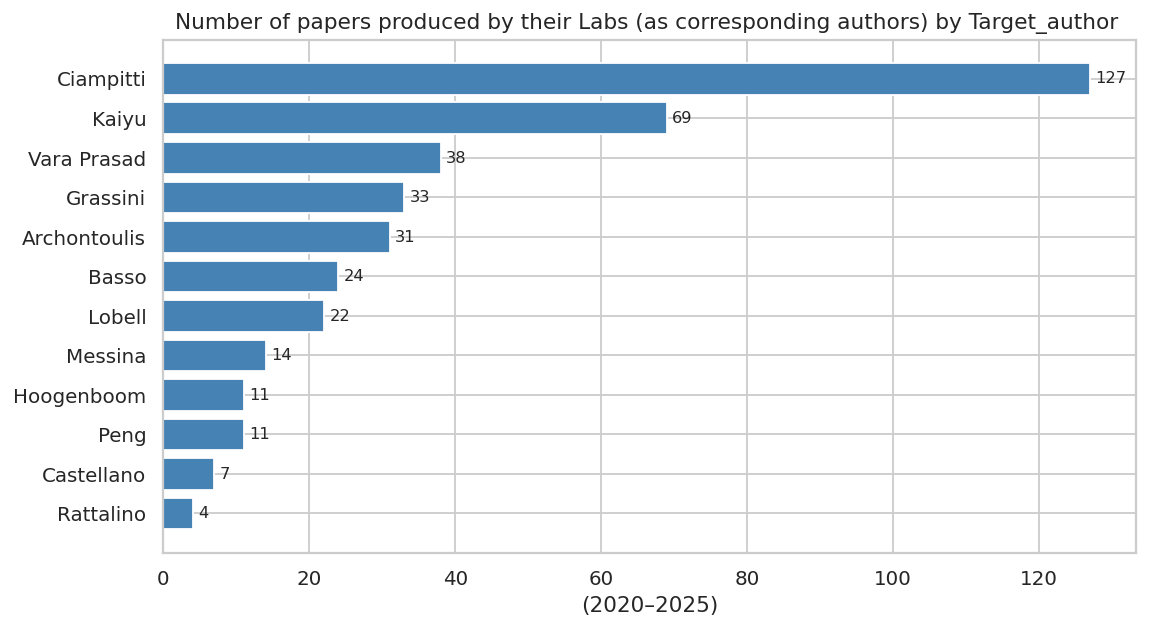

,queried_author,total_papers,avg_citations
11,Ciampitti,127,28.645669
10,Kaiyu,69,68.362319
9,Vara Prasad,38,40.026316
8,Grassini,33,33.969697
7,Archontoulis,31,33.774194
6,Basso,24,55.916667
5,Lobell,22,86.727273
4,Messina,14,55.428571
2,Peng,11,66.727273
3,Hoogenboom,11,5.909091


In [9]:
author_counts = (
     filtered_TargetA_df_corr
    .groupby("queried_author")
    .agg(
        total_papers=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
    )
    .sort_values("total_papers", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(author_counts["queried_author"], author_counts["total_papers"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("(2020–2025)")
ax.set_title("Number of papers produced by their Labs (as corresponding authors) by Target_author ")
plt.tight_layout()
plt.show()
author_counts.sort_values('total_papers', ascending=False)

## Citation Analysis of Target Authors


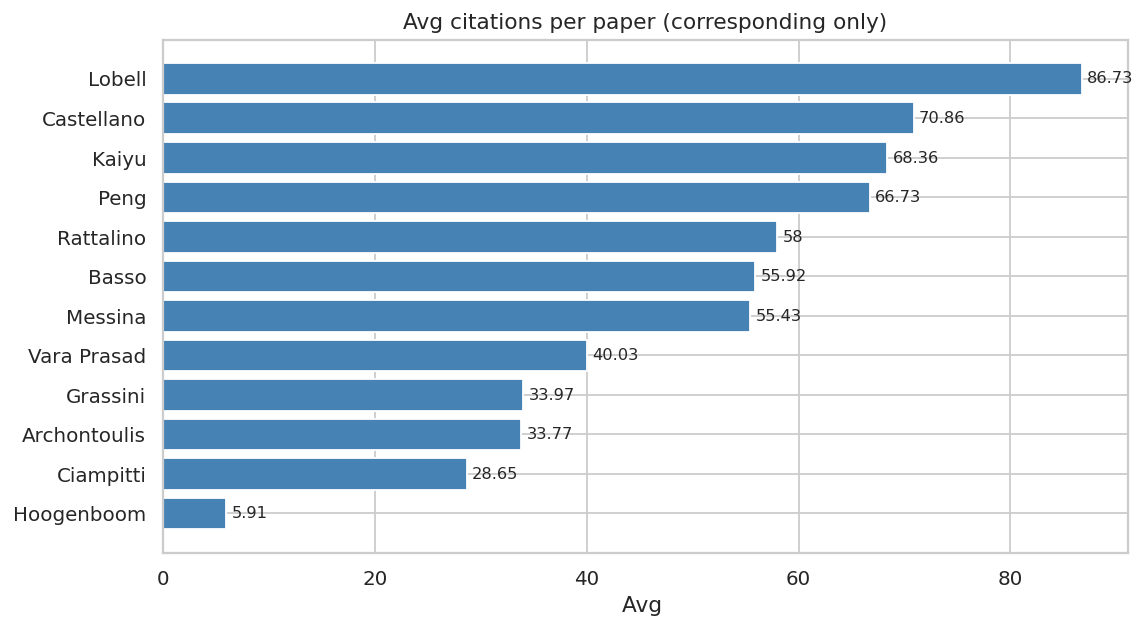

In [10]:
# ── Avg citations by Target author (corresponding only) ──
avg_cit_by_author_corr = (
    filtered_TargetA_df_corr.assign(total_citations=lambda d: d["total_citations"].fillna(0))
    .groupby("queried_author")["total_citations"]
    .mean()
    .sort_values(ascending=True)
    .round(2)
 )

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_cit_by_author_corr.index, avg_cit_by_author_corr.values,
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Avg ")
ax.set_title("Avg citations per paper (corresponding only)")
plt.tight_layout()
plt.show()

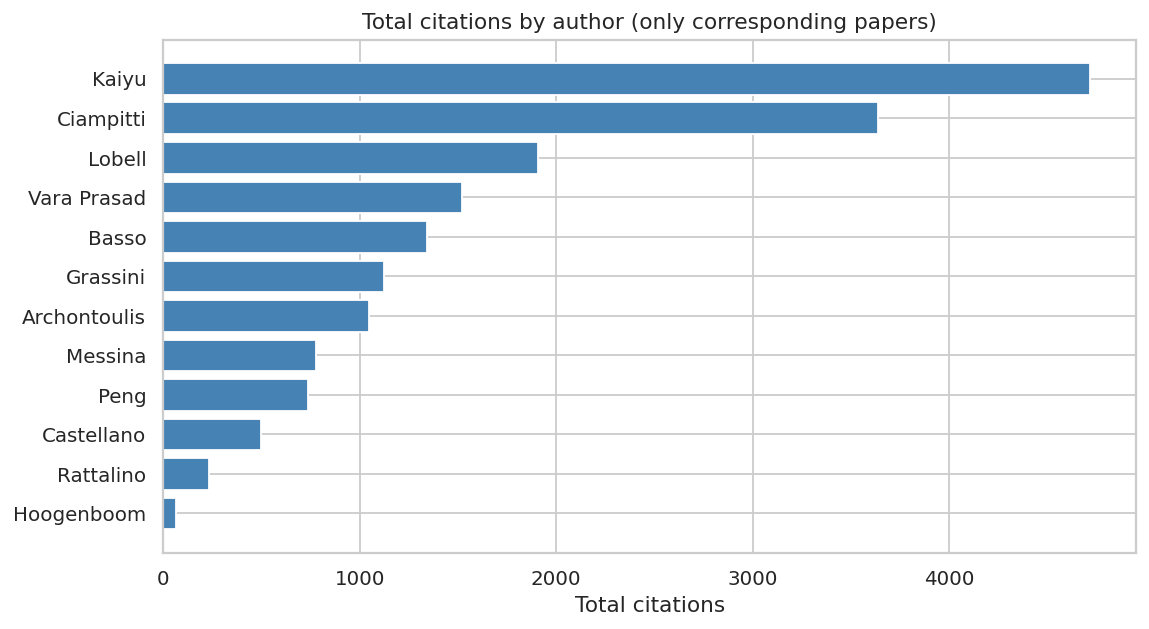

In [11]:
author_total = (
    filtered_TargetA_df_corr
    .groupby("queried_author", as_index=False)
    .agg(total_citations=("total_citations", "sum"))
    .sort_values("total_citations", ascending=False)
)

# Plot
plt.figure(figsize=(9, 5))
plt.barh(author_total["queried_author"], author_total["total_citations"], color="steelblue")
plt.xlabel("Total citations")
plt.title("Total citations by author (only corresponding papers)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

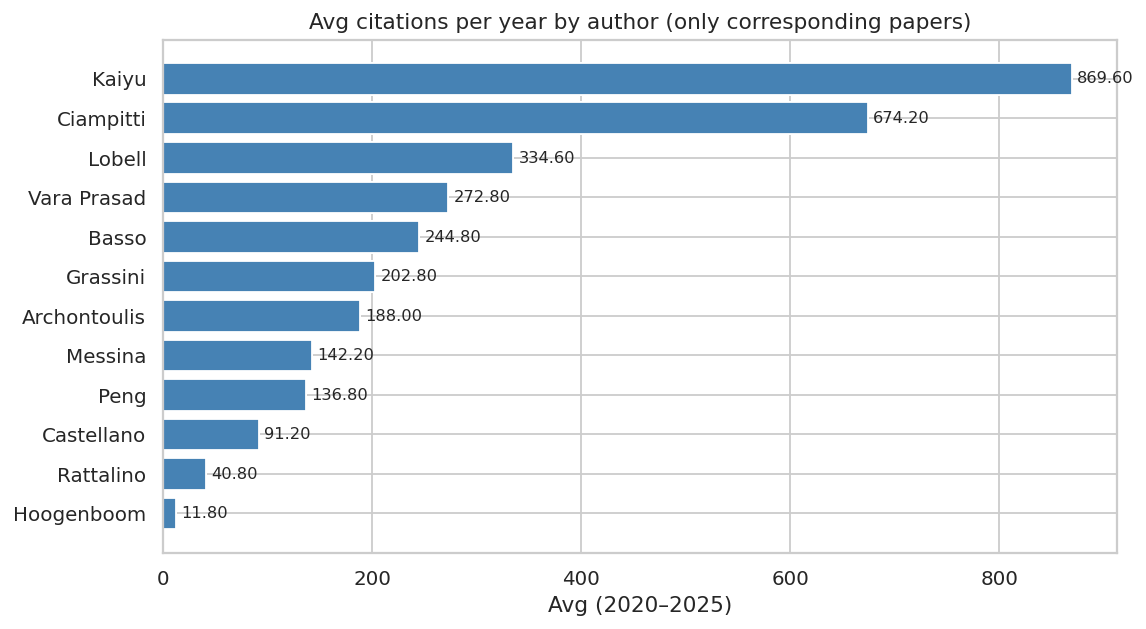

In [12]:
# Bar chart: average citations per year (2020–2025) per author
df = filtered_TargetA_df_corr.copy()  # or filtered_TargetA_df
cit_cols = [c for c in df.columns if c.startswith("citations_year_")]

melted = (
    df.dropna(subset=["publication_year"])
.melt(
          id_vars=["queried_author", "publication_year"],
          value_vars=cit_cols,
          var_name="cit_col",
          value_name="citations",
      )
)

melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"] = melted["citations"].fillna(0)

start_year = 2020
end_year = 2025
year_span = 5
melted = melted[(melted["calendar_year"] >= start_year) & (melted["calendar_year"] <= end_year)]

author_avg_per_year = (
    melted.groupby("queried_author", as_index=False)
.agg(total_citations=("citations", "sum"))
)
author_avg_per_year["avg_citations_per_year"] = author_avg_per_year["total_citations"] / year_span
author_avg_per_year = author_avg_per_year.sort_values("avg_citations_per_year", ascending=True)

plt.figure(figsize=(9, 5))
plt.bar_label(plt.barh(author_avg_per_year["queried_author"], author_avg_per_year["avg_citations_per_year"], color="steelblue"), fmt="%.2f", padding=3, fontsize=9)
plt.barh(author_avg_per_year["queried_author"], author_avg_per_year["avg_citations_per_year"], color="steelblue")
plt.xlabel("Avg (2020–2025)")
plt.title("Avg citations per year by author (only corresponding papers)")
plt.tight_layout()
plt.show()

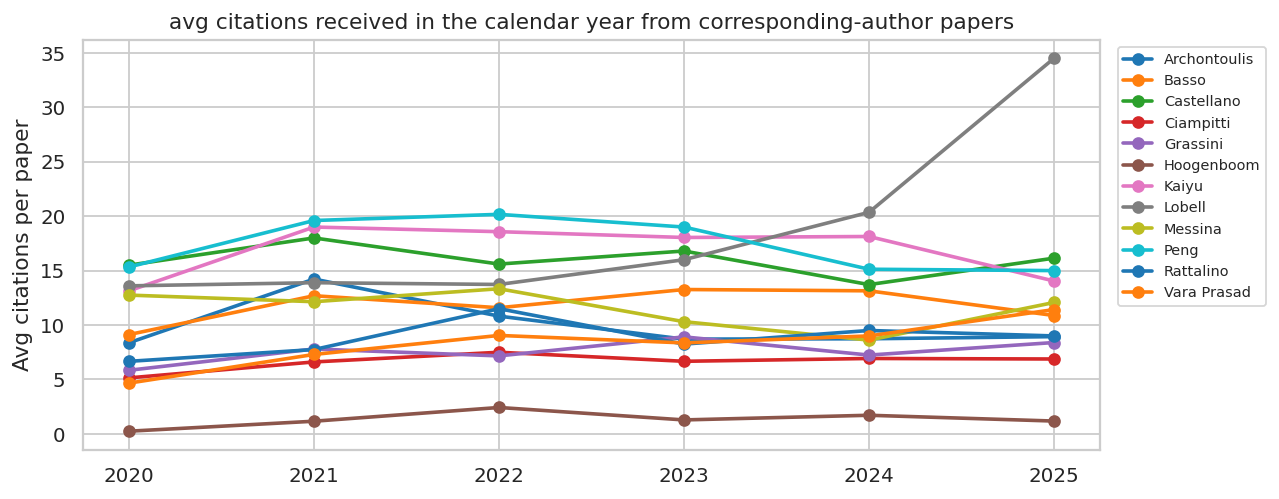

In [100]:
# ── Target-author time analysis (corresponding only, deduped) ────────────────
df_ta = filtered_TargetA_df_corr.copy()
CURRENT_YEAR = 2026

# ---- Citations received per calendar year (total + average) ----
cit_year_cols = [c for c in df_ta.columns if c.startswith("citations_year_")]
melted_ta = (
    df_ta.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "queried_author", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted_ta["offset"] = melted_ta["cit_col"].str.extract(r"(\d+)$").astype(int)
melted_ta["calendar_year"] = melted_ta["publication_year"].astype(int) + melted_ta["offset"]
melted_ta["citations"] = melted_ta["citations"].fillna(0)
melted_ta = melted_ta[
    (melted_ta["calendar_year"] >= 2020)
    & (melted_ta["calendar_year"] <= CURRENT_YEAR - 1)
]

# ---- Citations per year by author (avg per paper) ----
top_authors = (
    df_ta.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(13)
    .index.tolist()
 )
author_year_avg = (
    melted_ta[melted_ta["queried_author"].isin(top_authors)]
    .groupby(["queried_author", "calendar_year"])
    .agg(avg_cit=("citations", "mean"))
    .reset_index()
)

authors_all = sorted(df_ta["queried_author"].dropna().unique().tolist())
palette = sns.color_palette("tab10", n_colors=len(authors_all))
author_color_map = dict(zip(authors_all, palette))

fig, ax = plt.subplots(figsize=(10, 4))
for author, grp in author_year_avg.groupby("queried_author"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["avg_cit"], marker="o", linewidth=2, label=author, color=author_color_map.get(author))
ax.set_title("avg citations received in the calendar year from corresponding-author papers")
# ax.set_xlabel("Calendar year")
ax.set_ylabel("Avg citations per paper")
ax.set_xticks(sorted(author_year_avg["calendar_year"].unique()))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#It shows how many citations per paper each author receives per calendar year, averaged across their papers.
#Author impact over time (flow of citations)


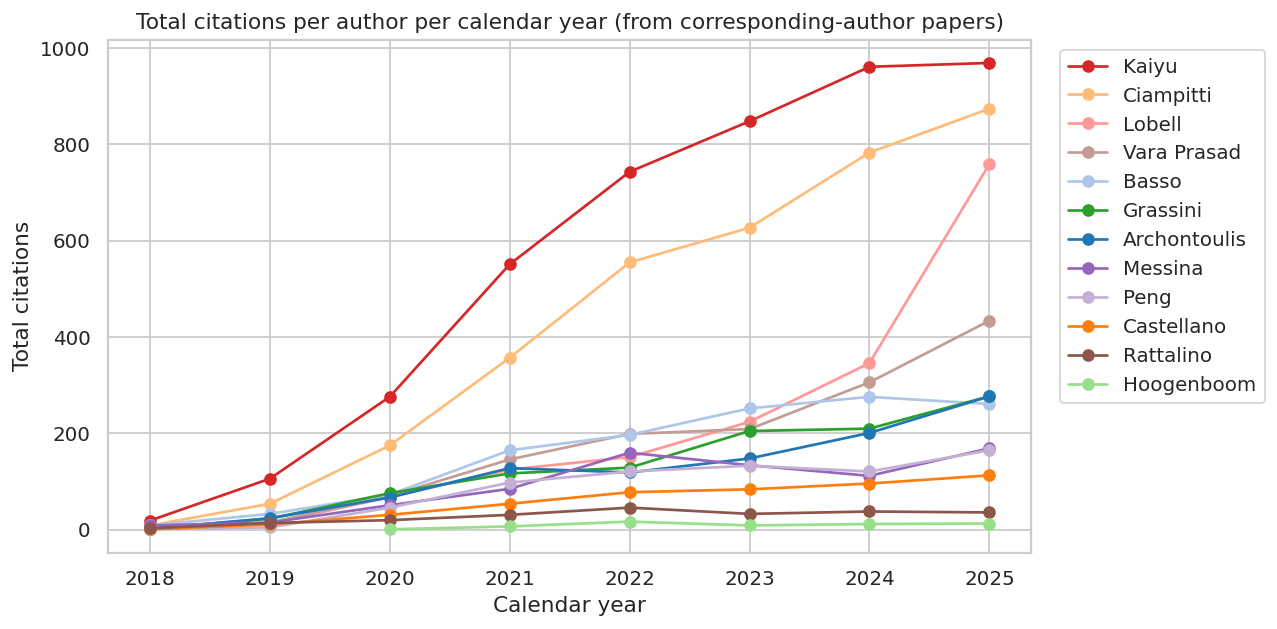

In [14]:
df = filtered_TargetA_df_corr.copy()  # or filtered_TargetA_df
cit_cols = [c for c in df.columns if c.startswith("citations_year_")]

melted = (
    df.dropna(subset=["publication_year"])
    .melt(
          id_vars=["queried_author", "publication_year"],
          value_vars=cit_cols,
          var_name="cit_col",
          value_name="citations",
      )
)

melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"] = melted["citations"].fillna(0)

max_year = 2025
melted = melted[melted["calendar_year"] <= max_year]

author_year = (
    melted.groupby(["queried_author", "calendar_year"], as_index=False)
    .agg(total_citations=("citations", "sum"))
)

# Plot (example for top authors)
top_authors = (
    author_year.groupby("queried_author")["total_citations"]
    .sum().sort_values(ascending=False).head(13).index
)

authors_all = sorted(df["queried_author"].dropna().unique().tolist())
palette = sns.color_palette("tab20", n_colors=len(authors_all))
author_color_map = dict(zip(authors_all, palette))

plt.figure(figsize=(10, 5))
for author in top_authors:
    g = author_year[author_year["queried_author"] == author]
    plt.plot(g["calendar_year"], g["total_citations"], marker="o", label=author, color=author_color_map.get(author))

plt.title("Total citations per author per calendar year (from corresponding-author papers)")
plt.xlabel("Calendar year")
plt.ylabel("Total citations")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

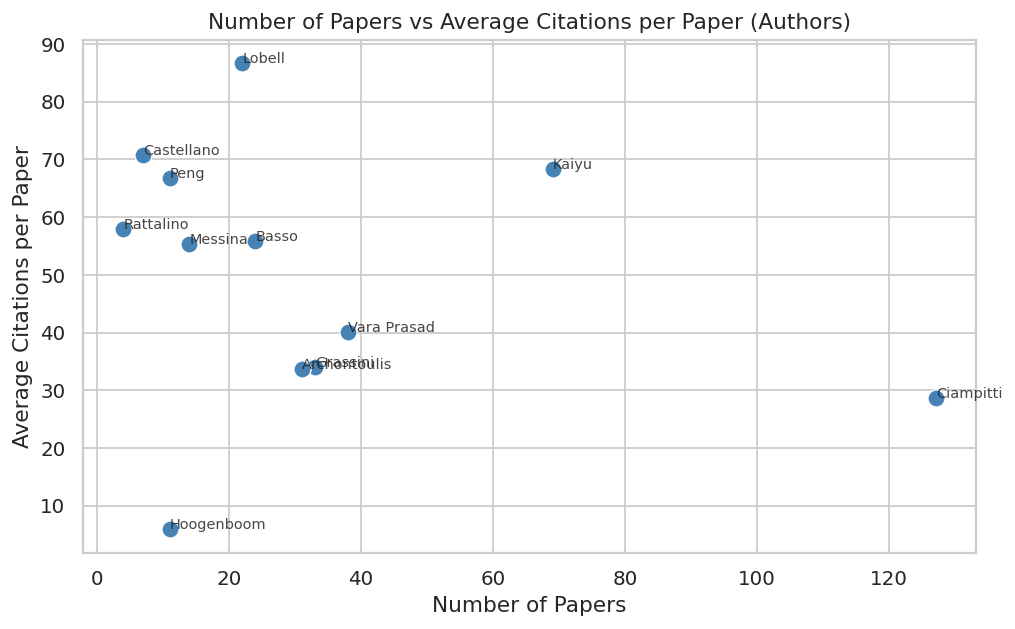

,queried_author,n_papers,avg_citations_per_paper
3,Ciampitti,127,28.645669
6,Kaiyu,69,68.362319
11,Vara Prasad,38,40.026316
4,Grassini,33,33.969697
0,Archontoulis,31,33.774194
1,Basso,24,55.916667
7,Lobell,22,86.727273
8,Messina,14,55.428571
9,Peng,11,66.727273
5,Hoogenboom,11,5.909091


In [ ]:
base_df = filtered_TargetA_df_corr.copy()

author_summary = (
    base_df[["queried_author", "article_id", "total_citations"]]
    .dropna(subset=["queried_author", "article_id", "total_citations"])
    .groupby("queried_author", as_index=False)
    .agg(
        n_papers=("article_id", "nunique"),
        avg_citations_per_paper=("total_citations", "mean"),
    )
    .sort_values("n_papers", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=author_summary,
    x="n_papers",
    y="avg_citations_per_paper",
    s=90,
    color="steelblue",
)

for _, row in author_summary.iterrows():
    plt.text(
        row["n_papers"] + 0.03,
        row["avg_citations_per_paper"] + 0.03,
        row["queried_author"],
        fontsize=8,
        alpha=0.85,
    )

plt.title("Number of Papers vs Average Citations per Paper (Authors)")
plt.xlabel("Number of Papers")
plt.ylabel("Average Citations per Paper")
plt.tight_layout()
plt.show()

author_summary

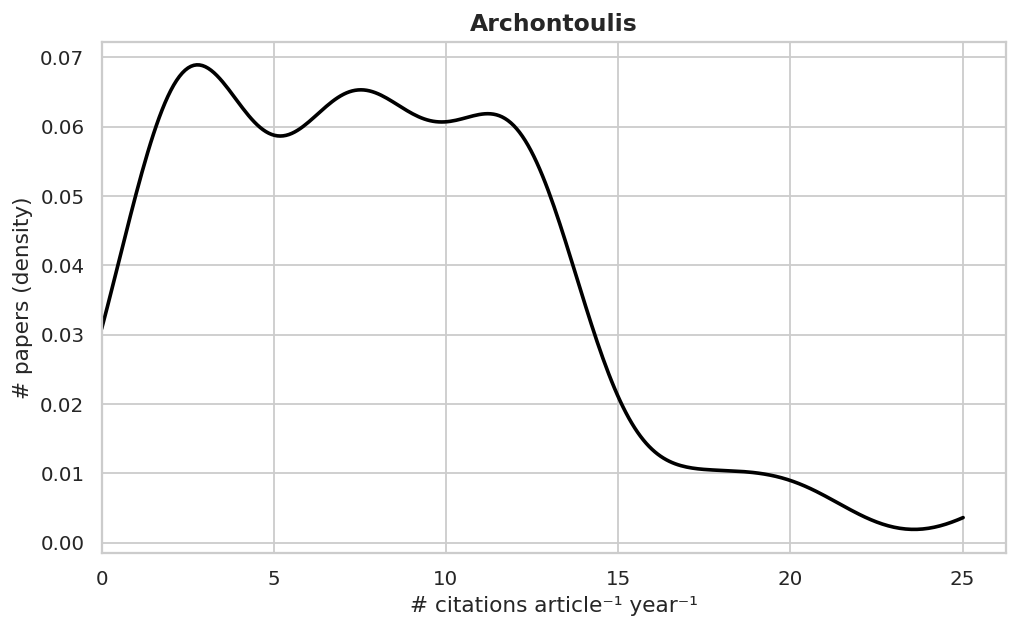

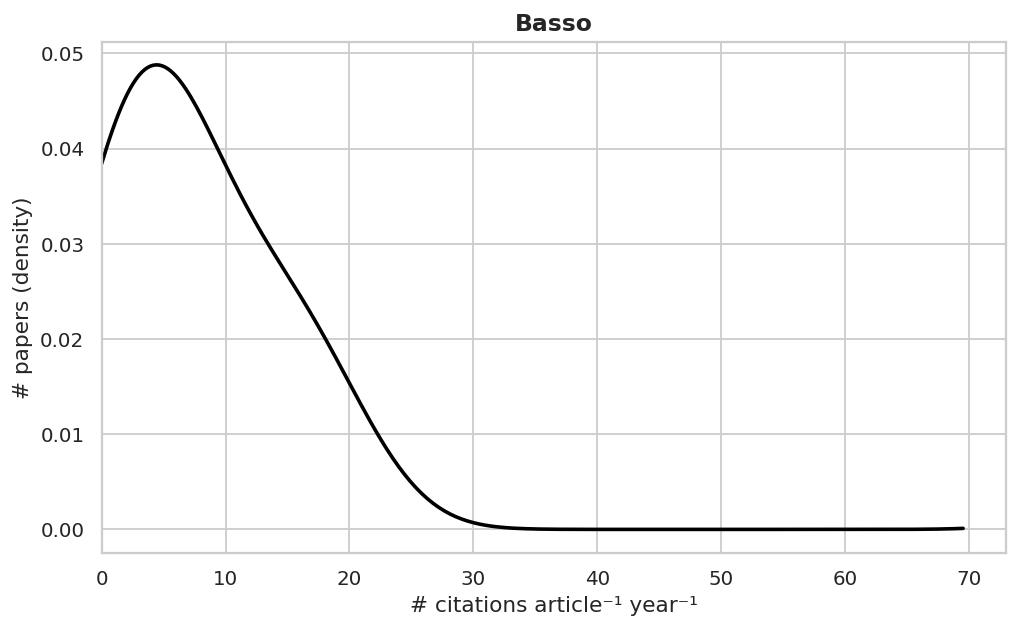

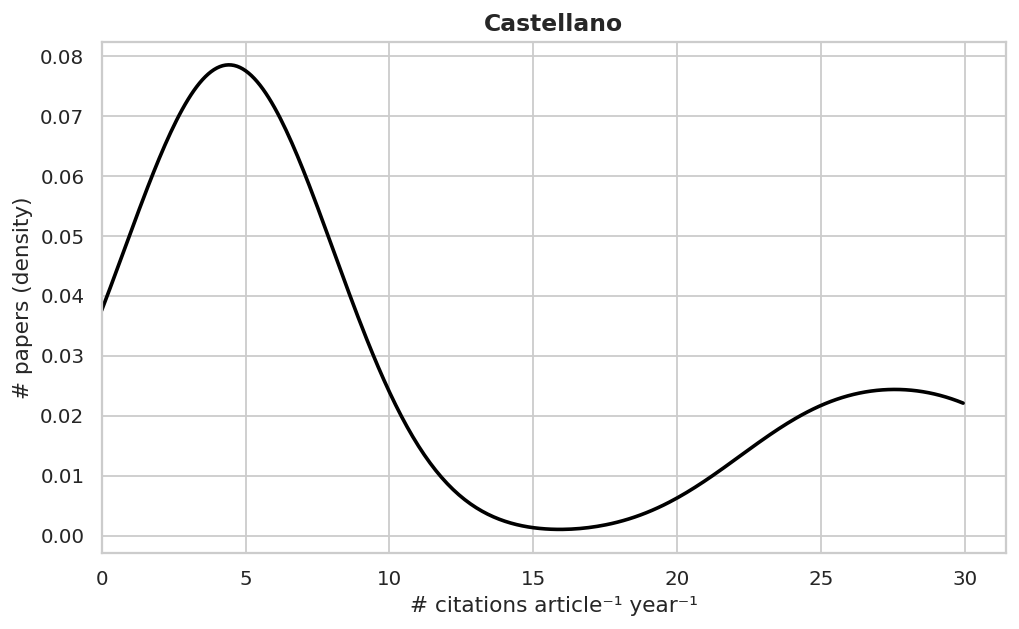

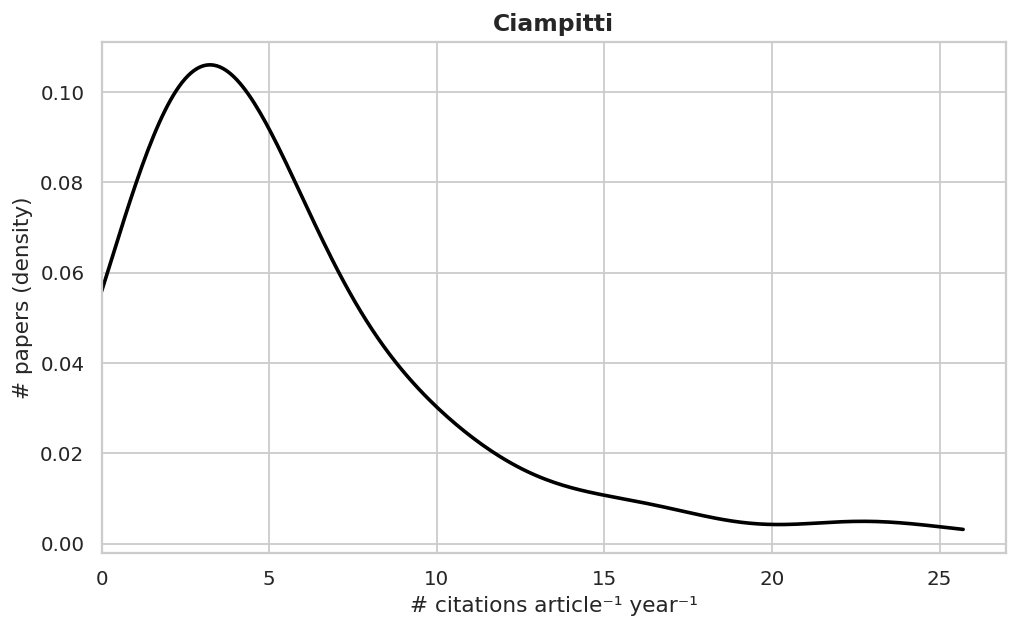

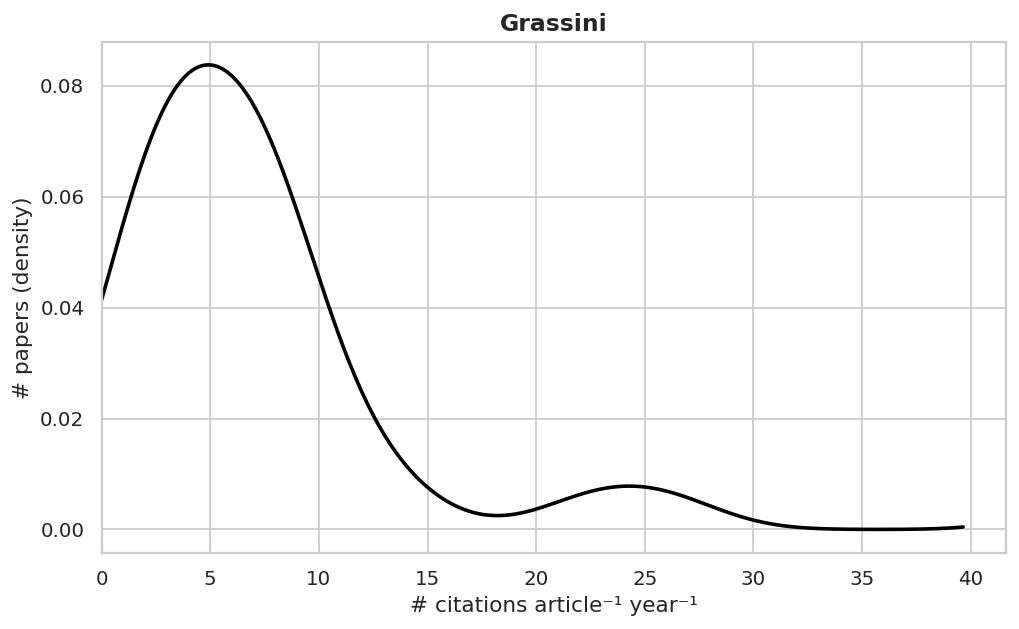

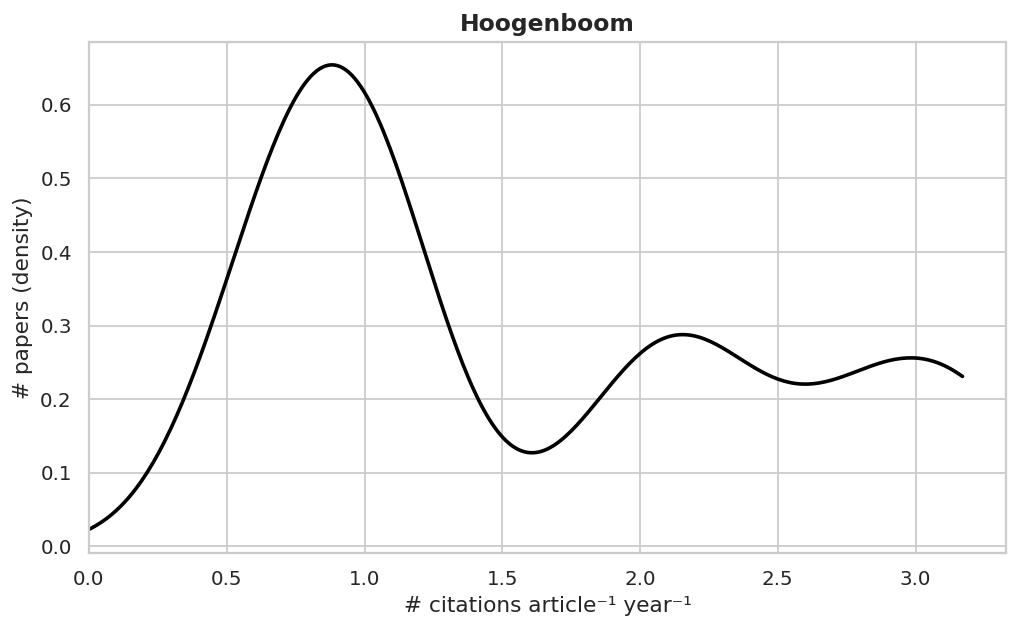

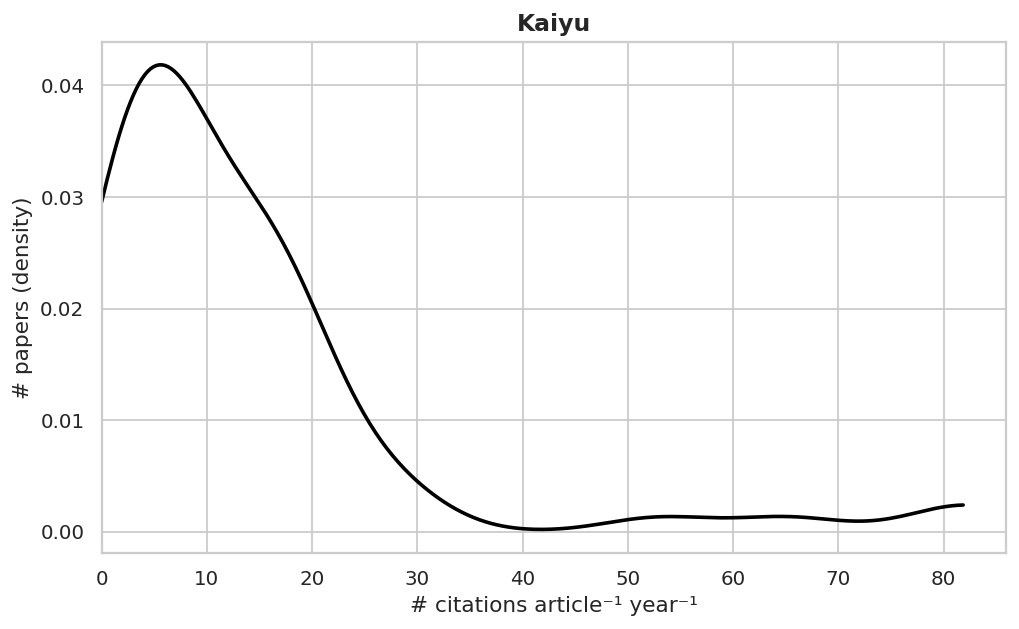

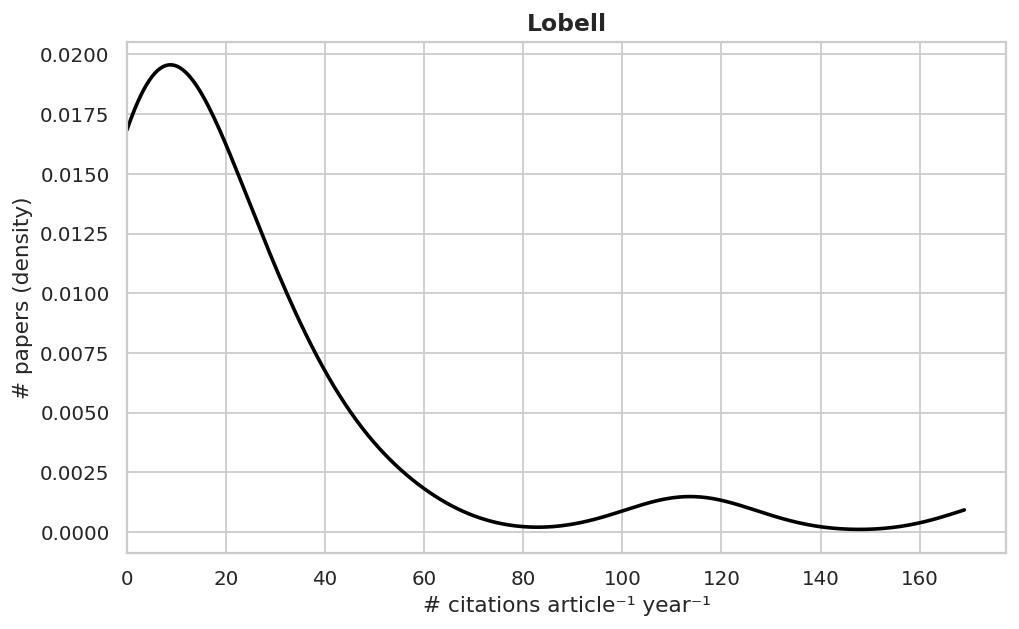

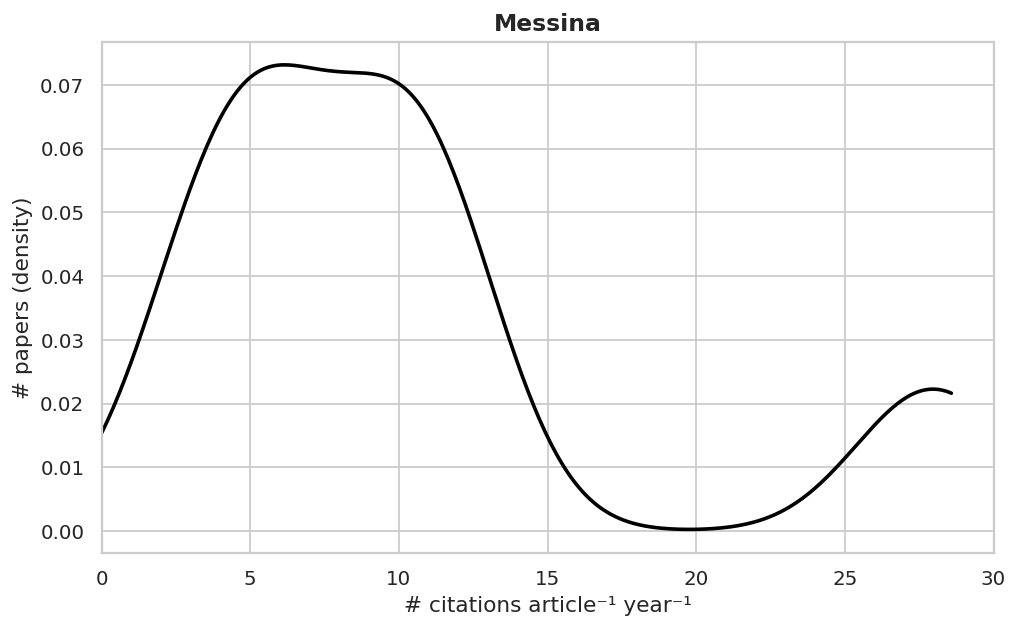

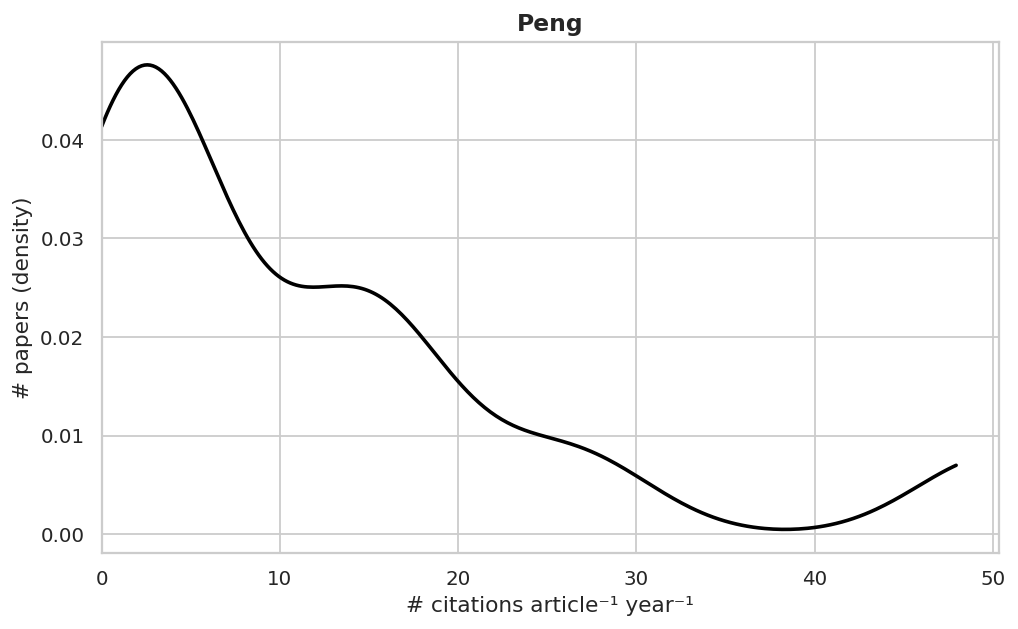

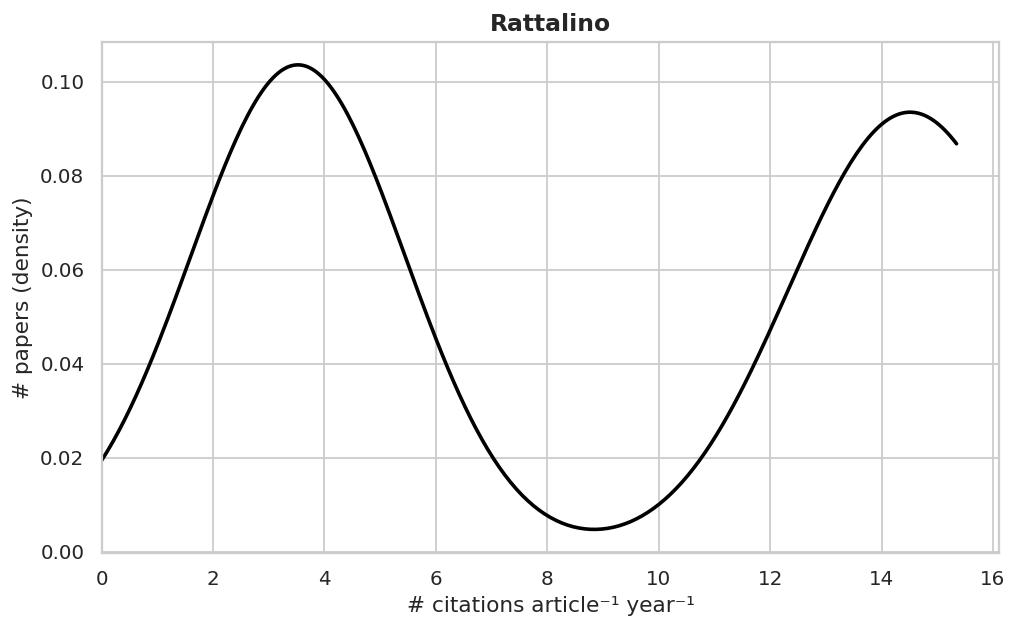

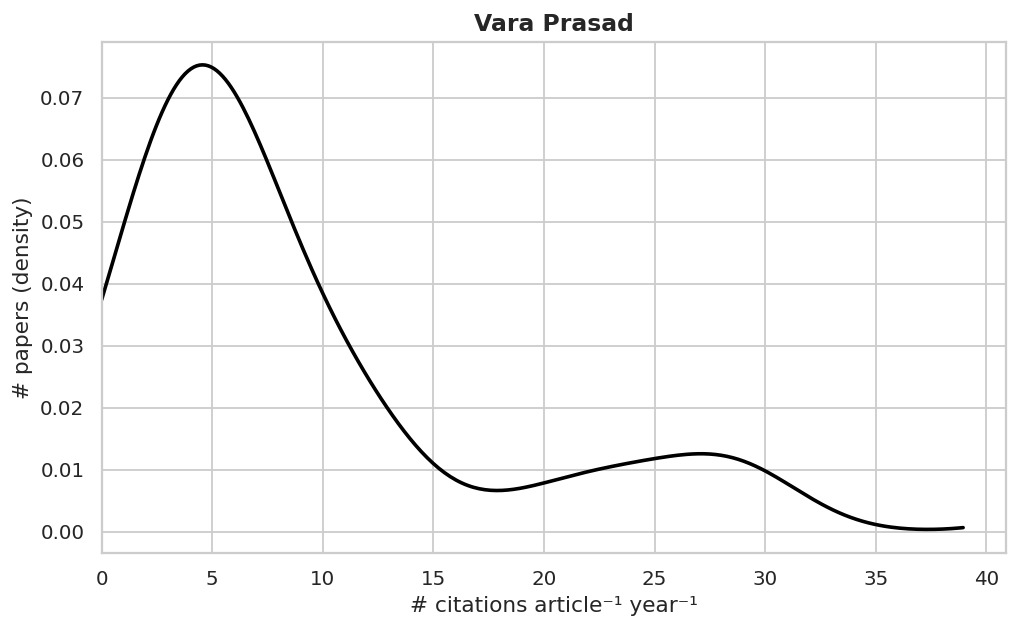

In [16]:
def plot_citation_distribution(df, group_col, citation_col):
    """
    Creates one individual plot per group.
    """
    for group_name, group_df in df.groupby(group_col):
        data = group_df[citation_col].dropna()
        data = data[data > 0]

        # if len(data) < 20:
        #     continue

        kde = gaussian_kde(data, bw_method=0.3)
        x = np.linspace(0, data.quantile(0.99), 300)
        y = kde(x)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(x, y, color="black", linewidth=2)
        ax.set_xlabel("# citations article⁻¹ year⁻¹", fontsize=12)
        ax.set_ylabel("# papers (density)", fontsize=12)
        ax.set_title(group_name, fontsize=13, fontweight="bold")
        ax.set_xlim(left=0)
        plt.tight_layout()
        plt.show()

# Usage:
filtered_TargetA_df_corr["citations_per_year"] = (
    filtered_TargetA_df_corr["total_citations"] /
    (ACTUAL_Y - filtered_TargetA_df_corr["publication_year"])
)
plot_citation_distribution(filtered_TargetA_df_corr, group_col="queried_author", citation_col="citations_per_year")


## Metrics analysis and comparison

Text(0.5, 1.0, 'Calculated H-index (20-25 corresponding papers)')

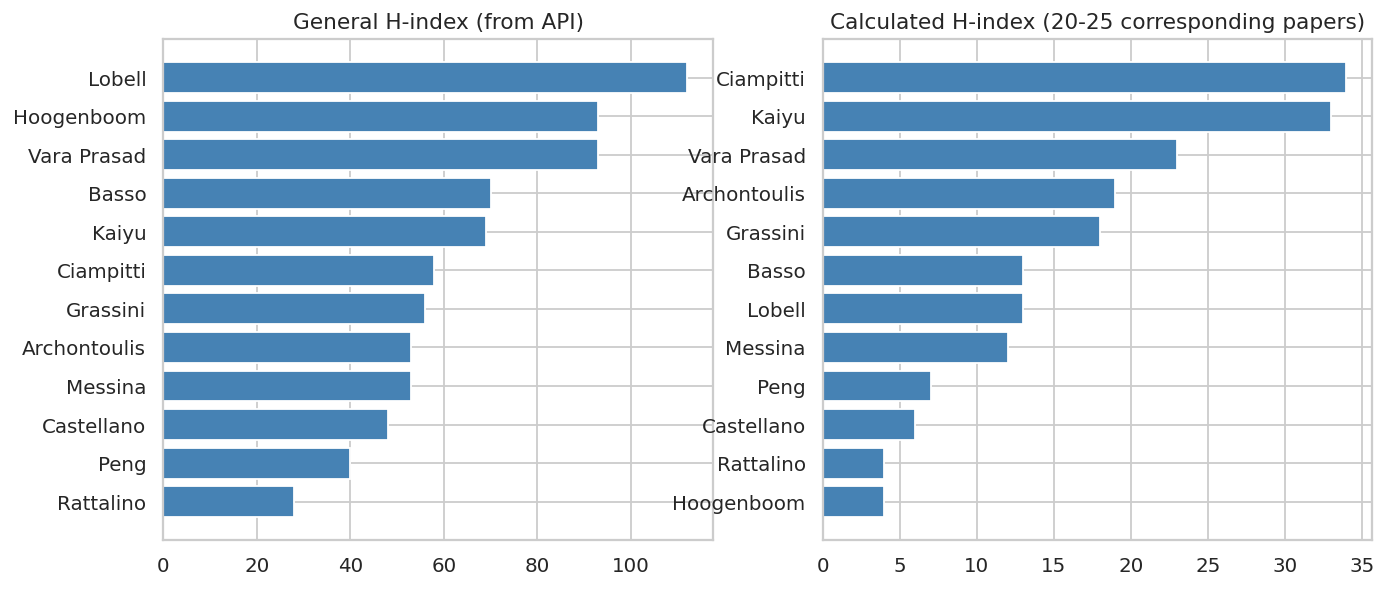

In [17]:
metrics_df = calculate_author_metrics(filtered_TargetA_df_corr, author_col='queried_author', citations_col='total_citations')
hindex_df = (
    filtered_TargetA_df_corr[["queried_author", "general_h_index"]]
    .drop_duplicates()
    .dropna(subset=["general_h_index"])
    .sort_values("general_h_index", ascending=True)
 )

metrics_h = (
    metrics_df.dropna(subset=["h_index"])
    .sort_values("h_index", ascending=True)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

axes[0].barh(hindex_df["queried_author"], hindex_df["general_h_index"], color="steelblue")
axes[0].set_title("General H-index (from API)")
axes[1].barh(metrics_h["queried_author"], metrics_h["h_index"], color="steelblue")
axes[1].set_title("Calculated H-index (20-25 corresponding papers)")

Text(0.5, 1.0, 'Calculated I10-index (20-25 corresponding papers)')

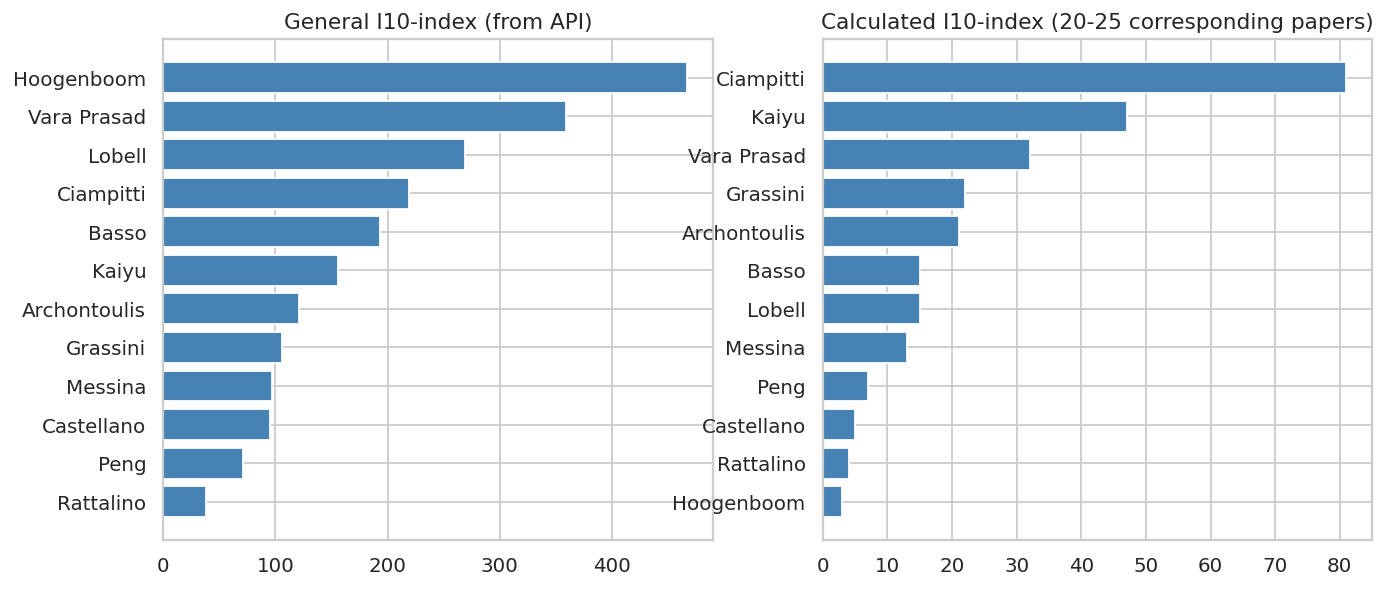

In [18]:

i10_df = (
    filtered_TargetA_df_corr[["queried_author", "general_i10_index"]]
    .drop_duplicates()
    .dropna(subset=["general_i10_index"])
    .sort_values("general_i10_index", ascending=True)
 )

metrics_i10 = (
    metrics_df.dropna(subset=["i10_index"])
    .sort_values("i10_index", ascending=True)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
axes[0].barh(i10_df["queried_author"], i10_df["general_i10_index"], color="steelblue")
axes[0].set_title("General I10-index (from API)")
axes[1].barh(metrics_i10["queried_author"], metrics_i10["i10_index"], color="steelblue")
axes[1].set_title("Calculated I10-index (20-25 corresponding papers)")

In [104]:

# # Make sure your DataFrame is sorted by publication_year
# df = filtered_TargetA_df_corr.sort_values('publication_year')

# # Get the unique years in ascending order
# years = sorted(df['publication_year'].unique())

# # Prepare lists to store metrics per year
# cumulative_h_index = []
# cumulative_mean = []
# cumulative_median = []

# # Initialize a list to hold all citations cumulatively
# all_citations = []

# for year in years:
#     # Get all papers published up to the current year (cumulative)
#     df_cumulative = df[df['publication_year'] <= year]
    
#     # Combine all citations up to this year
#     citations = df_cumulative['total_citations'].tolist()
#     citations.sort(reverse=True)
    
#     # Calculate cumulative H-index
#     h_index = 0
#     for i, c in enumerate(citations, start=1):
#         if c >= i:
#             h_index = i
#         else:
#             break
#     cumulative_h_index.append(h_index)
    
#     # Calculate cumulative mean and median
#     cumulative_mean.append(np.mean(citations) if citations else 0)
#     cumulative_median.append(np.median(citations) if citations else 0)
# print('cumulative_h_index')
# print(cumulative_h_index)

# print('cumulative_mean')
# print(cumulative_mean)

# print('cumulative_median')
# print(cumulative_median)
# # Plot the metrics
# plt.figure(figsize=(12,6))

# plt.plot(years, cumulative_h_index, marker='o', label='Cumulative H-index', color='blue')
# plt.plot(years, cumulative_mean, marker='s', label='Cumulative Mean Citations', color='green')
# plt.plot(years, cumulative_median, marker='^', label='Cumulative Median Citations', color='orange')

# plt.xlabel('Publication Year')
# plt.ylabel('Metric Value')
# plt.title('Cumulative H-index, Mean and Median Citations Over Years')
# plt.xticks(years, rotation=45)
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

## Corresponding vs non corresponding

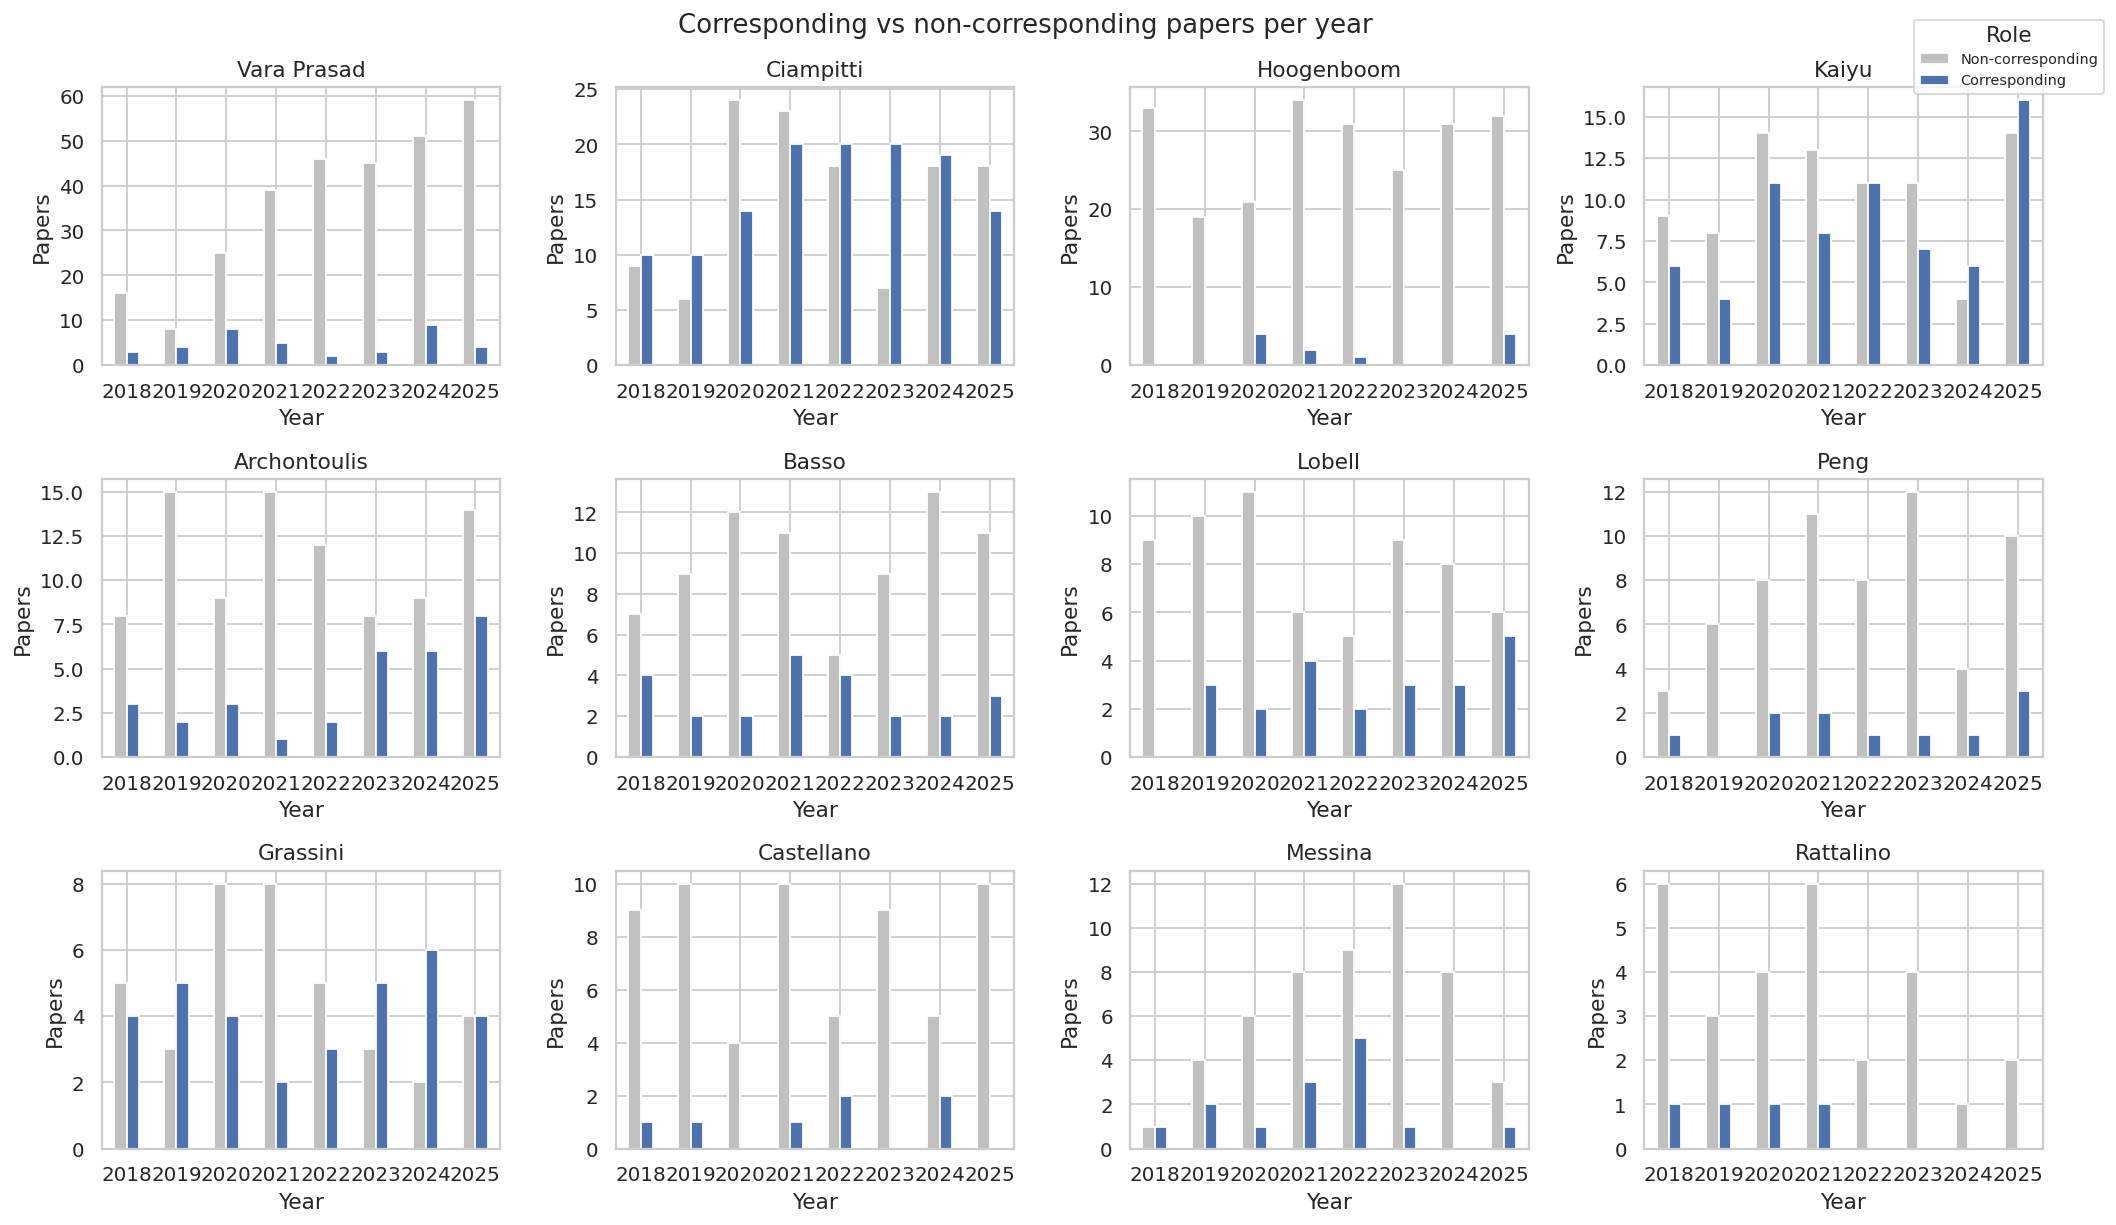

In [22]:

df_ta = filtered_TargetA_df.copy()
# ---- Corresponding vs non-corresponding papers per year by author ----
top_authors = (
    df_ta.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(13)
    .index.tolist()
)

corr_year_author = (
    df_ta[df_ta["queried_author"].isin(top_authors)]
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year", "is_corresponding_author"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "Corresponding", False: "Non-corresponding"})
)

n_authors = len(top_authors)
ncols = 4
nrows = int(np.ceil(n_authors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, author in enumerate(top_authors):
    ax = axes_flat[i]
    data = corr_year_author.loc[author].sort_index()
    data.plot(kind="bar", stacked=False, ax=ax, color=["#C0C0C0", "#4C72B0"], edgecolor="white", legend=False)
    ax.set_title(author)
    ax.set_xlabel("Year")
    ax.set_ylabel("Papers")
    ax.tick_params(axis="x", rotation=0)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Corresponding vs non-corresponding papers per year ")
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 0.98), fontsize=8, title="Role")
plt.tight_layout()
plt.show()

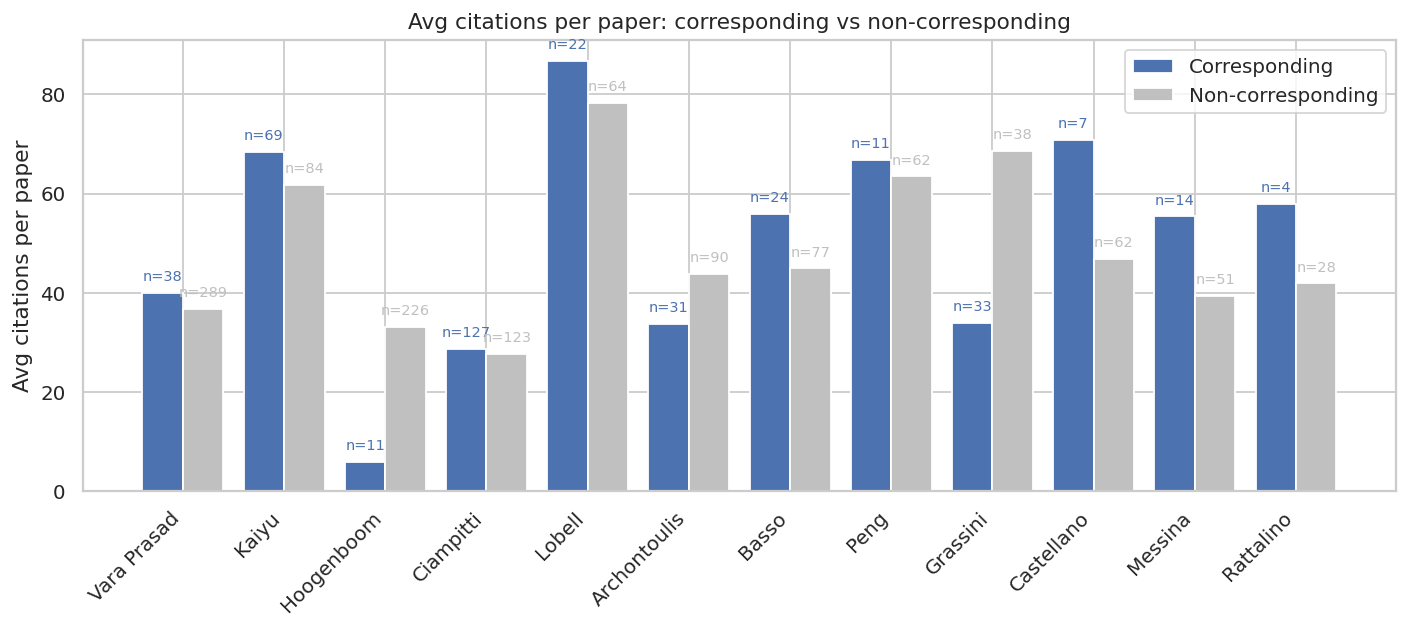

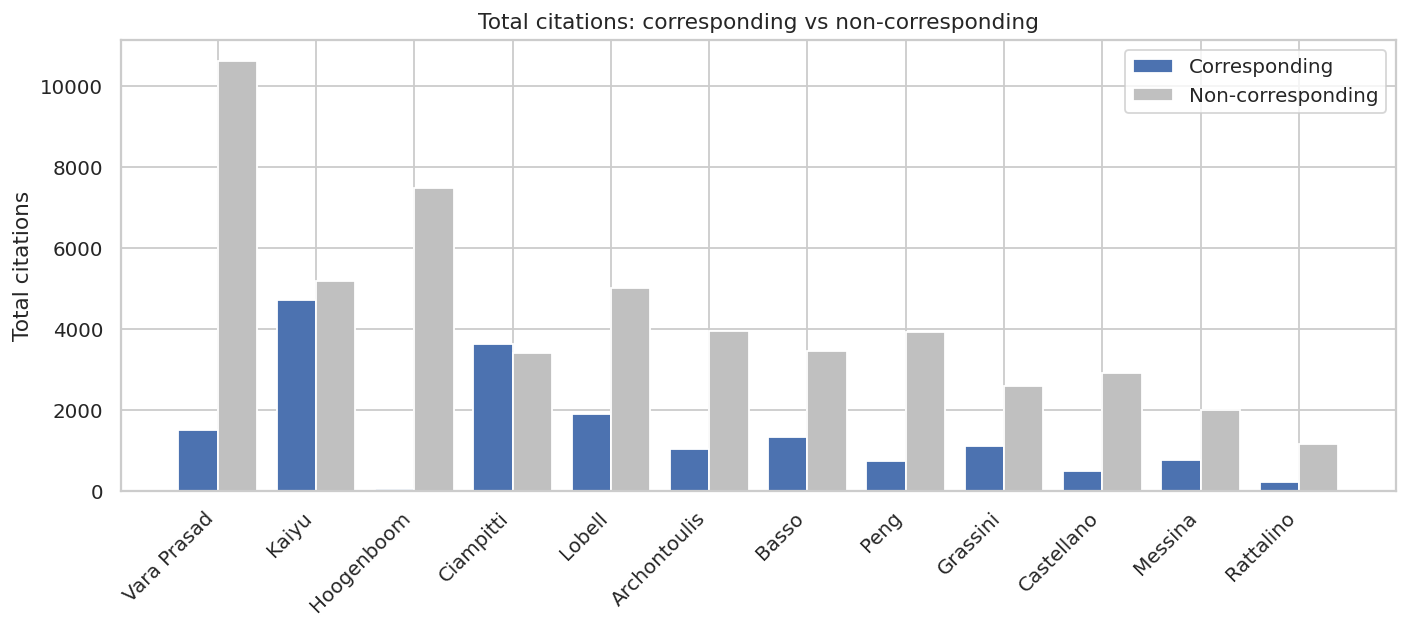

In [23]:
# Compare corresponding vs non-corresponding citations by author (avg and total)
df_corr = filtered_TargetA_df_corr.copy()
df_non = filtered_TargetA_df[~filtered_TargetA_df["is_corresponding_author"]].copy()

def _summarize(df):
    return (
        df.groupby("queried_author", as_index=False)
        .agg(
            avg_citations=("total_citations", "mean"),
            total_citations=("total_citations", "sum"),
            total_papers=("article_id", "count"),
        )
    )

corr_stats = _summarize(df_corr).rename(
    columns={
        "avg_citations": "avg_corr",
        "total_citations": "total_corr",
        "total_papers": "total_papers_corr"

    }
 )
non_stats = _summarize(df_non).rename(
    columns={
        "avg_citations": "avg_non",
        "total_citations": "total_non",
        "total_papers": "total_papers_non"
    }
 )

compare = corr_stats.merge(non_stats, on="queried_author", how="outer").fillna(0)
compare["total_all"] = compare["total_corr"] + compare["total_non"]
compare = compare.sort_values("total_all", ascending=False)

authors = compare["queried_author"].tolist()
x = np.arange(len(authors))
bar_w = 0.4
color_corr = "#4C72B0"
color_non = "#C0C0C0"

# ---- Avg citations per paper ----
fig, ax = plt.subplots(figsize=(11, 5))
bars_corr = ax.bar(x - bar_w / 2, compare["avg_corr"], width=bar_w, label="Corresponding", color=color_corr)
bars_non = ax.bar(x + bar_w / 2, compare["avg_non"], width=bar_w, label="Non-corresponding", color=color_non)
ax.set_title("Avg citations per paper: corresponding vs non-corresponding")
ax.set_ylabel("Avg citations per paper")
ax.set_xticks(x)
ax.set_xticklabels(authors, rotation=45, ha="right")
ax.legend()

# Add paper count above each individual bar
for i, row in enumerate(compare.itertuples()):
    # Above corresponding bar
    ax.text(
        x[i] - bar_w / 2, row.avg_corr + ax.get_ylim()[1] * 0.02,
        f"n={int(row.total_papers_corr)}",
        ha="center", va="bottom", fontsize=8, color=color_corr
    )
    # Above non-corresponding bar
    ax.text(
        x[i] + bar_w / 2, row.avg_non + ax.get_ylim()[1] * 0.02,
        f"n={int(row.total_papers_non)}",
        ha="center", va="bottom", fontsize=8, color=color_non
    )

plt.tight_layout()
plt.show()

# ---- Total citations ----
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - bar_w / 2, compare["total_corr"], width=bar_w, label="Corresponding", color=color_corr)
ax.bar(x + bar_w / 2, compare["total_non"], width=bar_w, label="Non-corresponding", color=color_non)
ax.set_title("Total citations: corresponding vs non-corresponding")
ax.set_ylabel("Total citations")
ax.set_xticks(x)
ax.set_xticklabels(authors, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [105]:
# # ── Target-author time analysis (corresponding only, deduped) ────────────────
# df_ta = filtered_TargetA_df_corr.copy()
# CURRENT_YEAR = 2026

# # ---- Citations received per calendar year (total + average) ----
# cit_year_cols = [c for c in df_ta.columns if c.startswith("citations_year_")]
# melted_ta = (
#     df_ta.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
#     .melt(id_vars=["article_id", "queried_author", "publication_year"],
#           value_vars=cit_year_cols,
#           var_name="cit_col", value_name="citations")
# )
# melted_ta["offset"] = melted_ta["cit_col"].str.extract(r"(\d+)$").astype(int)
# melted_ta["calendar_year"] = melted_ta["publication_year"].astype(int) + melted_ta["offset"]
# melted_ta["citations"] = melted_ta["citations"].fillna(0)
# melted_ta = melted_ta[
#     (melted_ta["calendar_year"] >= 2020)
#     & (melted_ta["calendar_year"] <= CURRENT_YEAR - 1)
# ]

# # ---- Citations per year by author (avg per paper) ----
# top_authors = (
#     df_ta.groupby("queried_author")["article_id"]
#     .count()
#     .sort_values(ascending=False)
#     .head(13)
#     .index.tolist()
#  )
# author_year_median = (
#     melted_ta[melted_ta["queried_author"].isin(top_authors)]
#     .groupby(["queried_author", "calendar_year"])
#     .agg(median_cit=("citations", "median"))
#     .reset_index()
# )

# authors_all = sorted(df_ta["queried_author"].dropna().unique().tolist())
# palette = sns.color_palette("tab20", n_colors=len(authors_all))
# author_color_map = dict(zip(authors_all, palette))

# fig, ax = plt.subplots(figsize=(10, 4))
# for author, grp in author_year_median.groupby("queried_author"):
#     grp = grp.sort_values("calendar_year")
#     ax.plot(grp["calendar_year"], grp["median_cit"], marker="o", linewidth=2, label=author, color=author_color_map.get(author))
# ax.set_title("median citations received in the calendar year from corresponding-author papers")
# # ax.set_xlabel("Calendar year")
# ax.set_ylabel("Median citations per paper")
# ax.set_xticks(sorted(author_year_median["calendar_year"].unique()))
# ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# plt.tight_layout()
# plt.show()

# #It shows how many citations per paper each author receives per calendar year, median across their papers.


In [ ]:
# # ---- Reusable citation behavior clustering (authors) ----

# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import silhouette_score
# from sklearn.cluster import KMeans


# def run_author_citation_clustering(
#     source_df,
#     title_prefix="Authors",
#     top_examples=5,
#     k_min=2,
#     k_max=6,
#     random_state=42,
# ):
#     """Cluster authors by citation behavior and return key outputs.

#     Features:
#     - log(1 + n_papers)
#     - log(1 + total_citations)
#     - citations_per_paper
#     """

#     author_df = (
#         source_df
#         .dropna(subset=["queried_author", "article_id"])
#         .groupby("queried_author", as_index=False)
#         .agg(
#             n_papers=("article_id", "nunique"),
#             total_citations=("total_citations", "sum"),
#         )
#     )

#     author_df["total_citations"] = author_df["total_citations"].fillna(0)
#     author_df = author_df[author_df["n_papers"] > 0].copy()
#     author_df["citations_per_paper"] = author_df["total_citations"] / author_df["n_papers"]

#     print(f"{title_prefix} available for clustering: {len(author_df)}")

#     author_df["log_n_papers"] = np.log1p(author_df["n_papers"])
#     author_df["log_total_citations"] = np.log1p(author_df["total_citations"])

#     feature_cols = ["log_n_papers", "log_total_citations", "citations_per_paper"]
#     X = author_df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
#     author_df = author_df.loc[X.index].copy()

#     if len(author_df) < max(3, k_min + 1):
#         print("Not enough authors to cluster with the requested k range.")
#         return None

#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     k_upper = min(k_max, len(author_df) - 1)
#     k_values = list(range(k_min, k_upper + 1))
#     inertias = []
#     silhouettes = []

#     for k in k_values:
#         km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
#         labels_k = km.fit_predict(X_scaled)
#         inertias.append(km.inertia_)
#         silhouettes.append(silhouette_score(X_scaled, labels_k))

#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#     axes[0].plot(k_values, inertias, marker="o", linewidth=2)
#     axes[0].set_title(f"Elbow method ({title_prefix.lower()})")
#     axes[0].set_xlabel("k")
#     axes[0].set_ylabel("Inertia")

#     axes[1].plot(k_values, silhouettes, marker="o", linewidth=2, color="darkorange")
#     axes[1].set_title(f"Silhouette score ({title_prefix.lower()})")
#     axes[1].set_xlabel("k")
#     axes[1].set_ylabel("Score")
#     plt.tight_layout()
#     plt.show()

#     best_k = k_values[int(np.argmax(silhouettes))]
#     print(f"Selected k by max silhouette ({title_prefix.lower()}): {best_k}")

#     kmeans = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
#     author_df["cluster"] = kmeans.fit_predict(X_scaled)

#     cluster_profile = (
#         author_df.groupby("cluster", as_index=False)
#         .agg(
#             n_authors=("queried_author", "count"),
#             papers_median=("n_papers", "median"),
#             papers_mean=("n_papers", "mean"),
#             total_cit_median=("total_citations", "median"),
#             total_cit_mean=("total_citations", "mean"),
#             cpp_median=("citations_per_paper", "median"),
#             cpp_mean=("citations_per_paper", "mean"),
#         )
#         .sort_values("cpp_median", ascending=False)
#         .round(2)
#     )

#     print(f"\n{title_prefix} cluster profile (sorted by citation efficiency):")
#     display(cluster_profile)

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#     scatter_1 = axes[0].scatter(
#         author_df["n_papers"],
#         author_df["total_citations"],
#         c=author_df["cluster"],
#         cmap="tab10",
#         s=70,
#         alpha=0.8,
#         edgecolors="black",
#         linewidths=0.3,
#     )
#     axes[0].set_title(f"{title_prefix}: papers vs total citations")
#     axes[0].set_xlabel("Number of papers")
#     axes[0].set_ylabel("Total citations")

#     scatter_2 = axes[1].scatter(
#         author_df["n_papers"],
#         author_df["citations_per_paper"],
#         c=author_df["cluster"],
#         cmap="tab10",
#         s=70,
#         alpha=0.8,
#         edgecolors="black",
#         linewidths=0.3,
#     )
#     axes[1].set_title(f"{title_prefix}: papers vs citations per paper")
#     axes[1].set_xlabel("Number of papers")
#     axes[1].set_ylabel("Citations per paper")

#     for ax in axes:
#         ax.grid(alpha=0.2)

#     plt.colorbar(scatter_2, ax=axes, label="Cluster")
#     plt.tight_layout()
#     plt.show()

#     examples = (
#         author_df
#         .sort_values(["cluster", "citations_per_paper"], ascending=[True, False])
#         .groupby("cluster", as_index=False)
#         .head(top_examples)
#         [["cluster", "queried_author", "n_papers", "total_citations", "citations_per_paper"]]
#         .sort_values(["cluster", "citations_per_paper"], ascending=[True, False])
#         .round(2)
#     )
#     print(f"Top examples per cluster ({title_prefix.lower()}):")
#     display(examples)

#     return {
#         "author_df": author_df,
#         "cluster_profile": cluster_profile,
#         "examples": examples,
#         "k_values": k_values,
#         "inertias": inertias,
#         "silhouettes": silhouettes,
#         "best_k": best_k,
#     }

In [181]:
# # ---- Run reusable clustering on ALL corresponding authors ----

# all_cluster_results = run_author_citation_clustering(
#     source_df=filtered_all_df_corr,
#     title_prefix="All authors",
#     top_examples=5,
#     k_min=2,
#     k_max=6,
#     random_state=42,
# )

# if all_cluster_results is not None:
#     all_author_cluster_df = all_cluster_results["author_df"]
#     all_cluster_profile = all_cluster_results["cluster_profile"]
#     all_examples = all_cluster_results["examples"]

#     # Compact interpretation from medians to keep it data-driven.
#     print("\nInterpretation (filtered_all_df_corr):")
#     for _, row in all_cluster_profile.sort_values("papers_median", ascending=False).iterrows():
#         print(
#             f"- Cluster {int(row['cluster'])}: {int(row['n_authors'])} authors | "
#             f"median papers={row['papers_median']}, "
#             f"median total citations={row['total_cit_median']}, "
#             f"median citations/paper={row['cpp_median']}"
#         )

#     high_productivity = all_cluster_profile.loc[all_cluster_profile["papers_median"].idxmax()]
#     high_efficiency = all_cluster_profile.loc[all_cluster_profile["cpp_median"].idxmax()]
#     low_volume = all_cluster_profile.loc[all_cluster_profile["papers_median"].idxmin()]

#     print("\nBehavior summary:")
#     print(
#         f"- Most prolific group: Cluster {int(high_productivity['cluster'])} "
#         f"(median papers={high_productivity['papers_median']}, "
#         f"median citations/paper={high_productivity['cpp_median']})."
#     )
#     print(
#         f"- Highest citation-efficiency group: Cluster {int(high_efficiency['cluster'])} "
#         f"(median citations/paper={high_efficiency['cpp_median']}, "
#         f"median papers={high_efficiency['papers_median']})."
#     )
#     print(
#         f"- Lowest-volume group: Cluster {int(low_volume['cluster'])} "
#         f"(median papers={low_volume['papers_median']}, "
#         f"median total citations={low_volume['total_cit_median']})."
#     )

In [254]:

# try:
#     import ipywidgets as widgets
# except ImportError:
#     print("ipywidgets not installed. Run: pip install ipywidgets")
#     raise
# from IPython.display import display, clear_output

# year_labels = ["Year 1", "Year 2", "Year 3", "Year 4"]
# year_columns = ["citations_year_0", "citations_year_1", "citations_year_2", "citations_year_3"]
# year_offsets = [1, 2, 3, 4]

# df_cit_src = (
#     filtered_TargetA_df_corr
#     .dropna(subset=["queried_author", "publication_year"])
#     .copy()
#  )
# df_cit_src["publication_year"] = df_cit_src["publication_year"].astype(int)

# cit_authors = sorted(df_cit_src["queried_author"].unique().tolist())
# author_cit_widget = widgets.Combobox(
#     options=cit_authors,
#     placeholder="Type last name",
#     description="Author:",
#     ensure_option=False,
#     continuous_update=True,
#  )
# out_cit = widgets.Output()

# def _resolve_author_cit(input_text: str | None):
#     text = (input_text or "").strip()
#     if not text:
#         return None, "Type an author last name to filter."
#     matches = [a for a in cit_authors if text.lower() in a.lower()]
#     if len(matches) == 1:
#         return matches[0], None
#     exact = [a for a in matches if a.lower() == text.lower()]
#     if len(exact) == 1:
#         return exact[0], None
#     if len(matches) == 0:
#         return None, f"No author match for '{text}'."
#     return None, "Multiple matches: " + ", ".join(matches)

# def _calc_author_year_life(author_name: str):
#     df_author = df_cit_src[df_cit_src["queried_author"] == author_name]
#     rows = []
#     for label, col, offset in zip(year_labels, year_columns, year_offsets):
#         eligible = df_author[df_author["publication_year"] <= CURRENT_YEAR - offset]
#         n_papers = len(eligible)
#         avg_cit = eligible[col].fillna(0).mean() if n_papers > 0 else np.nan
#         rows.append({"year_label": label, "avg_citations": avg_cit, "n_papers": n_papers})
#     return pd.DataFrame(rows)

# def _render_cit(_change=None):
#     with out_cit:
#         clear_output()
#         selected, msg = _resolve_author_cit(author_cit_widget.value)
#         if msg:
#             print(msg)
#             return
#         data = _calc_author_year_life(selected)
#         if data["n_papers"].sum() == 0:
#             print("No eligible papers for this author.")
#             return
#         valid = np.isfinite(data["avg_citations"])
#         if valid.sum() >= 2:
#             x = np.array(year_offsets, dtype=float)[valid]
#             y = data.loc[valid, "avg_citations"].to_numpy()
#             slope = np.polyfit(x, y, 1)[0]
#             print(f"Slope (avg citations per year-of-life): {slope:.3f} citations/year")
#         else:
#             print("Slope (avg citations per year-of-life): not enough data")
#         fig, ax = plt.subplots(figsize=(7, 4))
#         ax.plot(data["year_label"], data["avg_citations"], marker="o", linewidth=2, color="steelblue")
#         ax.set_title(f"{selected}: average citations by paper year-of-life")
#         ax.set_xlabel("Paper year-of-life")
#         ax.set_ylabel("Avg citations (that year only)")
#         ax.set_ylim(0, max(1, np.nanmax(data["avg_citations"]) * 1.25))
#         for x, y, n in zip(data["year_label"], data["avg_citations"], data["n_papers"]):
#             if np.isfinite(y):
#                 ax.text(x, y + 0.03, f"n={n}", ha="center", va="bottom", fontsize=8, color="dimgray")
#         plt.tight_layout()
#         plt.show()
#         display(data.assign(avg_citations=data["avg_citations"].round(2)))

# author_cit_widget.observe(_render_cit, names="value")
# display(widgets.VBox([
#     widgets.HTML("<b>Average citations by year-of-life</b>"),
#     author_cit_widget,
#     out_cit,
#  ]))
# _render_cit()

## Topic Analysis for target Authors

In [258]:
# # --- Top 10 topics by total citations ---
# top_topics = df.groupby('primary_topic')['total_citations'].sum().sort_values(ascending=False).head(5).index

# plt.figure(figsize=(14,7))
# for topic in top_topics:
#     df_topic = df[df['primary_topic'] == topic]
#     years, h, mean_cit, median_cit = cumulative_metrics(df_topic)
#     plt.plot(years, h, marker='o', label=f'{topic}')

# plt.xlabel('Publication Year')
# plt.ylabel('Cumulative H-index')
# plt.title('Cumulative H-index for Top 5 Topics')
# plt.xticks(years, rotation=45)
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Initial dataset size: 15249
Dataset size after filtering: 8580
Number of unique topics after filtering: 6
Number of unique topics in the top set: 6
Number of unique topics in the rest set: 6
Number of top papers: 33
Number of rest papers: 187
Eligible topics in top set: 3/6


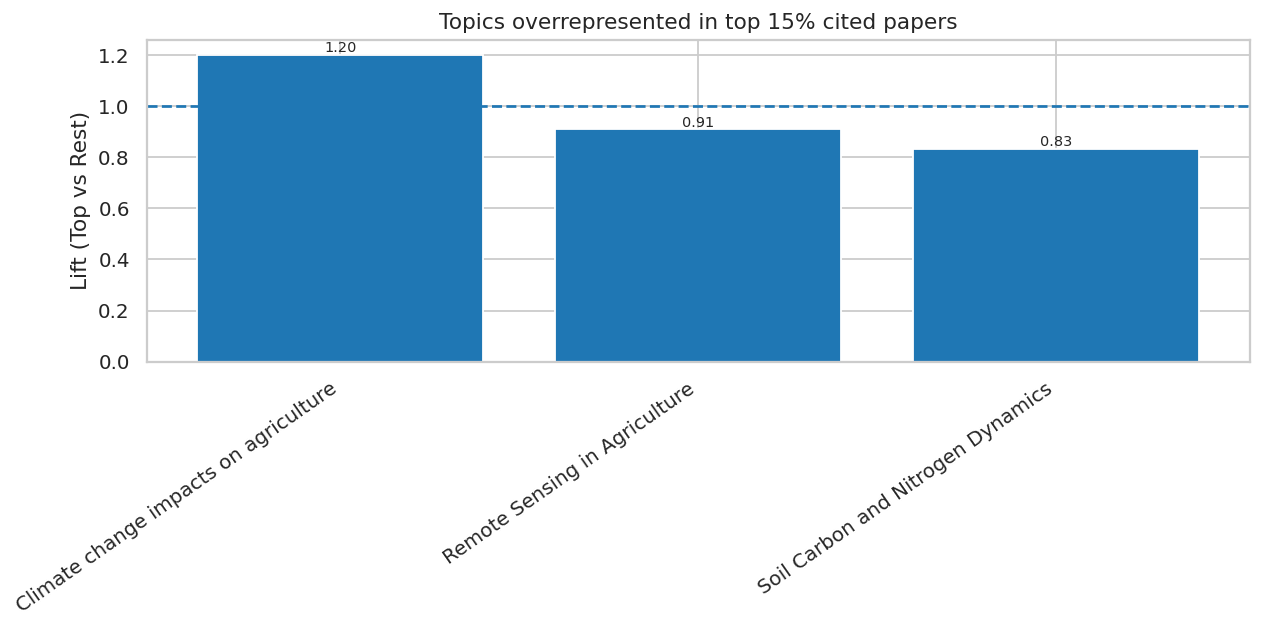

,topic,top_pct,rest_pct,lift,p_value,top_count,rest_count
0,Climate change impacts on agriculture,44.44,37.04,1.20,6.485e-01,12,30
1,Remote Sensing in Agriculture,37.04,40.74,0.91,9.096e-01,10,33
2,Soil Carbon and Nitrogen Dynamics,18.52,22.22,0.83,8.921e-01,5,18


In [193]:
# ── PARAMETERS ────────────────────────────────────────────────────────────────
TOP_PERCENTILE = 0.15   # top 10% most cited papers
MIN_COUNT = 15          # minimum papers per topic
TOP_K_PLOT = 10         # number of topics to display

# ── PREPARE DATA ──────────────────────────────────────────────────────────────
df = filtered_TargetA_df_corr.copy()
print(f"Initial dataset size: {df.size}")
# Remove missing
df = df.dropna(subset=[TOPIC_COL, "total_citations"])

# Filter low-frequency topics
topic_counts = df[TOPIC_COL].value_counts()
valid_topics = topic_counts[topic_counts >= MIN_COUNT].index
df = df[df[TOPIC_COL].isin(valid_topics)]
print(f"Dataset size after filtering: {df.size}")
print(f"Number of unique topics after filtering: {df[TOPIC_COL].nunique()}")

# ── DEFINE TOP PAPERS (percentile-based) ──────────────────────────────────────
threshold = df["total_citations"].quantile(1 - TOP_PERCENTILE)

top_df = df[df["total_citations"] >= threshold].copy()
print(f"Number of unique topics in the top set: {top_df[TOPIC_COL].nunique()}")

rest_df = df[df["total_citations"] < threshold].copy()
print(f"Number of unique topics in the rest set: {rest_df[TOPIC_COL].nunique()}")

print(f"Number of top papers: {top_df.shape[0]}")
print(f"Number of rest papers: {rest_df.shape[0]}")

#── FILTER TOPICS BY MEAN PAPERS IN TOP-CITED SET ────────────────────────────
top_counts_raw = top_df[TOPIC_COL].value_counts()
eligible_topics = top_counts_raw[top_counts_raw >= 5].index
print(
    f"Eligible topics in top set: "
    f"{len(eligible_topics)}/{len(top_counts_raw)}"
)

# Keep only eligible topics in both sets for a fair comparison
top_df = top_df[top_df[TOPIC_COL].isin(eligible_topics)].copy()
rest_df = rest_df[rest_df[TOPIC_COL].isin(eligible_topics)].copy()

if top_df.empty:
    print("No eligible top-cited topics after mean-paper filtering.")
    results_df = pd.DataFrame()
else:
    # ── DISTRIBUTIONS ─────────────────────────────────────────────────────────
    top_counts = top_df[TOPIC_COL].value_counts()
    rest_counts = rest_df[TOPIC_COL].value_counts()

    all_topics = sorted(top_counts.index)

    top_pct = (top_counts.reindex(all_topics, fill_value=0) / len(top_df)) * 100
    rest_den = len(rest_df) if len(rest_df) > 0 else np.nan
    rest_pct = (rest_counts.reindex(all_topics, fill_value=0) / rest_den) * 100

    # ── LIFT (overrepresentation) ─────────────────────────────────────────────
    lift = (top_pct / rest_pct).replace([np.inf, -np.inf], np.nan)

    # ── STATISTICAL SIGNIFICANCE (chi-square) ─────────────────────────────────
    results = []
    for topic in all_topics:
        a = top_counts.get(topic, 0)
        b = len(top_df) - a
        c = rest_counts.get(topic, 0)
        d = len(rest_df) - c

        table = [[a, b], [c, d]]

        try:
            chi2, p, _, _ = chi2_contingency(table)
        except Exception:
            p = np.nan

        results.append({
            "topic": topic,
            "top_pct": top_pct[topic],
            "rest_pct": rest_pct[topic],
            "lift": lift[topic],
            "p_value": p,
            "top_count": a,
            "rest_count": c
        })

    results_df = pd.DataFrame(results)

if not results_df.empty:
    # ── CLEAN + SORT ──────────────────────────────────────────────────────────
    results_df = results_df.dropna(subset=["lift"])
    results_df = results_df.sort_values("lift", ascending=False)

    # Keep top K for visualization
    plot_df = results_df.head(TOP_K_PLOT)

    # ── PLOT: LIFT (main result) ──────────────────────────────────────────────
    plt.figure()
    plt.bar(plot_df["topic"], plot_df["lift"])

    # Baseline
    plt.axhline(1, linestyle="--")

    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Lift (Top vs Rest)")
    plt.title(f"Topics overrepresented in top {int(TOP_PERCENTILE*100)}% cited papers")

    # Annotate values
    for i, v in enumerate(plot_df["lift"]):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── OPTIONAL: PRINT TABLE ─────────────────────────────────────────────────
    display(
        results_df.head(15).assign(
            top_pct=lambda x: x["top_pct"].round(2),
            rest_pct=lambda x: x["rest_pct"].round(2),
            lift=lambda x: x["lift"].round(2),
            p_value=lambda v: v["p_value"].apply(
                lambda p: f"{p:.3e}" if pd.notnull(p) else "nan"
            )
        )
    )
else:
    print("No topic lift results to display after filtering.")

# How much more likely is this topic to appear in top 10% cited papers compared to the rest?

In [260]:
# # Interactive table: top-cited topic per author per calendar year (corresponding papers only, deduped)
# try:
#     import ipywidgets as widgets
# except ImportError:
#     print("ipywidgets not installed. Run: pip install ipywidgets")
#     raise
# from IPython.display import display, clear_output

# topic_col_for_year = TOPIC_COL
# max_calendar_year = 2026

# df_topic_src = (
#     filtered_TargetA_df_corr
#     .dropna(subset=["queried_author", "publication_year", topic_col_for_year])
#     .copy()
#  )
# df_topic_src["publication_year"] = df_topic_src["publication_year"].astype(int)
# cit_cols = [c for c in df_topic_src.columns if c.startswith("citations_year_")]
# if not cit_cols:
#     print("No citations_year_* columns found; cannot build per-year citations table.")
#     cit_cols = []

# if cit_cols:
#     melted = (
#         df_topic_src[["article_id", "queried_author", "publication_year", topic_col_for_year] + cit_cols]
#         .melt(
#             id_vars=["article_id", "queried_author", "publication_year", topic_col_for_year],
#             value_vars=cit_cols,
#             var_name="cit_col",
#             value_name="citations",
#         )
#     )
#     melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
#     melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
#     melted["citations"] = melted["citations"].fillna(0)
#     melted = melted[melted["calendar_year"] <= max_calendar_year]

#     topic_year_stats = (
#         melted
#         .groupby(["queried_author", "calendar_year", topic_col_for_year])
#         .agg(
#             total_citations=("citations", "sum"),
#             n_papers=("article_id", "nunique"),
#         )
#         .reset_index()
#     )

#     dominant_by_year = (
#         topic_year_stats
#         .sort_values(
#             ["queried_author", "calendar_year", "total_citations", "n_papers", topic_col_for_year],
#             ascending=[True, True, False, False, True],
#         )
#         .groupby(["queried_author", "calendar_year"])
#     .head(1)
#     .rename(columns={topic_col_for_year: "dominant_topic"})
#     .reset_index(drop=True)
#     )
#     authors = sorted(dominant_by_year["queried_author"].unique().tolist())
# else:
#     melted = pd.DataFrame()
#     dominant_by_year = pd.DataFrame()
#     authors = []

# author_widget = widgets.Combobox(
#     options=authors,
#     placeholder="Type last name",
#     description="Author:",
#     ensure_option=False,
#     continuous_update=True,
#  )
# out = widgets.Output()

# def _resolve_author(input_text: str | None):
#     text = (input_text or "").strip()
#     if not text:
#         return None, "Type an author last name to filter."
#     matches = [a for a in authors if text.lower() in a.lower()]
#     if len(matches) == 1:
#         return matches[0], None
#     exact = [a for a in matches if a.lower() == text.lower()]
#     if len(exact) == 1:
#         return exact[0], None
#     if len(matches) == 0:
#         return None, f"No author match for '{text}'."
#     return None, "Multiple matches: " + ", ".join(matches)

# def _render(_change=None):
#     with out:
#         clear_output()
#         if dominant_by_year.empty:
#             print("No data to display.")
#             return
#         selected, msg = _resolve_author(author_widget.value)
#         if msg:
#             print(msg)
#             return
#         view = (
#             dominant_by_year[dominant_by_year["queried_author"] == selected]
#             .sort_values("calendar_year")
#             [["calendar_year", "dominant_topic",  "total_citations"]]
#             .reset_index(drop=True)
#         )
#         overall = (
#             melted[melted["queried_author"] == selected]
#             .groupby(topic_col_for_year)
#             .agg(
#                 total_citations=("citations", "sum"),
#                 n_papers=("article_id", "nunique"),
#             )
#             .reset_index()
#             .sort_values(["total_citations", "n_papers", topic_col_for_year], ascending=[False, False, True])
#         )
#         if not overall.empty:
#             top = overall.iloc[0]
#             summary_row = pd.DataFrame([
#                 {
#                     "calendar_year": "All years",
#                     "dominant_topic": top[topic_col_for_year],
#                     "total_citations": top["total_citations"],
#                 }
#             ])
#             view = pd.concat([view, summary_row], ignore_index=True)
#         display(view)

# author_widget.observe(_render, names="value")
# display(widgets.VBox([
#     widgets.HTML(f"<b>Top-cited {TOPIC_LEVEL_LABEL} per calendar year (through {max_calendar_year})</b>"),
#     author_widget,
#     out,
#  ]))
# _render()

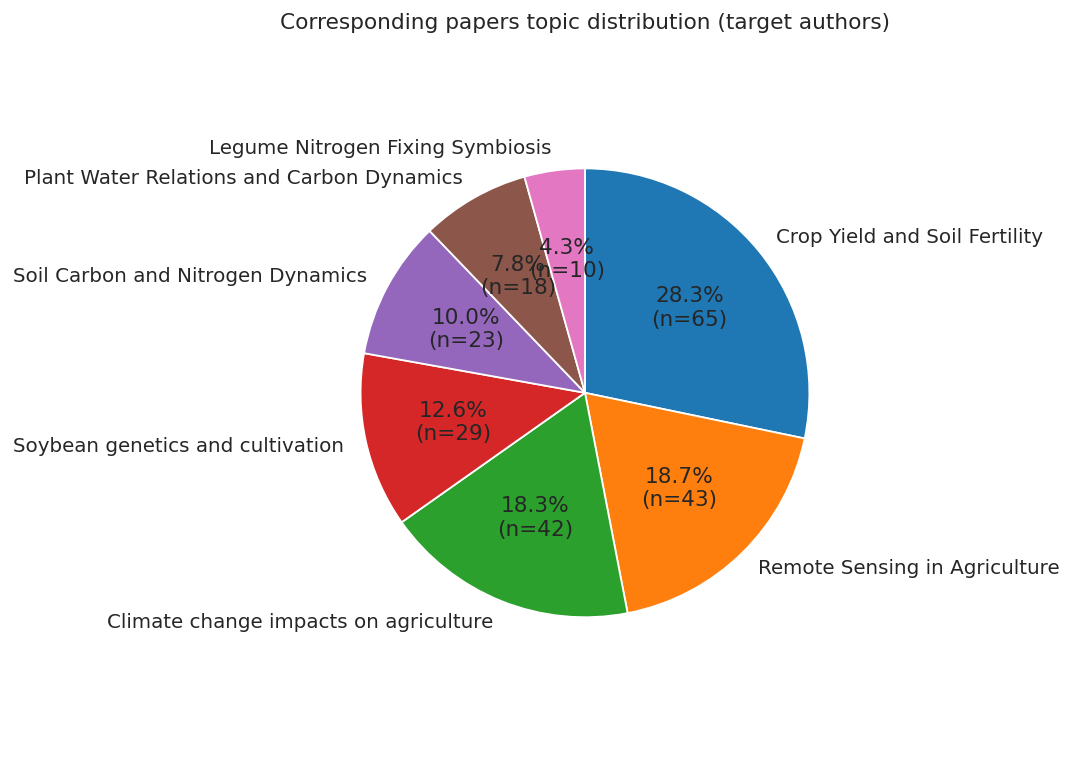

                                           papers  percent
primary_topic                                             
Crop Yield and Soil Fertility                  65     28.3
Remote Sensing in Agriculture                  43     18.7
Climate change impacts on agriculture          42     18.3
Soybean genetics and cultivation               29     12.6
Soil Carbon and Nitrogen Dynamics              23     10.0
Plant Water Relations and Carbon Dynamics      18      7.8
Legume Nitrogen Fixing Symbiosis               10      4.3


In [195]:
df_ta = filtered_TargetA_df_corr
specific_topic_col = TOPIC_COL

topic_counts = (
    df_ta.dropna(subset=[specific_topic_col])
    .groupby(specific_topic_col)
    .size()
    .sort_values(ascending=False)
    .head(7)
 )
total = int(topic_counts.sum())

def _autopct(pct):
    count = int(round(pct * total / 100.0))
    return f"{pct:.1f}%\n(n={count})"

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    topic_counts.values,
    labels=topic_counts.index.astype(str),
    autopct=_autopct,
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title("Corresponding papers topic distribution (target authors)")
ax.axis("equal")
plt.tight_layout()
plt.show()

topic_summary = topic_counts.rename("papers").to_frame()
topic_summary["percent"] = (topic_summary["papers"] / total * 100).round(1)
print(topic_summary)

Most cited topic per calendar year (citations per paper in that year):


,calendar_year,primary_topic,total_citations,n_papers,citations_per_paper
7,2025,Species Distribution and Climate Change,203.0,1,203.0
6,2024,Photovoltaic Systems and Sustainability,113.0,1,113.0
5,2023,Photovoltaic Systems and Sustainability,96.0,1,96.0
4,2022,Photovoltaic Systems and Sustainability,72.0,1,72.0
3,2021,Photovoltaic Systems and Sustainability,59.0,1,59.0
8,2026,Species Distribution and Climate Change,49.0,1,49.0
2,2020,Lipid metabolism and biosynthesis,20.0,1,20.0
1,2019,Plant Water Relations and Carbon Dynamics,32.0,2,16.0
0,2018,Genetics and Plant Breeding,9.0,1,9.0


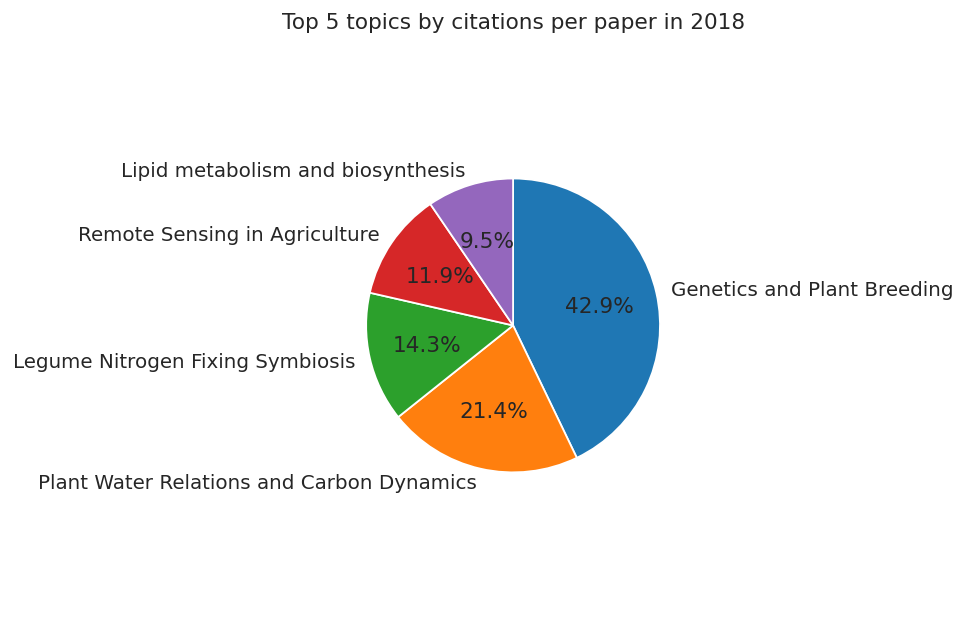

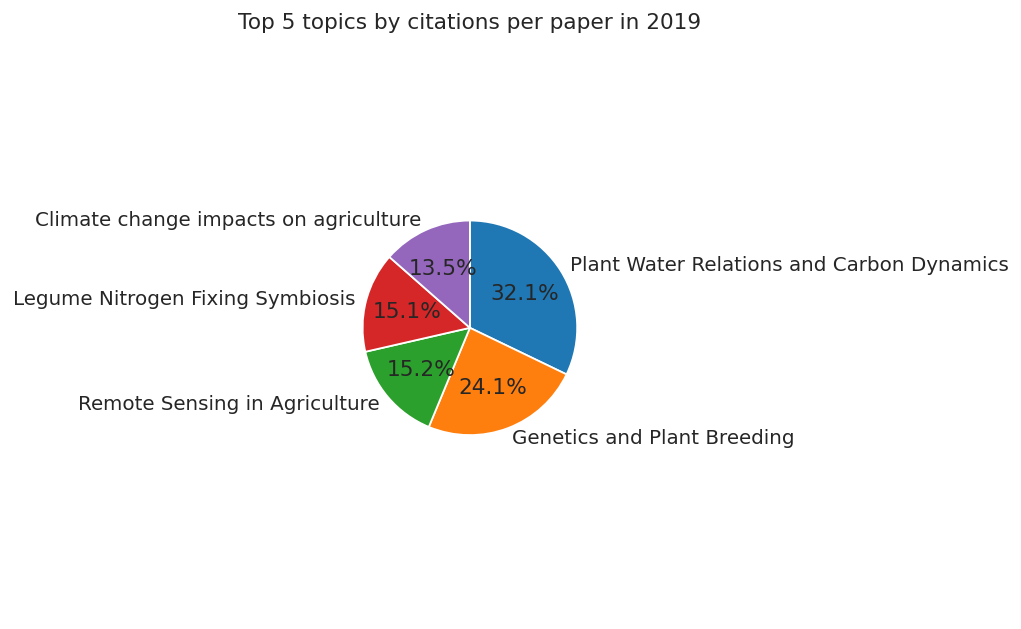

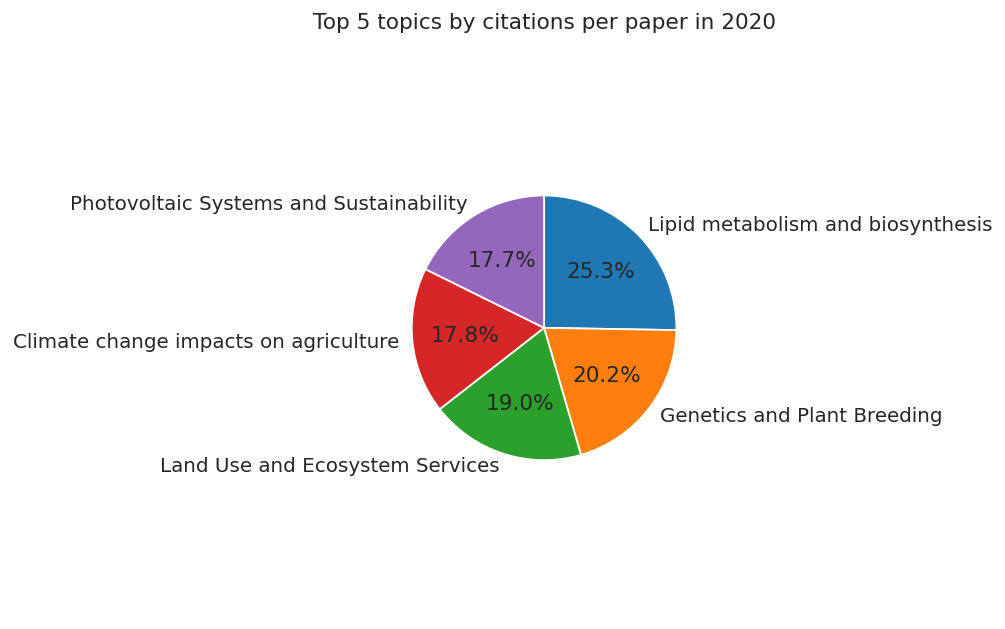

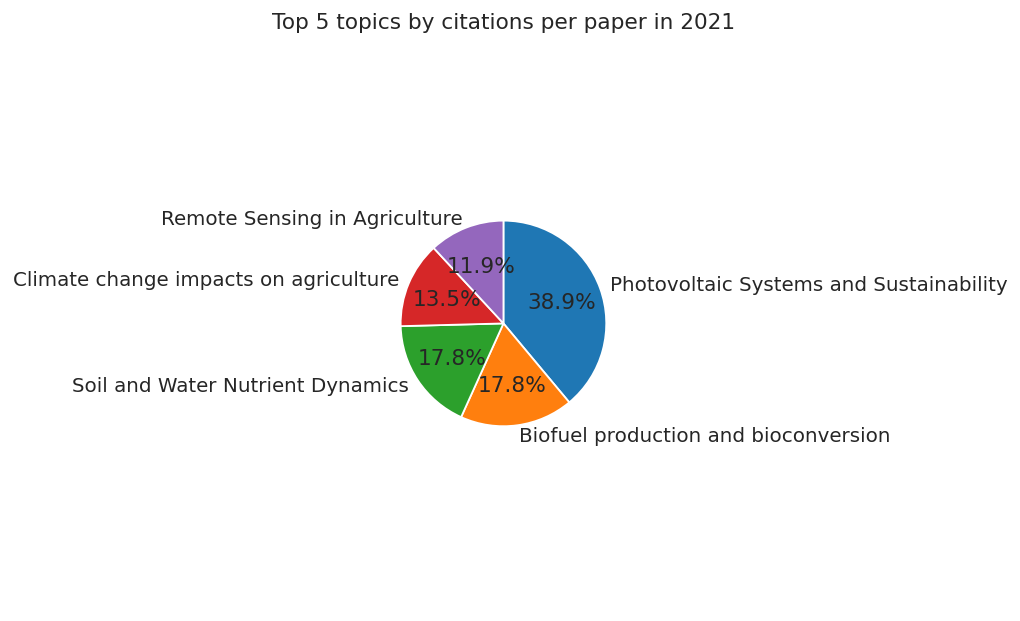

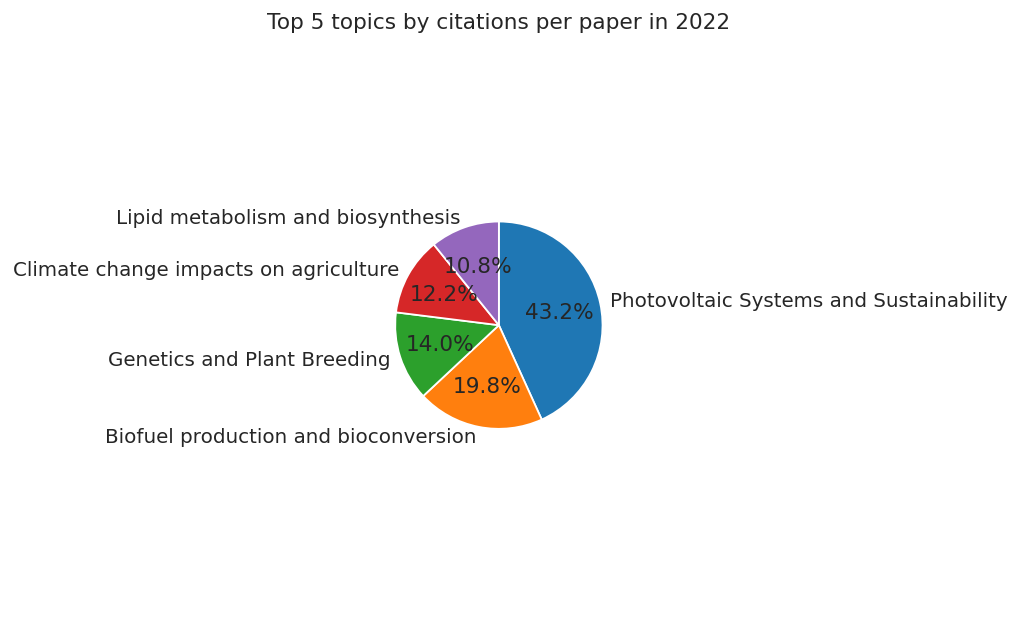

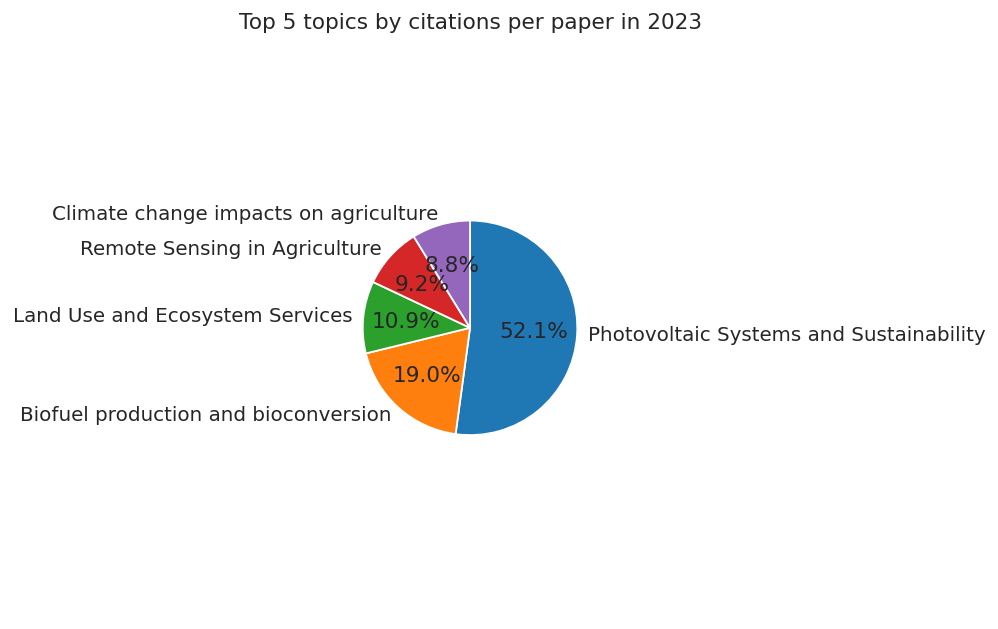

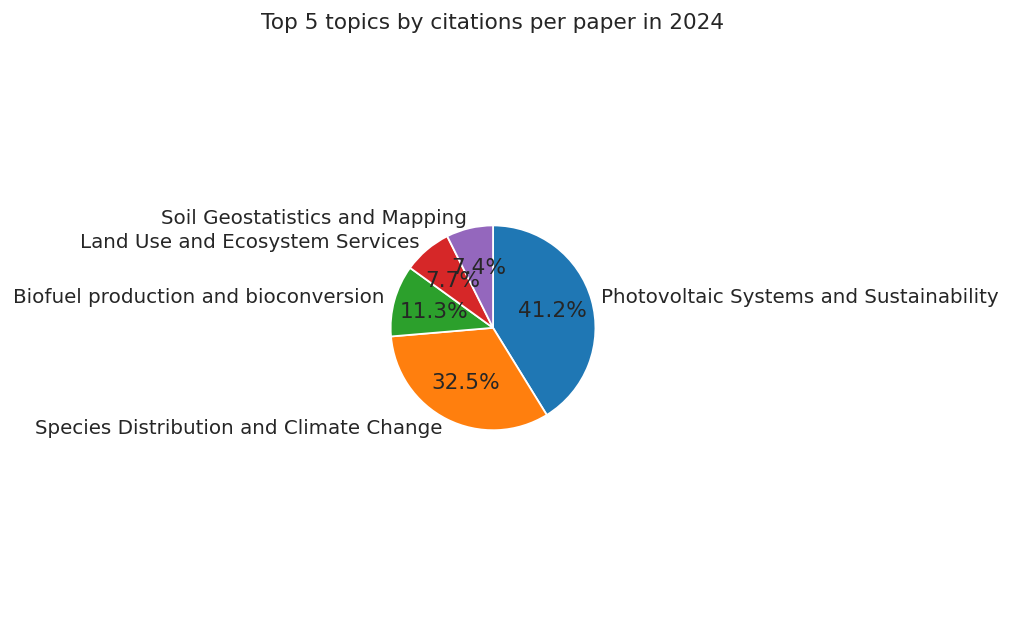

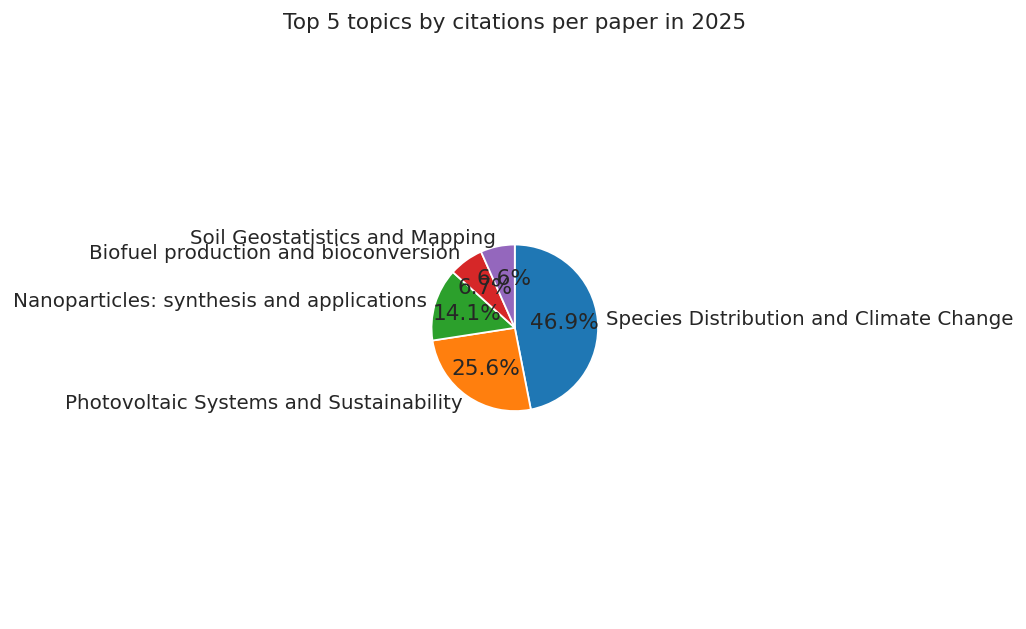

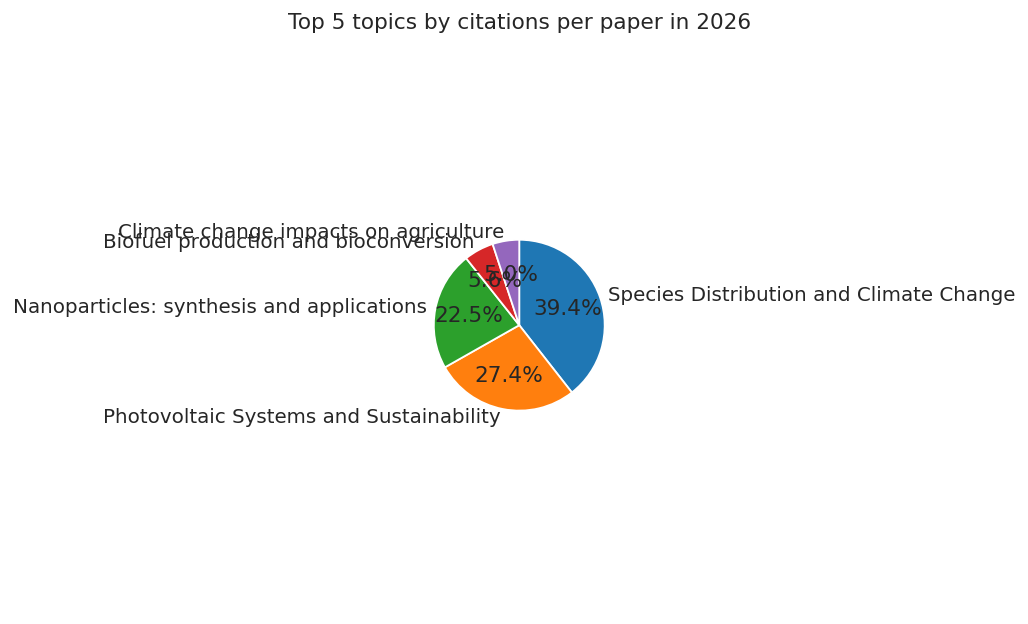

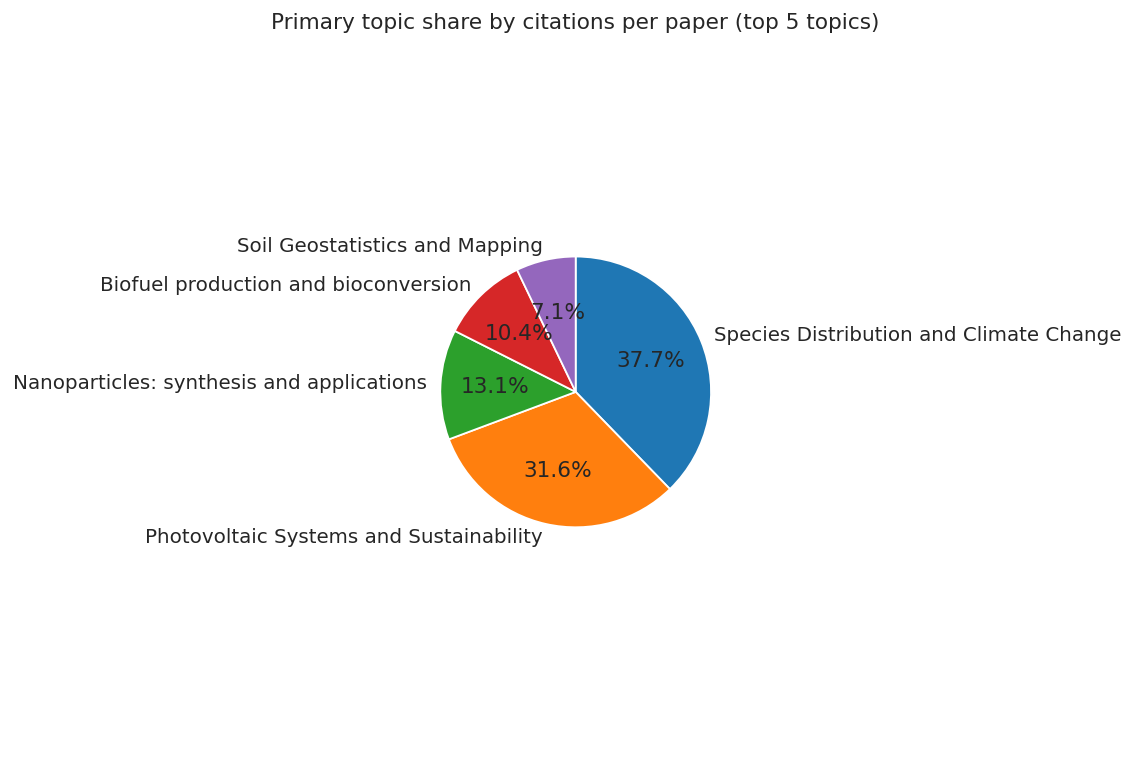

In [ ]:
# #Most cited topic per calendar year (citations received in that year)
# topic_col = TOPIC_COL
# df_topic = filtered_TargetA_df_corr.copy()
# cit_year_cols = [c for c in df_topic.columns if c.startswith("citations_year_")]
# current_year = CURRENT_YEAR if "CURRENT_YEAR" in globals() else 2026

# if not cit_year_cols:
#     print("No citations_year_* columns found. Cannot compute calendar-year citations.")
# else:
#     df_cit = df_topic.dropna(subset=[topic_col, "publication_year"]).copy()
#     melted = (
#         df_cit[["article_id", "publication_year", topic_col] + cit_year_cols]
#         .melt(
#             id_vars=["article_id", "publication_year", topic_col],
#             value_vars=cit_year_cols,
#             var_name="cit_col",
#             value_name="citations",
#         )
#     )
#     melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
#     melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
#     melted["citations"] = melted["citations"].fillna(0)
#     melted = melted[melted["calendar_year"] <= current_year]

#     citations_by_year_topic = (
#         melted.groupby(["calendar_year", topic_col])
#         .agg(
#             total_citations=("citations", "sum"),
#             n_papers=("article_id", "nunique"),
#         )
#         .reset_index()
#     )
#     citations_by_year_topic["citations_per_paper"] = (
#         citations_by_year_topic["total_citations"] / citations_by_year_topic["n_papers"].where(citations_by_year_topic["n_papers"] > 0)
#     )

#     top_topic_by_year = (
#         citations_by_year_topic
#         .sort_values(["calendar_year", "citations_per_paper", topic_col], ascending=[True, False, True])
#         .groupby("calendar_year")
#         .head(1)
#         .reset_index(drop=True)
#     )
    
#     print("Most cited topic per calendar year (citations per paper in that year):")
#     display(top_topic_by_year.sort_values("citations_per_paper", ascending=False))

#     # Per-year top-5 topics by citations per paper (one pie chart per year).
#     for year in sorted(citations_by_year_topic["calendar_year"].unique()):
#         year_df = (
#             citations_by_year_topic[citations_by_year_topic["calendar_year"] == year]
#             .sort_values(["citations_per_paper", topic_col], ascending=[False, True])
#             .head(5)
#         )
#         if year_df.empty:
#             continue
#         fig, ax = plt.subplots(figsize=(7, 5))
#         ax.pie(
#             year_df["citations_per_paper"].values,
#             labels=year_df[topic_col].astype(str),
#             autopct="%1.1f%%",
#             startangle=90,
#             counterclock=False,
#             wedgeprops={"edgecolor": "white"},
#         )
#         ax.set_title(f"Top 5 topics by citations per paper in {year}")
#         ax.axis("equal")
#         plt.tight_layout()
#         plt.show()

#     # Overall topic share by citations per paper (top 5 topics).
#     total_citations_by_topic = (
#         citations_by_year_topic.groupby(topic_col)["citations_per_paper"]
#         .mean()
#         .sort_values(ascending=False)
#     )
#     top_n = 5
#     pie_values = total_citations_by_topic.head(top_n)

#     fig, ax = plt.subplots(figsize=(8, 6))
#     ax.pie(
#         pie_values.values,
#         labels=pie_values.index.astype(str),
#         autopct="%1.1f%%",
#         startangle=90,
#         counterclock=False,
#         wedgeprops={"edgecolor": "white"},
#     )
#     ax.set_title(f"{TOPIC_LEVEL_LABEL} share by citations per paper (top 5 topics)")
#     ax.axis("equal")
#     plt.tight_layout()
#     plt.show()
    
    
# #It shows which research topics receive the most citations each year, and how citation attention is distributed across topics.

## Journal Analysis for target author

In [ ]:
# ---- Journal impact summary (2020-2025) ----
if not has_jnl_data or jnl_impact.empty:
    print("No journal impact data to display.")
else:
    plt.figure(figsize=(10, 5))
    plt.barh(
        jnl_impact[journal_col].head(12),
        jnl_impact["total_citations"].head(12),
        color="steelblue",
    )
    plt.xlabel("Total citations (2020-2025)")
    plt.title("Top journals by total citations (corresponding papers)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    display(jnl_impact.head(12))

In [265]:
# # ---- Most-cited journal per author per year (interactive) ----
# if not has_jnl_data or dominant_journal_by_year.empty:
#     print("No data to display.")
# else:
#     try:
#         import ipywidgets as widgets
#     except ImportError:
#         print("ipywidgets not installed. Run: pip install ipywidgets")
#         raise
#     from IPython.display import display, clear_output

#     authors = sorted(dominant_journal_by_year["queried_author"].unique().tolist())
#     author_widget = widgets.Combobox(
#         options=authors,
#         placeholder="Type last name",
#         description="Author:",
#         ensure_option=False,
#         continuous_update=True,
#     )
#     out = widgets.Output()

#     def _resolve_author(input_text: str | None):
#         text = (input_text or "").strip()
#         if not text:
#             return None, "Type an author last name to filter."
#         matches = [a for a in authors if text.lower() in a.lower()]
#         if len(matches) == 1:
#             return matches[0], None
#         exact = [a for a in matches if a.lower() == text.lower()]
#         if len(exact) == 1:
#             return exact[0], None
#         if len(matches) == 0:
#             return None, f"No author match for '{text}'."
#         return None, "Multiple matches: " + ", ".join(matches)

#     def _render(_change=None):
#         with out:
#             clear_output()
#             selected, msg = _resolve_author(author_widget.value)
#             if msg:
#                 print(msg)
#                 return
#             view = (
#                 dominant_journal_by_year[dominant_journal_by_year["queried_author"] == selected]
#                 .sort_values("calendar_year")
#                 [["calendar_year", "top_journal", "n_papers", "total_citations"]]
#                 .reset_index(drop=True)
#             )
#             overall = (
#                 jnl_author_year[jnl_author_year["queried_author"] == selected]
#                 .groupby(journal_col)
#                 .agg(
#                     total_citations=("total_citations", "sum"),
#                     n_papers=("n_papers", "sum"),
#                 )
#                 .reset_index()
#                 .sort_values(["total_citations", "n_papers", journal_col], ascending=[False, False, True])
#             )
#             if not overall.empty:
#                 top = overall.iloc[0]
#                 summary_row = pd.DataFrame([
#                     {
#                         "calendar_year": "All years",
#                         "top_journal": top[journal_col],
#                         "n_papers": int(top["n_papers"]),
#                         "total_citations": top["total_citations"],
#                     }
#                 ])
#                 view = pd.concat([view, summary_row], ignore_index=True)
#             display(view)

#     author_widget.observe(_render, names="value")
#     display(widgets.VBox([
#         widgets.HTML("<b>Top-cited journal per calendar year (2020-2025)</b>"),
#         author_widget,
#         out,
#     ]))
#     _render()

In [266]:
# df = filtered_TargetA_df_corr.sort_values('publication_year')
# top_journals = df.groupby('journal_display_name')['total_citations'].sum().sort_values(ascending=False).head(5).index

# plt.figure(figsize=(8,5))
# for journal in top_journals:
#     df_journal = df[df['journal_display_name'] == journal]
#     years, h, mean_cit, median_cit = cumulative_metrics(df_journal)
#     plt.plot(years, h, marker='o', label=f'{journal} ')

# plt.xlabel('Publication Year')
# plt.ylabel('Cumulative H-index')
# plt.title('Cumulative H-index for Top 5 Journals')
# plt.xticks(years, rotation=45)
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

-----
# 10 Years Analysis

In [207]:
ta_ten=pd.read_csv("/home/ramir713/PublicationAnalysis/data/ta_ten_corr.csv")
ta_ten_corr=ta_ten[ta_ten["is_corresponding_author"]].copy()
ta_ten_corr.to_csv("/home/ramir713/PublicationAnalysis/data/ta_ten_corr.csv", index=False)
papers_per_author = ta_ten_corr["queried_author"].value_counts()
print("\nPapers per Target_author author (corresponding only, 2015–2025):")
papers_per_author


Papers per Target_author author (corresponding only, 2015–2025):


queried_author
Ciampitti       135
Kaiyu            78
Vara Prasad      48
Grassini         42
Archontoulis     36
Basso            29
Lobell           26
Messina          16
Peng             14
Hoogenboom       14
Castellano        9
Rattalino         5
Name: count, dtype: int64

In [208]:
def get_citation_curve_single_paper(df, article_id, max_year=12):
    row = df[df["article_id"] == article_id].iloc[0]

    data = []
    for i in range(max_year + 1):
        col = f"citations_year_{i}"
        citations = row.get(col, 0)
        citations = 0 if pd.isna(citations) else citations
        data.append((i, citations))

    curve_df = pd.DataFrame(data, columns=["year_since_pub", "citations"])
    return curve_df

In [209]:
# Citation-by-year columns (from get_publications_table)
cit_cols = [c for c in ta_ten_corr.columns if c.startswith("citations_year_")]

ciampitti_df = ta_ten_corr[
    ta_ten_corr["queried_author"].str.contains("ciampitti", case=False, na=False)
]

# Keep papers with citations in at least 3 different years
ciampitti_3yr = ciampitti_df[
    (ciampitti_df[cit_cols] > 0).sum(axis=1) >= 3
]

random_paper = ciampitti_3yr.sample(n=1)
random_paper.title


275    Soybean yield response to nitrogen and sulfur ...
Name: title, dtype: str

In [210]:
paper_id =random_paper["article_id"].iloc[0]  
curve_df = get_citation_curve_single_paper(ta_ten, paper_id)

curve_df

,year_since_pub,citations
0,0,3.0
1,1,7.0
2,2,4.0
3,3,2.0
4,4,0.0
5,5,0.0
6,6,0.0
7,7,0.0
8,8,0.0
9,9,0.0


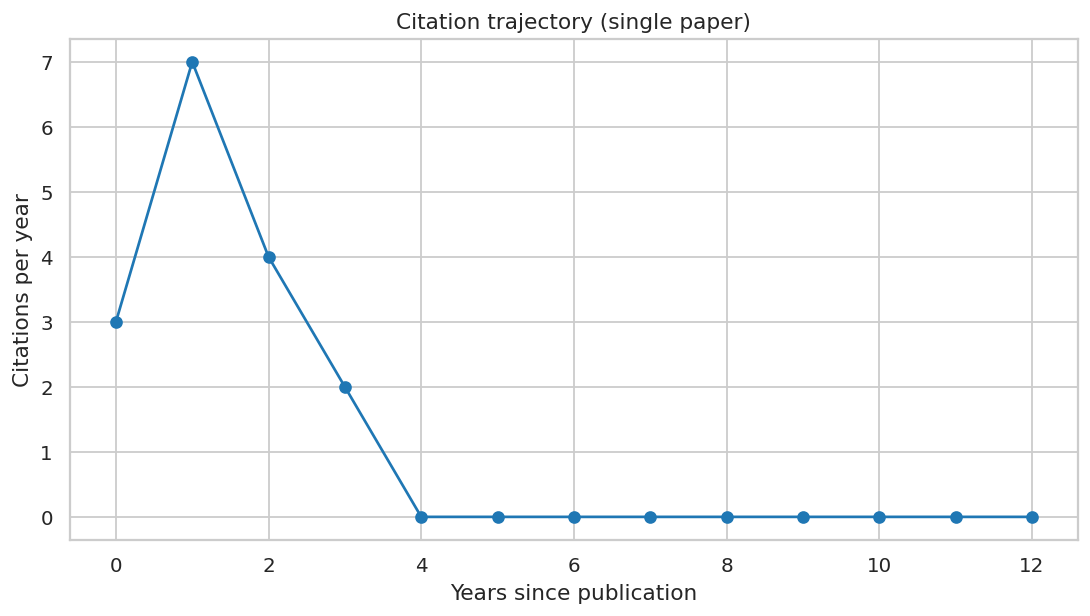

In [211]:
plt.figure()
plt.plot(curve_df["year_since_pub"], curve_df["citations"], marker='o')
plt.xlabel("Years since publication")
plt.ylabel("Citations per year")
plt.title("Citation trajectory (single paper)")
plt.grid(True)
plt.show()

In [212]:
def build_citation_matrix(df, max_year=12):
    citation_matrix = []

    for _, row in df.iterrows():
        row_data = {"article_id": row["article_id"]}

        for i in range(max_year + 1):
            col = f"citations_year_{i}"

            if col in df.columns:
                val = row[col]
                row_data[f"y{i}"] = val if pd.notna(val) else 0
            else:
                # Year does not exist → should be NaN
                row_data[f"y{i}"] = None

        citation_matrix.append(row_data)

    return pd.DataFrame(citation_matrix)

citation_matrix = build_citation_matrix(ta_ten_corr, max_year=12)
print(citation_matrix.size)
citation_matrix.head()

6328


,article_id,y0,y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11,y12
0,https://openalex.org/W2162852129,2.0,21.0,35.0,62.0,53.0,60.0,86.0,86.0,88.0,97.0,112.0,31.0,None
1,https://openalex.org/W2942591112,7.0,46.0,78.0,101.0,108.0,107.0,112.0,28.0,0.0,0.0,0.0,0.0,None
2,https://openalex.org/W2944794516,7.0,34.0,93.0,104.0,104.0,110.0,95.0,16.0,0.0,0.0,0.0,0.0,None
3,https://openalex.org/W612661449,2.0,10.0,26.0,41.0,56.0,63.0,70.0,70.0,60.0,70.0,70.0,21.0,None
4,https://openalex.org/W2791592925,6.0,41.0,62.0,77.0,92.0,70.0,96.0,62.0,15.0,0.0,0.0,0.0,None


In [213]:
def compute_aggregate_curves(citation_matrix):
    """
    Compute mean and median citation curves across all papers.
    Ignores NaN values (correct handling of missing years).
    """
    years = [col for col in citation_matrix.columns if col.startswith("y")]

    mean_curve = citation_matrix[years].mean(axis=0, skipna=True)
    median_curve = citation_matrix[years].median(axis=0, skipna=True)

    curve_df = pd.DataFrame({
        "year_since_pub": [int(y[1:]) for y in years],
        "mean_citations": mean_curve.values,
        "median_citations": median_curve.values
    })

    return curve_df.sort_values("year_since_pub")
agg_curve = compute_aggregate_curves(citation_matrix)

agg_curve

,year_since_pub,mean_citations,median_citations
0,0,2.108407,1.0
1,1,8.168142,5.0
2,2,9.816372,5.0
3,3,9.099558,4.0
4,4,7.794248,2.0
5,5,6.473451,0.0
6,6,4.977876,0.0
7,7,3.524336,0.0
8,8,2.103982,0.0
9,9,1.502212,0.0


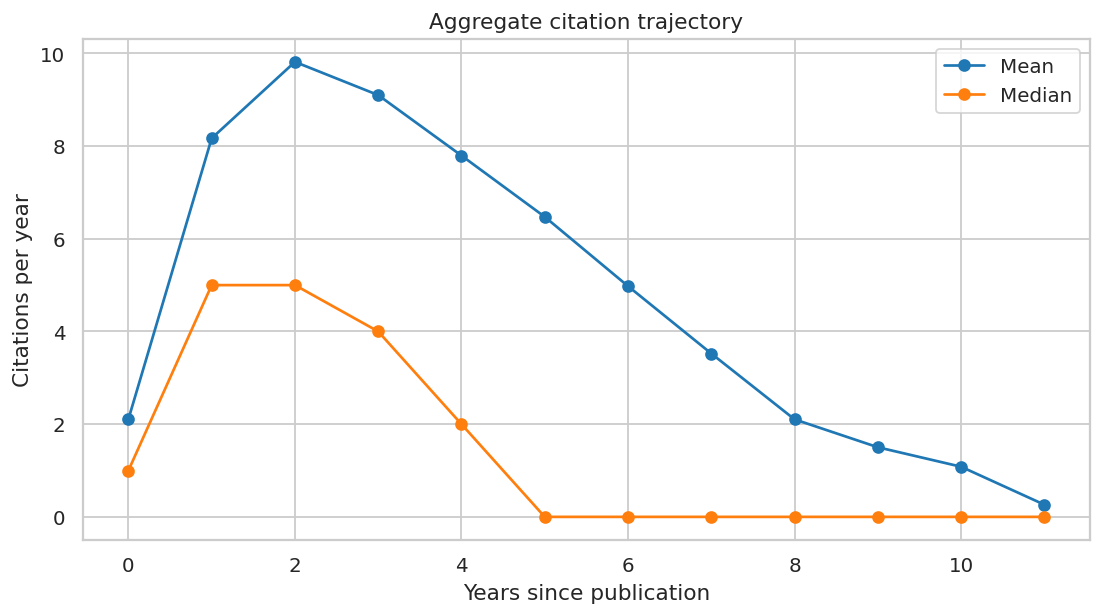

In [214]:
plt.figure()

plt.plot(agg_curve["year_since_pub"], agg_curve["mean_citations"], marker='o', label="Mean")
plt.plot(agg_curve["year_since_pub"], agg_curve["median_citations"], marker='o', label="Median")

plt.xlabel("Years since publication")
plt.ylabel("Citations per year")
plt.title("Aggregate citation trajectory")
plt.legend()
plt.grid(True)

plt.show()

In [215]:
def normalize_citation_matrix(citation_matrix):
    """
    Normalize each paper's citation curve by its total citations.
    Converts absolute counts → relative shape.
    """
    years = [col for col in citation_matrix.columns if col.startswith("y")]

    norm_matrix = citation_matrix.copy()

    for idx, row in norm_matrix.iterrows():
        values = row[years]
        total = values.sum(skipna=True)

        if total > 0:
            norm_matrix.loc[idx, years] = values / total

    return norm_matrix
norm_matrix = normalize_citation_matrix(citation_matrix)
norm_agg_curve = compute_aggregate_curves(norm_matrix)
norm_agg_curve = norm_agg_curve.dropna()
norm_agg_curve

,year_since_pub,mean_citations,median_citations
0,0,0.107756,0.019682
1,1,0.250818,0.166667
2,2,0.19274,0.174306
3,3,0.137409,0.137147
4,4,0.097612,0.081967
5,5,0.063142,0.0
6,6,0.041364,0.0
7,7,0.029619,0.0
8,8,0.015521,0.0
9,9,0.009013,0.0


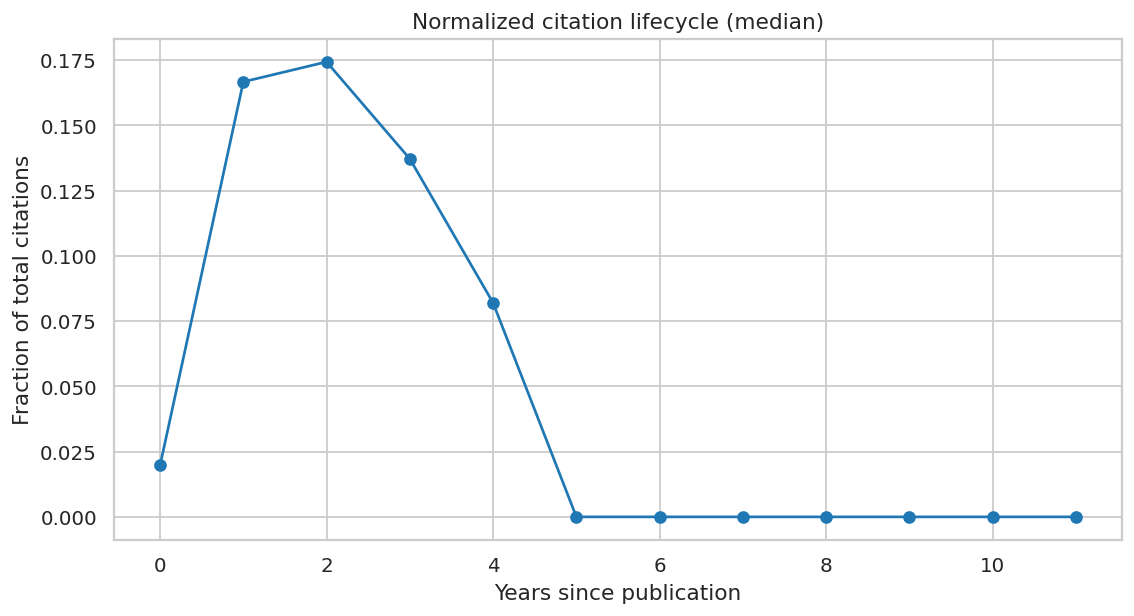

In [216]:
plt.figure()

plt.plot(norm_agg_curve["year_since_pub"], norm_agg_curve["median_citations"], marker='o')

plt.xlabel("Years since publication")
plt.ylabel("Fraction of total citations")
plt.title("Normalized citation lifecycle (median)")
plt.grid(True)

plt.show()

In [217]:
def compute_author_curves(citation_matrix, df):
    """
    Compute median citation curve per author.
    """
    # Merge author info
    merged = citation_matrix.merge(
        df[["article_id", "queried_author"]],
        on="article_id",
        how="left"
    )

    years = [col for col in citation_matrix.columns if col.startswith("y")]

    author_curves = []

    for author, group in merged.groupby("queried_author"):

        median_curve = group[years].median(skipna=True)

        row = {
            "author": author,
            **{f"y{i}": median_curve.get(f"y{i}", None) for i in range(len(years))}
        }

        author_curves.append(row)

    return pd.DataFrame(author_curves)

author_curves = compute_author_curves(citation_matrix, ta_ten_corr)

author_curves.head()

,author,y0,y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11,y12
0,Archontoulis,1.0,8.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,Basso,1.0,3.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,Castellano,1.0,5.0,7.0,6.0,6.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,Ciampitti,1.0,4.0,5.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,Grassini,0.5,5.0,5.0,4.5,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


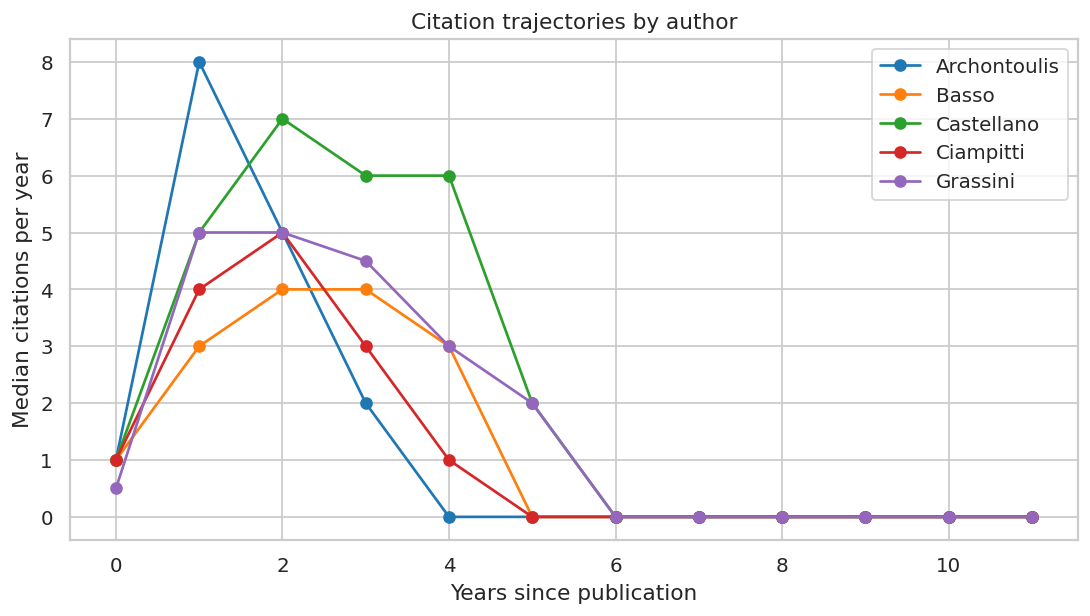

In [218]:
plt.figure()

years = [col for col in author_curves.columns if col.startswith("y")]

for _, row in author_curves.head(5).iterrows():
    values = [row[y] for y in years]
    plt.plot(range(len(years)), values, marker='o', label=row["author"])

plt.xlabel("Years since publication")
plt.ylabel("Median citations per year")
plt.title("Citation trajectories by author")
plt.legend()
plt.grid(True)

plt.show()

In [219]:
def normalize_author_curves(author_curves):
    """
    Normalize each author's citation curve so it sums to 1.
    """
    years = [col for col in author_curves.columns if col.startswith("y")]

    norm_df = author_curves.copy()

    for idx, row in norm_df.iterrows():
        values = row[years]
        total = values.sum(skipna=True)

        if total > 0:
            norm_df.loc[idx, years] = values / total

    return norm_df
norm_author_curves = normalize_author_curves(author_curves)
norm_author_curves.head()

,author,y0,y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11,y12
0,Archontoulis,0.062500,0.500000,0.312500,0.125000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,Basso,0.066667,0.200000,0.266667,0.266667,0.200000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,Castellano,0.037037,0.185185,0.259259,0.222222,0.222222,0.074074,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,Ciampitti,0.071429,0.285714,0.357143,0.214286,0.071429,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,Grassini,0.025000,0.250000,0.250000,0.225000,0.150000,0.100000,0.0,0.0,0.0,0.0,0.0,0.0,NaN


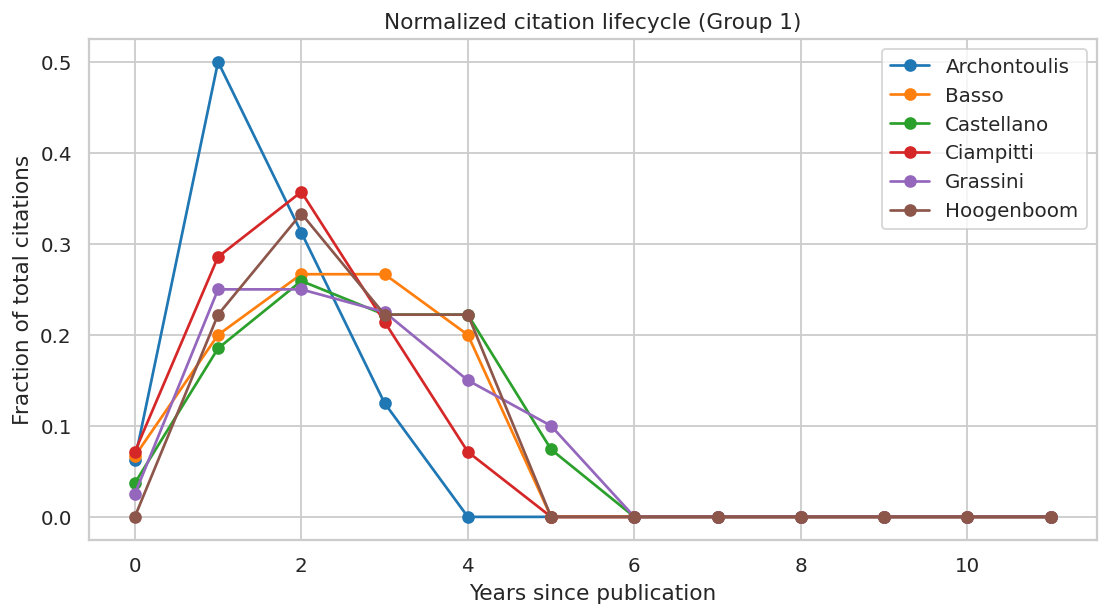

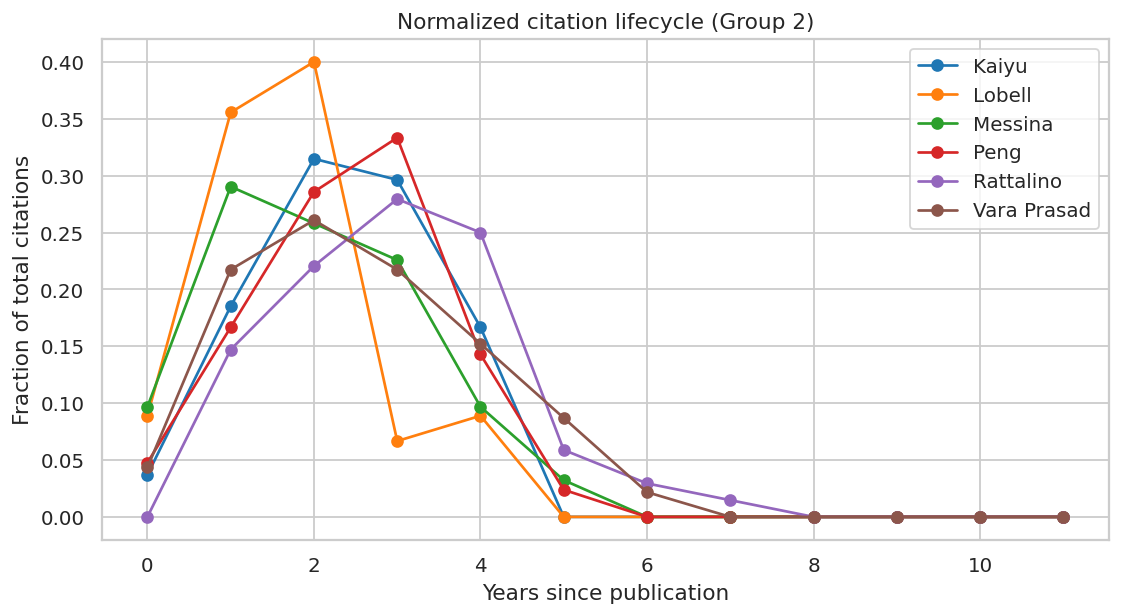

In [220]:
def plot_author_groups(norm_author_curves):
    years = [col for col in norm_author_curves.columns if col.startswith("y")]

    authors = norm_author_curves["author"].tolist()
    mid = len(authors) // 2

    groups = [
        norm_author_curves.iloc[:mid],
        norm_author_curves.iloc[mid:]
    ]

    for i, group in enumerate(groups, 1):
        plt.figure()

        for _, row in group.iterrows():
            values = [row[y] for y in years]
            plt.plot(range(len(years)), values, marker='o', label=row["author"])

        plt.xlabel("Years since publication")
        plt.ylabel("Fraction of total citations")
        plt.title(f"Normalized citation lifecycle (Group {i})")
        plt.legend()
        plt.grid(True)

        plt.show()
plot_author_groups(norm_author_curves)

In [221]:
def get_peak_years(norm_author_curves):
    years = [col for col in norm_author_curves.columns if col.startswith("y")]

    peaks = []
    for _, row in norm_author_curves.iterrows():
        values = row[years].astype(float)

        peak_year = values.idxmax()
        peak_year = int(peak_year[1:])
        peak_value = values.max()

        peaks.append({
            "author": row["author"],
            "peak_year": peak_year,
            "peak_fraction": peak_value
        })

    return pd.DataFrame(peaks).sort_values("peak_year")
peak_df = get_peak_years(norm_author_curves)
peak_df

,author,peak_year,peak_fraction
0,Archontoulis,1,0.500000
4,Grassini,1,0.250000
8,Messina,1,0.290323
2,Castellano,2,0.259259
3,Ciampitti,2,0.357143
5,Hoogenboom,2,0.333333
6,Kaiyu,2,0.314815
1,Basso,2,0.266667
7,Lobell,2,0.400000
11,Vara Prasad,2,0.260870


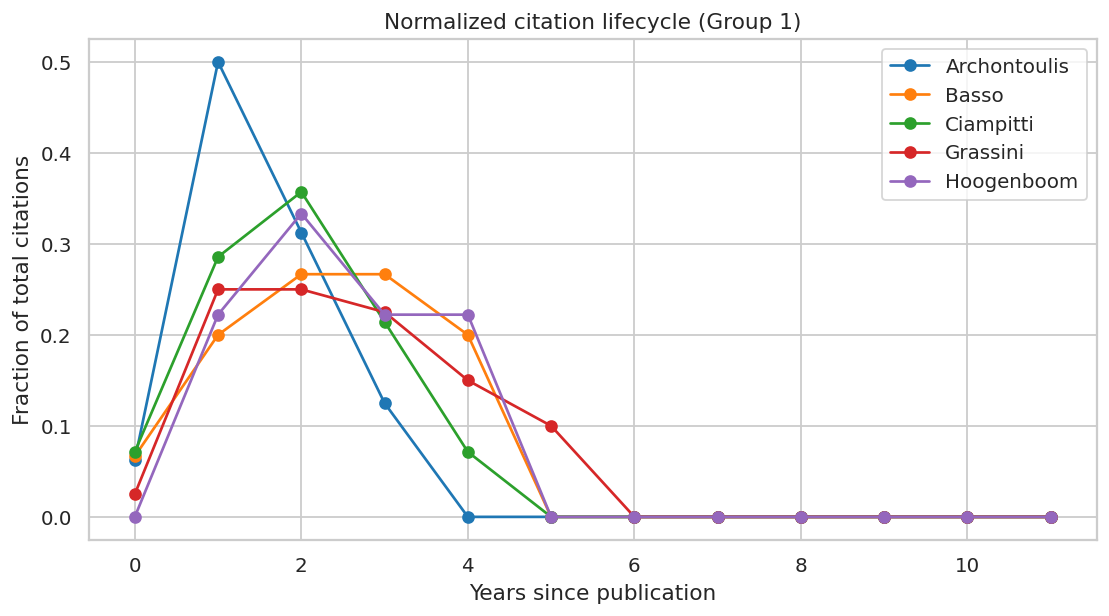

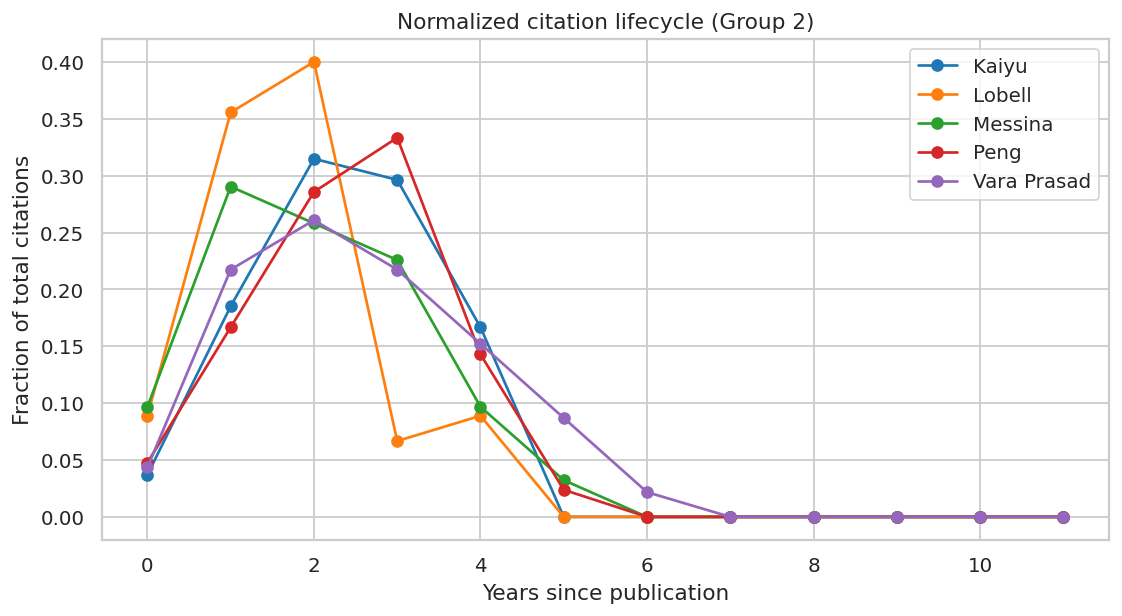

In [222]:
author_counts = ta_ten_corr["queried_author"].value_counts()
valid_authors = author_counts[author_counts >= 10].index

filtered_curves = norm_author_curves[
    norm_author_curves["author"].isin(valid_authors)
]
plot_author_groups(filtered_curves)
#Esto es teniendo en cuenta autores con al menos 10 papers, para evitar ruido de pocos datos. Se pueden ajustar ese umbral o eliminarlo para incluir a todos los autores.

In [223]:
from sklearn.cluster import KMeans

years = [col for col in filtered_curves.columns if col.startswith("y")]

X = filtered_curves[years].fillna(0).values

In [224]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

filtered_curves["cluster"] = clusters

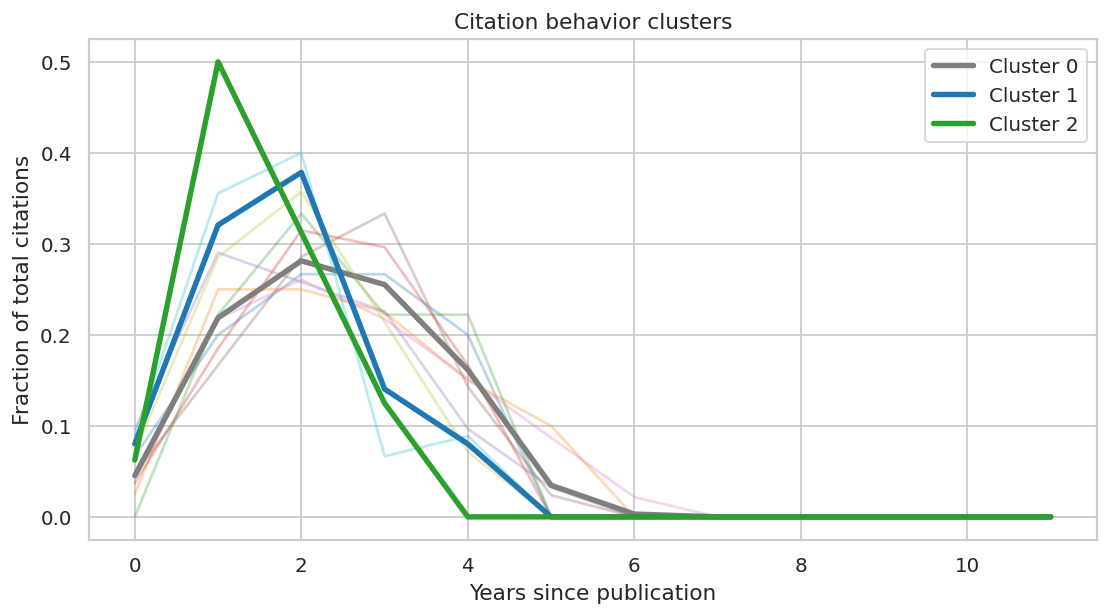

In [225]:
plt.figure()

for cluster_id in sorted(filtered_curves["cluster"].unique()):
    group = filtered_curves[filtered_curves["cluster"] == cluster_id]

    for _, row in group.iterrows():
        values = [row[y] for y in years]
        plt.plot(range(len(years)), values, alpha=0.3)

    # plot cluster mean
    mean_curve = group[years].mean()
    plt.plot(range(len(years)), mean_curve, linewidth=3, label=f"Cluster {cluster_id}")

plt.xlabel("Years since publication")
plt.ylabel("Fraction of total citations")
plt.title("Citation behavior clusters")
plt.legend()
plt.grid(True)

plt.show()

-----
# All Authors

In [226]:
metrics_all_df = calculate_author_metrics(filtered_all_df_corr, author_col='queried_author', citations_col='total_citations')
metrics_all_df.head(10)

,queried_author,h_index,i10_index
0,Adrián A. Correndo,9,9
1,Alex C. Ruane,2,2
2,Ana Julia Paula Carcedo,7,6
3,Archontoulis,19,21
4,Basso,13,15
5,Benjamin Dumont,2,1
6,Carl J. Bernacchi,15,16
7,Castellano,6,5
8,Chongya Jiang,6,6
9,Ciampitti,34,81


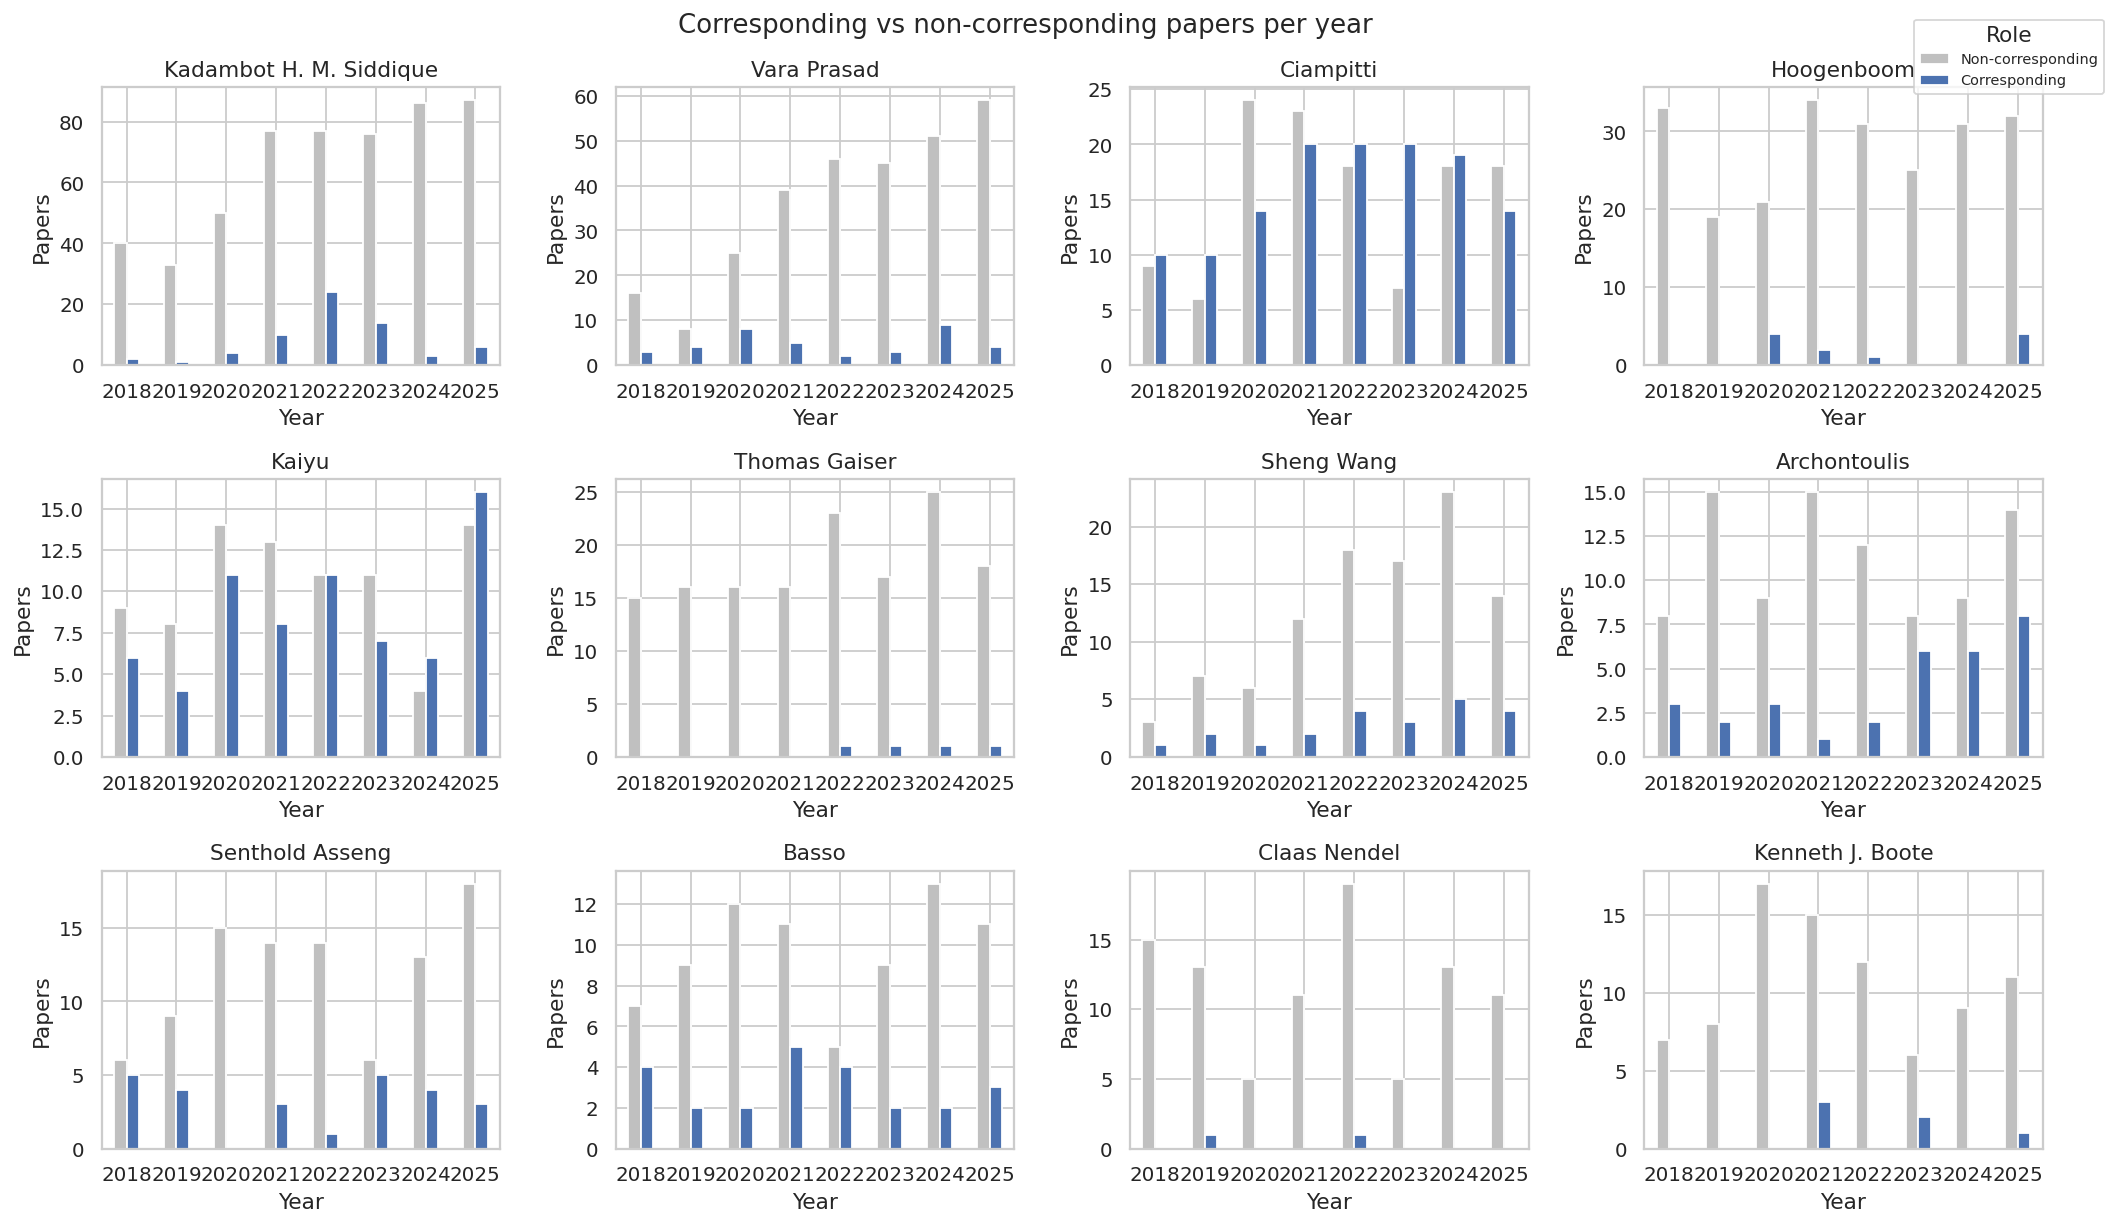

In [227]:

df_ta = filtered_all_df.copy()
# ---- Corresponding vs non-corresponding papers per year by author ----
top_authors = (
    df_ta.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(12)
    .index.tolist()
)

corr_year_author = (
    df_ta[df_ta["queried_author"].isin(top_authors)]
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year", "is_corresponding_author"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "Corresponding", False: "Non-corresponding"})
)

n_authors = len(top_authors)
ncols = 4
nrows = int(np.ceil(n_authors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, author in enumerate(top_authors):
    ax = axes_flat[i]
    data = corr_year_author.loc[author].sort_index()
    data.plot(kind="bar", stacked=False, ax=ax, color=["#C0C0C0", "#4C72B0"], edgecolor="white", legend=False)
    ax.set_title(author)
    ax.set_xlabel("Year")
    ax.set_ylabel("Papers")
    ax.tick_params(axis="x", rotation=0)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Corresponding vs non-corresponding papers per year ")
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 0.98), fontsize=8, title="Role")
plt.tight_layout()
plt.show()

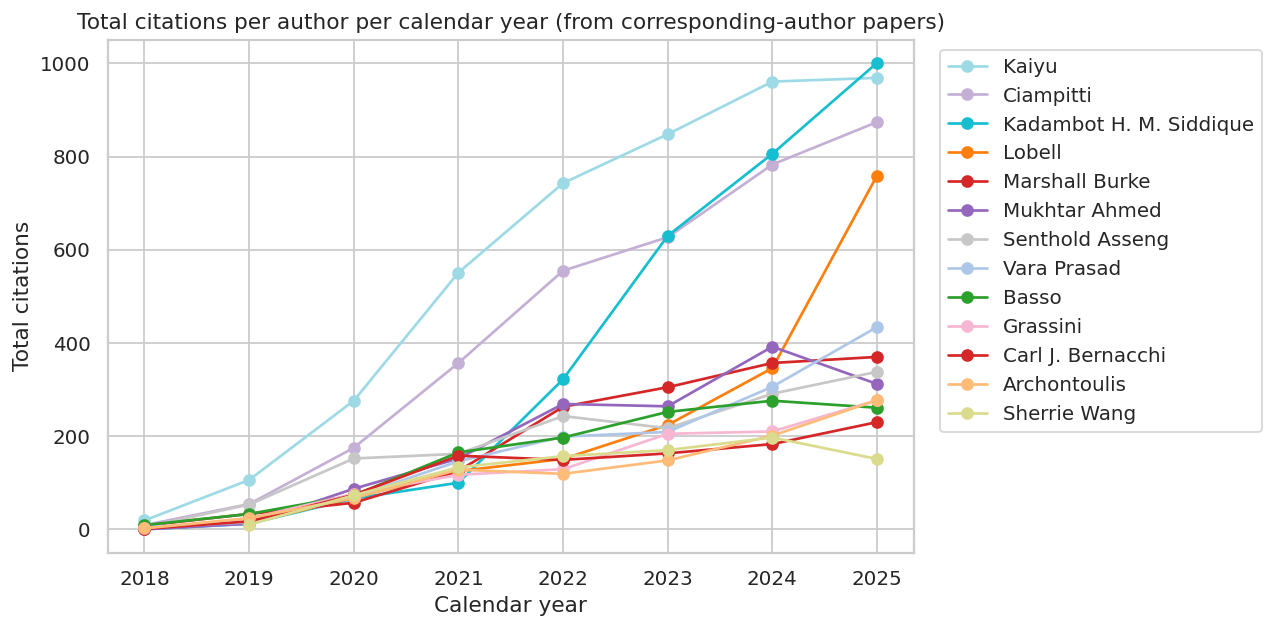

In [228]:
df = filtered_all_df_corr.copy()  
cit_cols = [c for c in df.columns if c.startswith("citations_year_")]

melted = (
    df.dropna(subset=["publication_year"])
    .melt(
          id_vars=["queried_author", "publication_year"],
          value_vars=cit_cols,
          var_name="cit_col",
          value_name="citations",
      )
)

melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"] = melted["citations"].fillna(0)

max_year = 2025
melted = melted[melted["calendar_year"] <= max_year]

author_year = (
    melted.groupby(["queried_author", "calendar_year"], as_index=False)
    .agg(total_citations=("citations", "sum"))
)

# Plot (example for top authors)
top_authors = (
    author_year.groupby("queried_author")["total_citations"]
    .sum().sort_values(ascending=False).head(13).index
)

authors_all = sorted(df["queried_author"].dropna().unique().tolist())
palette = sns.color_palette("tab20", n_colors=len(authors_all))
author_color_map = dict(zip(authors_all, palette))

plt.figure(figsize=(10, 5))
for author in top_authors:
    g = author_year[author_year["queried_author"] == author]
    plt.plot(g["calendar_year"], g["total_citations"], marker="o", label=author, color=author_color_map.get(author))

plt.title("Total citations per author per calendar year (from corresponding-author papers)")
plt.xlabel("Calendar year")
plt.ylabel("Total citations")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

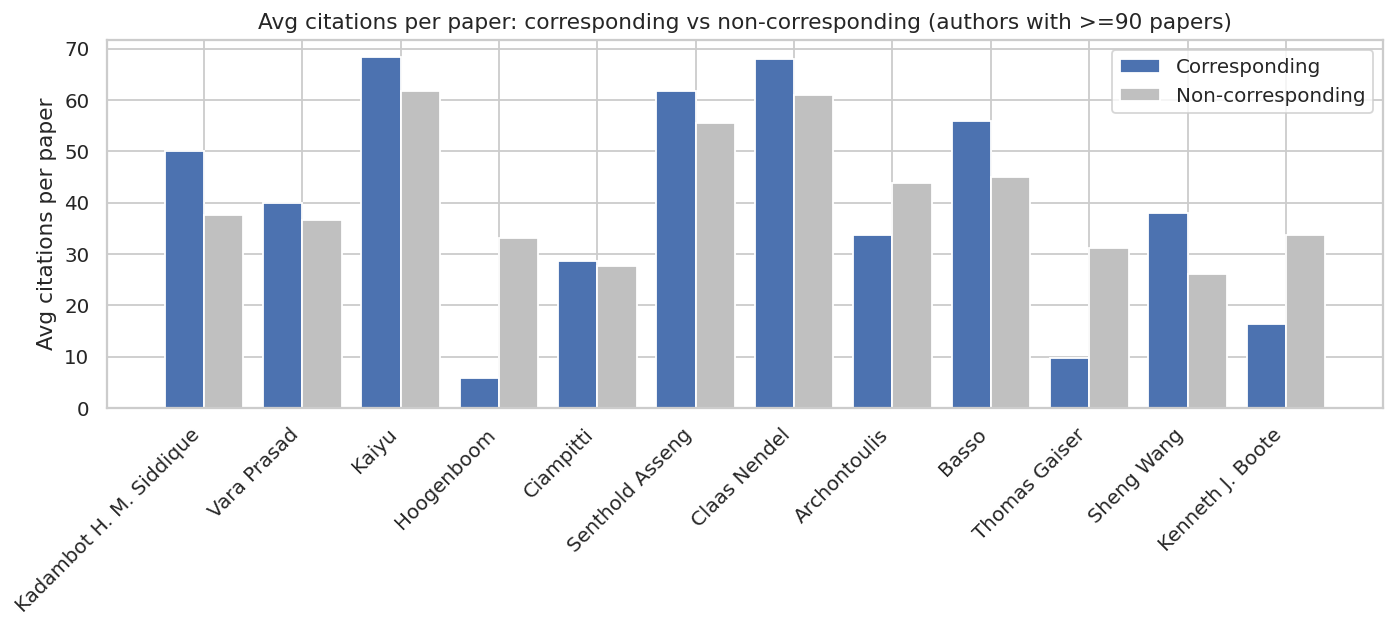

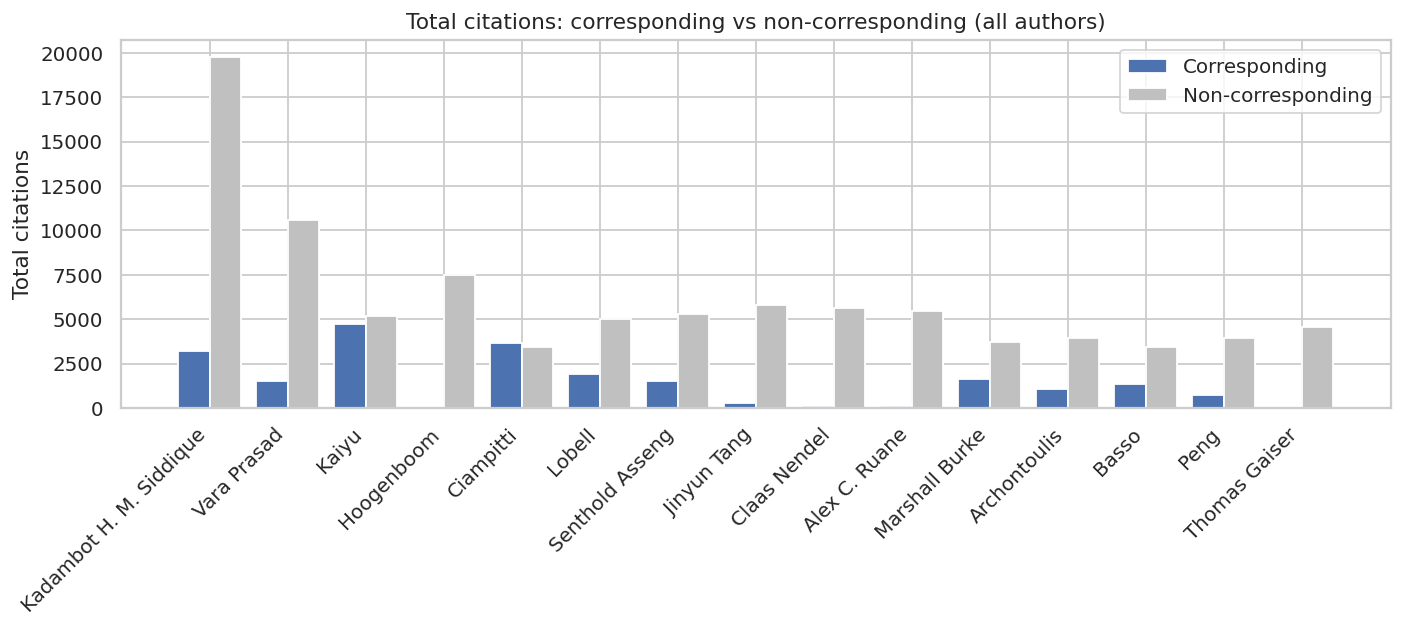

In [229]:
# Compare corresponding vs non-corresponding citations by author (avg and total)
df_corr = filtered_all_df_corr.copy()
df_non = filtered_all_df[~filtered_all_df["is_corresponding_author"]].copy()

# Dynamic threshold for avg-citation comparison only: mean papers per author, rounded up + small buffer
papers_per_author = filtered_all_df.groupby("queried_author").size()
mean_papers = papers_per_author.mean()
min_papers_avg = int(np.ceil(mean_papers / 5.0) * 5)

valid_authors_avg = papers_per_author[papers_per_author >= min_papers_avg].index

def _summarize(df):
    return (
        df.groupby("queried_author", as_index=False)
        .agg(
            avg_citations=("total_citations", "mean"),
            total_citations=("total_citations", "sum"),
        )
    )

# For avg citations: apply threshold
corr_stats_avg = _summarize(df_corr[df_corr["queried_author"].isin(valid_authors_avg)]).rename(
    columns={
        "avg_citations": "avg_corr",
        "total_citations": "total_corr",
    }
)
non_stats_avg = _summarize(df_non[df_non["queried_author"].isin(valid_authors_avg)]).rename(
    columns={
        "avg_citations": "avg_non",
        "total_citations": "total_non",
    }
)
compare_avg = corr_stats_avg.merge(non_stats_avg, on="queried_author", how="outer").fillna(0)
compare_avg["total_all"] = compare_avg["total_corr"] + compare_avg["total_non"]
compare_avg = compare_avg.sort_values("total_all", ascending=False).head(15)

# For total citations: no threshold
corr_stats_total = _summarize(df_corr).rename(
    columns={
        "avg_citations": "avg_corr",
        "total_citations": "total_corr",
    }
)
non_stats_total = _summarize(df_non).rename(
    columns={
        "avg_citations": "avg_non",
        "total_citations": "total_non",
    }
)
compare_total = corr_stats_total.merge(non_stats_total, on="queried_author", how="outer").fillna(0)
compare_total["total_all"] = compare_total["total_corr"] + compare_total["total_non"]
compare_total = compare_total.sort_values("total_all", ascending=False).head(15)

bar_w = 0.4
color_corr = "#4C72B0"
color_non = "#C0C0C0"

# ---- Avg citations per paper (thresholded) ----
authors_avg = compare_avg["queried_author"].tolist()
x_avg = np.arange(len(authors_avg))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_avg - bar_w / 2, compare_avg["avg_corr"], width=bar_w, label="Corresponding", color=color_corr)
ax.bar(x_avg + bar_w / 2, compare_avg["avg_non"], width=bar_w, label="Non-corresponding", color=color_non)
ax.set_title(f"Avg citations per paper: corresponding vs non-corresponding (authors with >={min_papers_avg} papers)")
ax.set_ylabel("Avg citations per paper")
ax.set_xticks(x_avg)
ax.set_xticklabels(authors_avg, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

# ---- Total citations (all authors, no threshold) ----
authors_total = compare_total["queried_author"].tolist()
x_total = np.arange(len(authors_total))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_total - bar_w / 2, compare_total["total_corr"], width=bar_w, label="Corresponding", color=color_corr)
ax.bar(x_total + bar_w / 2, compare_total["total_non"], width=bar_w, label="Non-corresponding", color=color_non)
ax.set_title("Total citations: corresponding vs non-corresponding (all authors)")
ax.set_ylabel("Total citations")
ax.set_xticks(x_total)
ax.set_xticklabels(authors_total, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

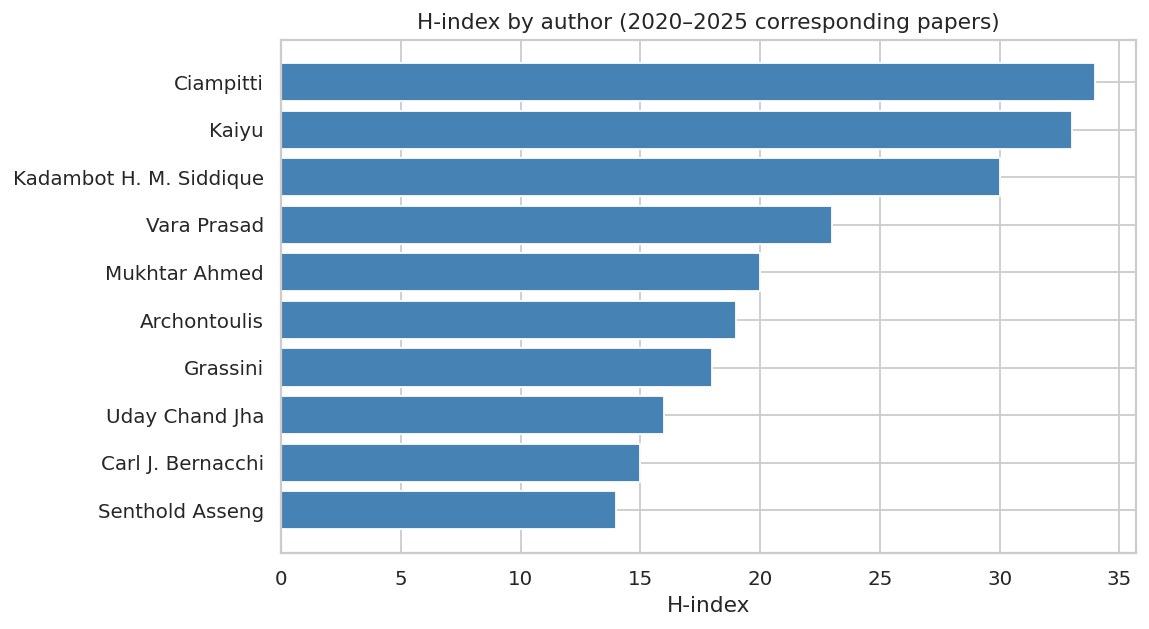

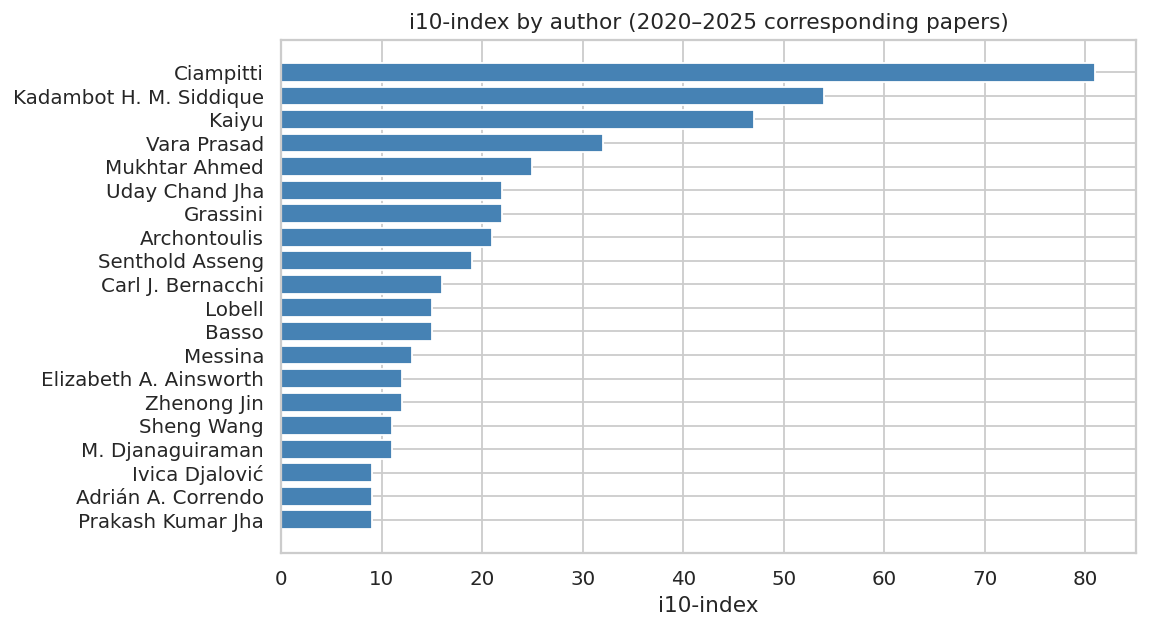

In [230]:
# Plots for metrics_df: H-index and i10-index by author
metrics_h_all = (
    metrics_all_df.dropna(subset=["h_index"])
    .sort_values("h_index", ascending=True)
    .tail(10)
)

plt.figure(figsize=(9, 5))
plt.barh(metrics_h_all["queried_author"], metrics_h_all["h_index"], color="steelblue")
plt.xlabel("H-index")
plt.title("H-index by author (2020–2025 corresponding papers)")
plt.tight_layout()
plt.show()

metrics_i10_all = (
    metrics_all_df.dropna(subset=["i10_index"])
    .sort_values("i10_index", ascending=True)
    .tail(20)
)

plt.figure(figsize=(9, 5))
plt.barh(metrics_i10_all["queried_author"], metrics_i10_all["i10_index"], color="steelblue")
plt.xlabel("i10-index")
plt.title("i10-index by author (2020–2025 corresponding papers)")
plt.tight_layout()
plt.show()

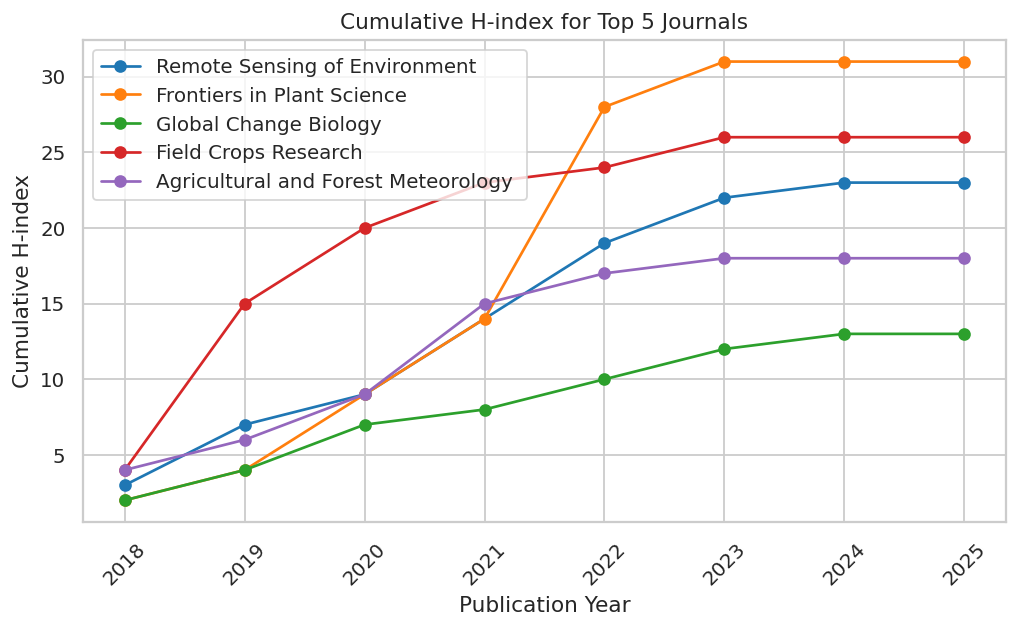

In [231]:
df = filtered_all_df_corr.sort_values('publication_year')
top_journals = df.groupby('journal_display_name')['total_citations'].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(8,5))
for journal in top_journals:
    df_journal = df[df['journal_display_name'] == journal]
    years, h, mean_cit, median_cit = cumulative_metrics(df_journal)
    plt.plot(years, h, marker='o', label=f'{journal} ')

plt.xlabel('Publication Year')
plt.ylabel('Cumulative H-index')
plt.title('Cumulative H-index for Top 5 Journals')
plt.xticks(years, rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

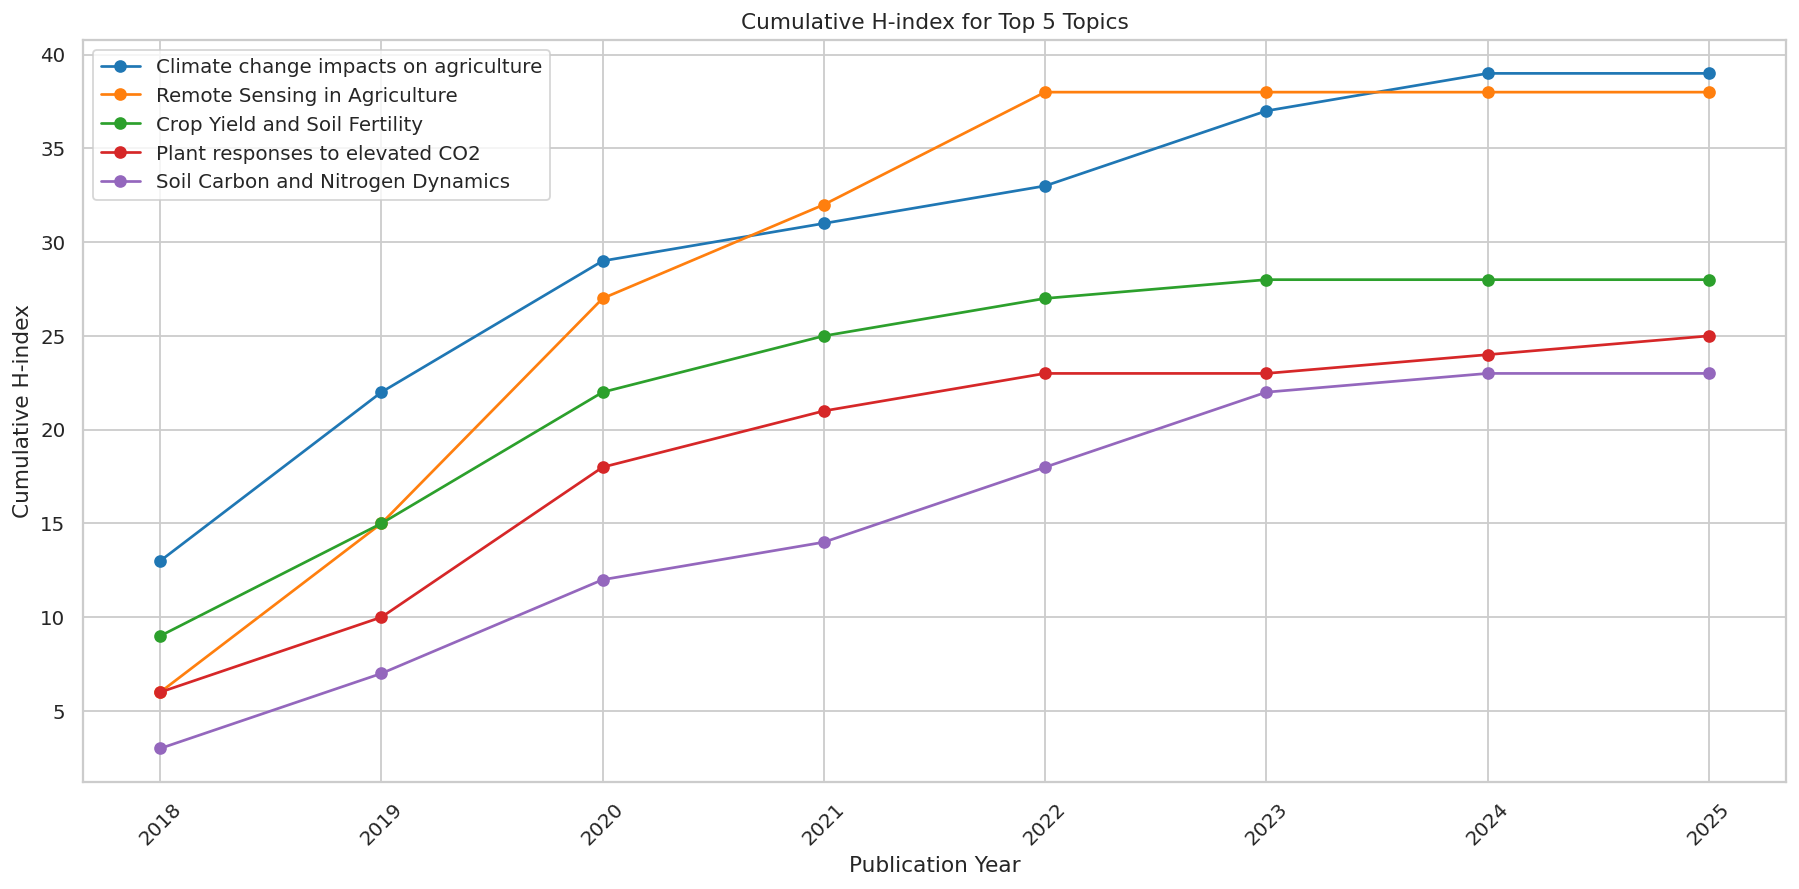

In [232]:
# --- Top 10 topics by total citations ---
top_topics = df.groupby('primary_topic')['total_citations'].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(14,7))
for topic in top_topics:
    df_topic = df[df['primary_topic'] == topic]
    years, h, mean_cit, median_cit = cumulative_metrics(df_topic)
    plt.plot(years, h, marker='o', label=f'{topic}')

plt.xlabel('Publication Year')
plt.ylabel('Cumulative H-index')
plt.title('Cumulative H-index for Top 5 Topics')
plt.xticks(years, rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
#CoAuthors Analysis

In [233]:
# # ── Papers per Target_author author — total & yearly breakdown ─────────────────────
# Coauthor_counts = (
#      filtered_coauthors_df
#     .groupby("queried_author")
#     .agg(
#         total_papers=("article_id", "count"),
#         avg_citations=("total_citations", "mean"),
#         corresponding=("is_corresponding_author", "sum"),
#     )
#     .sort_values("total_papers", ascending=True)
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(Coauthor_counts["queried_author"], Coauthor_counts["total_papers"],
#                color="steelblue", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=9)
# ax.set_xlabel("Number of papers (2020–2025)")
# ax.set_title("Number of papers by retreived authors (with duplicates)")
# plt.tight_layout()
# plt.show()
# Coauthor_counts.sort_values('corresponding', ascending=False)


In [234]:
# # ── Avg citations by Target author  ──
# avg_cit_by_author = (
#     filtered_coauthors_dedup.assign(total_citations=lambda d: d["total_citations"].fillna(0))
#     .groupby("queried_author")["total_citations"]
#     .mean()
#     .sort_values(ascending=True)
#     .round(2)
#  )

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(avg_cit_by_author.index, avg_cit_by_author.values,
#                color="steelblue", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=9)
# ax.set_title("Avg citations without duplicates")
# plt.tight_layout()
# plt.show()

In [235]:
# # ── Target-author time analysis (journals of interest, deduped) ────────────────
# df_ca = filtered_coauthors_dedup.copy()
# CURRENT_YEAR = 2026

# # ---- Citations received per calendar year (total + average) ----
# cit_year_cols = [c for c in df_ca.columns if c.startswith("citations_year_")]
# melted_ca = (
#     df_ca.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
#     .melt(id_vars=["article_id", "queried_author", "publication_year"],
#           value_vars=cit_year_cols,
#           var_name="cit_col", value_name="citations")
# )
# melted_ca["offset"] = melted_ca["cit_col"].str.extract(r"(\d+)$").astype(int)
# melted_ca["calendar_year"] = melted_ca["publication_year"].astype(int) + melted_ca["offset"]
# melted_ca["citations"] = melted_ca["citations"].fillna(0)
# melted_ca = melted_ca[
#     (melted_ca["calendar_year"] >= 2020)
#     & (melted_ca["calendar_year"] <= CURRENT_YEAR - 1)
#  ]

# # ---- Citations per year by author (avg per paper) ----
# top_authors = (
#     df_ca.groupby("queried_author")["article_id"]
#     .count()
#     .sort_values(ascending=False)
#     .head(8)
#     .index.tolist()
#  )
# author_year_avg = (
#     melted_ca[melted_ca["queried_author"].isin(top_authors)]
#     .groupby(["queried_author", "calendar_year"])
#     .agg(avg_cit=("citations", "mean"))
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(10, 4))
# for author, grp in author_year_avg.groupby("queried_author"):
#     grp = grp.sort_values("calendar_year")
#     ax.plot(grp["calendar_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)
# ax.set_title("Average citations received per year accumulated from all papers")
# ax.set_ylabel("Avg citations per paper")
# ax.set_xticks(sorted(author_year_avg["calendar_year"].unique()))
# ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# plt.tight_layout()
# plt.show()

In [236]:
# # ── Target-author time analysis (journals of interest, deduped) ────────────────
# df_ca = filtered_coauthors_dedup.copy()
# CURRENT_YEAR = 2026

# # ---- Citations received per calendar year (total + average) ----
# cit_year_cols = [c for c in df_ca.columns if c.startswith("citations_year_")]
# melted_ca = (
#     df_ca.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
#     .melt(id_vars=["article_id", "queried_author", "publication_year"],
#           value_vars=cit_year_cols,
#           var_name="cit_col", value_name="citations")
# )
# melted_ca["offset"] = melted_ca["cit_col"].str.extract(r"(\d+)$").astype(int)
# melted_ca["calendar_year"] = melted_ca["publication_year"].astype(int) + melted_ca["offset"]
# melted_ca["citations"] = melted_ca["citations"].fillna(0)
# melted_ca = melted_ca[
#     (melted_ca["calendar_year"] >= 2020)
#     & (melted_ca["calendar_year"] <= CURRENT_YEAR - 1)
#  ]

# # ---- Citations per year by author (avg per paper) ----
# top_authors = (
#     df_ca.groupby("queried_author")["article_id"]
#     .count()
#     .sort_values(ascending=False)
#     .head(15)
#     .index.tolist()
#  )
# author_year_avg = (
#     melted_ca[melted_ca["queried_author"].isin(top_authors)]
#     .groupby(["queried_author", "calendar_year"])
#     .agg(avg_cit=("citations", "mean"))
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(10, 4))
# for author, grp in author_year_avg.groupby("queried_author"):
#     grp = grp.sort_values("calendar_year")
#     ax.plot(grp["calendar_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)
# ax.set_title("avg citations received in the calendar year from all papers")
# # ax.set_xlabel("Calendar year")
# ax.set_ylabel("Avg citations per paper")
# ax.set_xticks(sorted(author_year_avg["calendar_year"].unique()))
# ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# plt.tight_layout()
# plt.show()


In [237]:
# # ---- Same-year citations only (citations_year_0), per author ----
# df_ca = filtered_coauthors_dedup.copy()

# top_authors = (
#     df_ca.groupby("queried_author")["article_id"]
#     .count()
#     .sort_values(ascending=False)
#     .head(10)
#     .index.tolist()
# )

# same_year = (
#     df_ca[df_ca["queried_author"].isin(top_authors)]
#     .dropna(subset=["publication_year"])
#     .assign(cit_same_year=lambda d: d.get("citations_year_0", 0).fillna(0))
# )

# per_year = (
#     same_year.groupby(["queried_author", "publication_year"])
#     .agg(
#         total_cit=("cit_same_year", "sum"),
#         avg_cit=("cit_same_year", "mean"),
#         n_papers=("article_id", "count"),
#     )
#     .reset_index()
# )

# fig, axes = plt.subplots( figsize=(20, 10))



# # Right: average citations per paper in publication year
# for author, grp in per_year.groupby("queried_author"):
#     grp = grp.sort_values("publication_year")
#     axes.plot(grp["publication_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)

# axes.set_title("Average citations received in publication year")
# axes.set_xlabel("Publication year")
# axes.set_ylabel("Avg citations in publication year")
# axes.set_xticks(sorted(per_year["publication_year"].unique()))

# axes.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=16)
# plt.tight_layout()
# plt.show()

In [238]:


# # ---- Corresponding vs non-corresponding papers per year by author ----
# top_authors = (
#     df_ca.groupby("queried_author")["article_id"]
#     .count()
#     .sort_values(ascending=False)
#     .head(8)
#     .index.tolist()
# )

# corr_year_author = (
#     df_ca[df_ca["queried_author"].isin(top_authors)]
#     .dropna(subset=["publication_year"])
#     .groupby(["queried_author", "publication_year", "is_corresponding_author"])
#     .size()
#     .unstack(fill_value=0)
#     .rename(columns={True: "Corresponding", False: "Non-corresponding"})
# )

# n_authors = len(top_authors)
# ncols = 4
# nrows = int(np.ceil(n_authors / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
# axes_flat = axes.flatten()

# for i, author in enumerate(top_authors):
#     ax = axes_flat[i]
#     data = corr_year_author.loc[author].sort_index()
#     data.plot(kind="bar", stacked=False, ax=ax, color=["#4C72B0", "#C0C0C0"], edgecolor="white", legend=False)
#     ax.set_title(author)
#     ax.set_xlabel("Year")
#     ax.set_ylabel("Papers")
#     ax.tick_params(axis="x", rotation=0)

# for j in range(i + 1, len(axes_flat)):
#     axes_flat[j].set_visible(False)

# fig.suptitle("Target authors: corresponding vs non-corresponding papers per year (top 8)")
# handles, labels = axes_flat[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 0.98), fontsize=8, title="Role")
# plt.tight_layout()
# plt.show()

In [239]:
# # ---- Topic trends over time (configurable level) ----
# topic_col = TOPIC_COL
# top_levels = (
#     df_ca.dropna(subset=[topic_col])
#     .groupby(topic_col)["article_id"].count()
#     .nlargest(5).index.tolist()
# )

# topic_year = (
#     df_ca.dropna(subset=[topic_col, "publication_year"])
#     .loc[lambda d: d[topic_col].isin(top_levels)]
#     .groupby(["publication_year", topic_col])
#     .size()
#     .reset_index(name="n")
# )
# total_per_year = (
#     df_ca.dropna(subset=["publication_year"])
#     .groupby("publication_year")["article_id"].count()
#     .rename("total")
# )
# topic_year = topic_year.merge(total_per_year.reset_index(), on="publication_year")
# topic_year["pct"] = (topic_year["n"] / topic_year["total"] * 100).round(1)

# fig, ax = plt.subplots(figsize=(10, 4))
# for level, grp in topic_year.groupby(topic_col):
#     grp = grp.sort_values("publication_year")
#     ax.plot(grp["publication_year"], grp["pct"], marker="o", linewidth=2, label=level)
# ax.set_title(f"Most common {TOPIC_LEVEL_LABEL}s")
# ax.set_ylabel("% of papers")
# ax.set_xticks(sorted(topic_year["publication_year"].unique()))
# ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
# ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# plt.tight_layout()
# plt.show()

In [240]:
# # Interactive table: dominant topic level per author per year (target authors, duplicates kept)
# try:
#     import ipywidgets as widgets
# except ImportError:
#     print("ipywidgets not installed. Run: pip install ipywidgets")
#     raise
# from IPython.display import display, clear_output

# topic_col_for_year = TOPIC_COL

# df_topic_src = (
#     filtered_coauthors_df
#     .dropna(subset=["queried_author", "publication_year", topic_col_for_year])
#     .copy()
#  )
# df_topic_src["publication_year"] = df_topic_src["publication_year"].astype(int)

# topic_year_counts = (
#     df_topic_src
#     .groupby(["queried_author", "publication_year", topic_col_for_year])
#     .size()
#     .reset_index(name="n_papers")
#  )

# dominant_by_year = (
#     topic_year_counts
#     .sort_values(
#         ["queried_author", "publication_year", "n_papers", topic_col_for_year],
#         ascending=[True, True, False, True],
#     )
#     .groupby(["queried_author", "publication_year"])
#     .head(1)
#     .rename(columns={topic_col_for_year: "dominant_topic"})
#     .reset_index(drop=True)
#  )

# authors = sorted(dominant_by_year["queried_author"].unique().tolist())
# author_widget = widgets.Combobox(
#     options=authors,
#     placeholder="Type last name",
#     description="Author:",
#     ensure_option=False,
#     continuous_update=True,
#  )
# out = widgets.Output()

# def _resolve_author(input_text: str | None):
#     text = (input_text or "").strip()
#     if not text:
#         return None, "Type an author last name to filter."
#     matches = [a for a in authors if text.lower() in a.lower()]
#     if len(matches) == 1:
#         return matches[0], None
#     exact = [a for a in matches if a.lower() == text.lower()]
#     if len(exact) == 1:
#         return exact[0], None
#     if len(matches) == 0:
#         return None, f"No author match for '{text}'."
#     return None, "Multiple matches: " + ", ".join(matches)

# def _render(_change=None):
#     with out:
#         clear_output()
#         selected, msg = _resolve_author(author_widget.value)
#         if msg:
#             print(msg)
#             return
#         view = (
#             dominant_by_year[dominant_by_year["queried_author"] == selected]
#             .sort_values("publication_year")
#             [["publication_year", "dominant_topic", "n_papers"]]
#             .reset_index(drop=True)
#         )
#         display(view)

# author_widget.observe(_render, names="value")
# display(widgets.VBox([
#     widgets.HTML(f"<b>Dominant {TOPIC_LEVEL_LABEL} per year</b>"),
#     author_widget,
#     out,
#  ]))
# _render()

In [241]:
# # Interactive chart: citations by year-of-life per author (Target authors, deduped)
# try:
#     import ipywidgets as widgets
# except ImportError:
#     print("ipywidgets not installed. Run: pip install ipywidgets")
#     raise
# from IPython.display import display, clear_output

# year_labels = ["Year 1", "Year 2", "Year 3", "Year 4"]
# year_columns = ["citations_year_0", "citations_year_1", "citations_year_2", "citations_year_3"]
# year_offsets = [1, 2, 3, 4]

# df_cit_src = (
#     filtered_coauthors_dedup
#     .dropna(subset=["queried_author", "publication_year"])
#     .copy()
#  )
# df_cit_src["publication_year"] = df_cit_src["publication_year"].astype(int)

# cit_authors = sorted(df_cit_src["queried_author"].unique().tolist())
# author_cit_widget = widgets.Combobox(
#     options=cit_authors,
#     placeholder="Type last name",
#     description="Author:",
#     ensure_option=False,
#     continuous_update=True,
#  )
# out_cit = widgets.Output()

# def _resolve_author_cit(input_text: str | None):
#     text = (input_text or "").strip()
#     if not text:
#         return None, "Type an author last name to filter."
#     matches = [a for a in cit_authors if text.lower() in a.lower()]
#     if len(matches) == 1:
#         return matches[0], None
#     exact = [a for a in matches if a.lower() == text.lower()]
#     if len(exact) == 1:
#         return exact[0], None
#     if len(matches) == 0:
#         return None, f"No author match for '{text}'."
#     return None, "Multiple matches: " + ", ".join(matches)

# def _calc_author_year_life(author_name: str):
#     df_author = df_cit_src[df_cit_src["queried_author"] == author_name]
#     rows = []
#     for label, col, offset in zip(year_labels, year_columns, year_offsets):
#         eligible = df_author[df_author["publication_year"] <= CURRENT_YEAR - offset]
#         n_papers = len(eligible)
#         avg_cit = eligible[col].fillna(0).mean() if n_papers > 0 else np.nan
#         rows.append({"year_label": label, "avg_citations": avg_cit, "n_papers": n_papers})
#     return pd.DataFrame(rows)

# def _render_cit(_change=None):
#     with out_cit:
#         clear_output()
#         selected, msg = _resolve_author_cit(author_cit_widget.value)
#         if msg:
#             print(msg)
#             return
#         data = _calc_author_year_life(selected)
#         if data["n_papers"].sum() == 0:
#             print("No eligible papers for this author.")
#             return
#         fig, ax = plt.subplots(figsize=(7, 4))
#         ax.plot(data["year_label"], data["avg_citations"], marker="o", linewidth=2, color="steelblue")
#         ax.set_title(f"{selected}: average citations by paper year-of-life")
#         ax.set_xlabel("Paper year-of-life")
#         ax.set_ylabel("Avg citations (that year only)")
#         ax.set_ylim(0, max(1, np.nanmax(data["avg_citations"]) * 1.25))
#         for x, y, n in zip(data["year_label"], data["avg_citations"], data["n_papers"]):
#             if np.isfinite(y):
#                 ax.text(x, y + 0.03, f"n={n}", ha="center", va="bottom", fontsize=8, color="dimgray")
#         plt.tight_layout()
#         plt.show()
#         display(data.assign(avg_citations=data["avg_citations"].round(2)))

# author_cit_widget.observe(_render_cit, names="value")
# display(widgets.VBox([
#     widgets.HTML("<b>Average citations by year-of-life</b>"),
#     author_cit_widget,
#     out_cit,
#  ]))
# _render_cit()

###Author citation lifecycle (interactive)
Run the cell below once, then pick an author to see average citations by paper year-of-life.

In [242]:
# # ── Ranked dot plot: papers count vs avg citations per Target_author author ─────────
# fig, ax = plt.subplots(figsize=(8, 5))
# scatter = ax.scatter(
#     Coauthor_counts["total_papers"],
#     Coauthor_counts["avg_citations"],
#     s=Coauthor_counts["corresponding"]*20 + 20,  # bubble size based on corresponding-author count
#     c=range(len(Coauthor_counts)),
#     cmap="tab10",
#     alpha=0.85,
#     edgecolors="white",
#     linewidths=0.5,
# )
# for _, row in Coauthor_counts.iterrows():
#     ax.annotate(#row["queried_author"],
#                 None, 
#                 xy=(row["total_papers"], row["avg_citations"]),
#                 xytext=(5, 3), textcoords="offset points", fontsize=8)
# ax.set_xlabel("Total papers")
# ax.set_ylabel("Avg total citations per paper")
# ax.set_title("Productivity and impact of retreived authors (bubble size = corresponding papers)")
# plt.tight_layout()
# plt.show()
# #Solo contar paper donde son crresponding

In [243]:
# specific_topic_col = TOPIC_COL

# dominant_CAtopic = (
#     df_ca.dropna(subset=["queried_author", specific_topic_col])
#     .groupby(["queried_author", specific_topic_col])
#     .size()
#     .reset_index(name="n")
#     .sort_values(["queried_author", "n"], ascending=[True, False])
#     .groupby("queried_author")
#     .head(1)
#     .reset_index(drop=True)
# )

# topic_counts = (
#     dominant_CAtopic.groupby(specific_topic_col)["queried_author"]
#     .nunique()
#     .sort_values(ascending=False)
# )
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.pie(
#     topic_counts.values,
#     labels=topic_counts.index.astype(str),
#     autopct="%1.1f%%",
#     startangle=90,
#     counterclock=False,
#     wedgeprops={"edgecolor": "white"},
#  )
# ax.set_title(f"Target authors grouped by dominant {TOPIC_LEVEL_LABEL}")
# ax.axis("equal")
# plt.tight_layout()
# plt.show()

# # fig, ax = plt.subplots(figsize=(10, 5))
# # bars = ax.barh(topic_counts.index, topic_counts.values, color="steelblue", edgecolor="white")

In [244]:
# # ── Most-published journal per Target_author author ─────────────────────────────────
# top_journal_per_author = (
#     filtered_coauthors_dedup.dropna(subset=["journal_display_name"])
#     .groupby(["queried_author", "journal_display_name"])
#     .size()
#     .reset_index(name="n_papers")
#     .sort_values("n_papers", ascending=False)
#     .groupby("queried_author")
#     .first()
#     .reset_index()
#     .rename(columns={"journal_display_name": "top_journal"})
#     [["queried_author", "top_journal", "n_papers"]]
# )

# journal_counts = (
#     top_journal_per_author.groupby("top_journal")["queried_author"]
#     .nunique()
#     .sort_values(ascending=False)
# )

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.pie(
#     journal_counts.values,
#     labels=journal_counts.index.astype(str),
#     autopct="%1.1f%%",
#     startangle=90,
#     counterclock=False,
#     wedgeprops={"edgecolor": "white"},
#  )
# ax.set_title("Target authors grouped by dominant journal")
# ax.axis("equal")
# plt.tight_layout()
# plt.show()
# # fig, ax = plt.subplots(figsize=(10, 5))
# # bars = ax.barh(
# #     top_journal_per_author["queried_author"],
# #     top_journal_per_author["n_papers"],
# #     color="steelblue", edgecolor="white"
# # )
# # ax.bar_label(bars, padding=3, fontsize=8)

# # ax.set_xlabel("Papers in top journal")
# # ax.set_title("Most-published journal per Target_author author")
# # plt.tight_layout()
# # plt.show()
# print(journal_counts)

# top_journal_per_author


In [245]:
# # ── Avg citations by Target author (duplicates included, journals of interest) ──
# avg_cit_by_author = (
#     filtered_coauthors_df.assign(total_citations=lambda d: d["total_citations"].fillna(0))
#     .groupby("queried_author")["total_citations"]
#     .mean()
#     .sort_values(ascending=True)
#     .round(2)
#  )

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(avg_cit_by_author.index, avg_cit_by_author.values,
#                color="steelblue", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=9)
# ax.set_xlabel("Avg citations per paper (duplicates included)")
# ax.set_title("Avg citations per Target author")
# plt.tight_layout()
# plt.show()


-----
#Topic Analysis

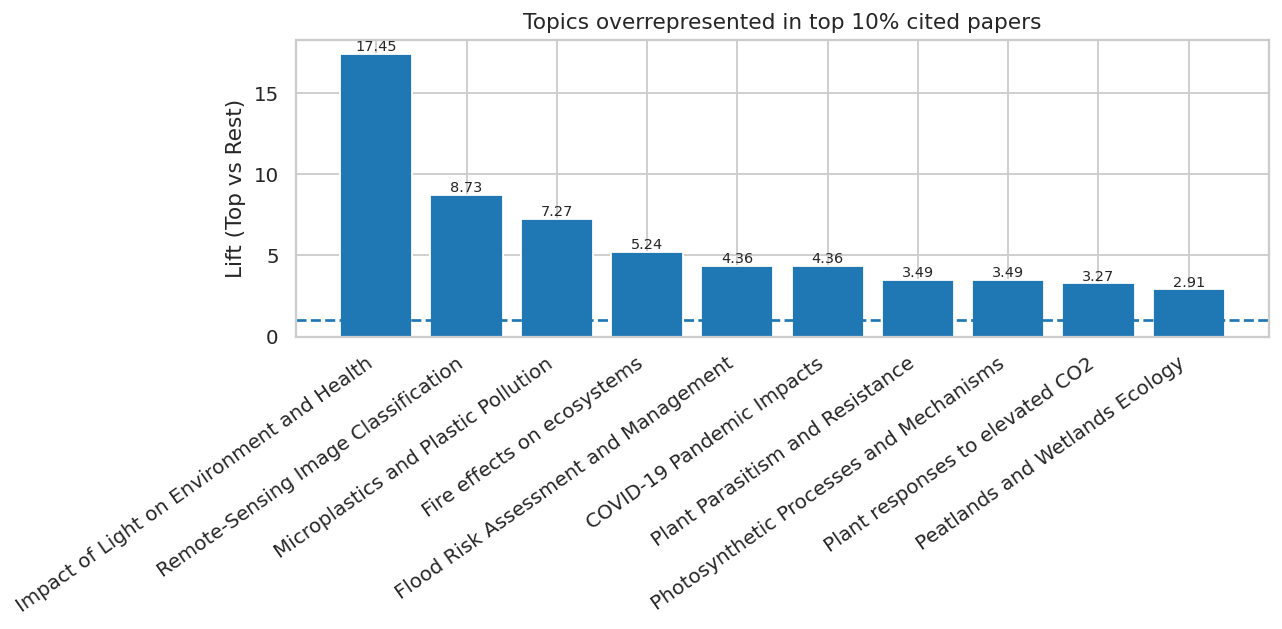

,topic,top_pct,rest_pct,lift,p_value,top_count,rest_count
42,Impact of Light on Environment and Health,1.55,0.09,17.45,4.995e-07,6,3
76,Remote-Sensing Image Classification,1.04,0.12,8.73,1.809e-03,4,4
51,Microplastics and Plastic Pollution,1.30,0.18,7.27,8.103e-04,5,6
27,Fire effects on ecosystems,0.78,0.15,5.24,5.062e-02,3,5
28,Flood Risk Assessment and Management,0.52,0.12,4.36,2.349e-01,2,4
18,COVID-19 Pandemic Impacts,0.52,0.12,4.36,2.349e-01,2,4
64,Plant Parasitism and Resistance,0.52,0.15,3.49,3.311e-01,2,5
60,Photosynthetic Processes and Mechanisms,0.52,0.15,3.49,3.311e-01,2,5
69,Plant responses to elevated CO2,8.55,2.61,3.27,1.042e-09,33,88
58,Peatlands and Wetlands Ecology,0.52,0.18,2.91,4.299e-01,2,6


In [246]:
# ── PARAMETERS ────────────────────────────────────────────────────────────────
TOP_PERCENTILE = 0.10   # top 10% most cited papers
MIN_COUNT = 5           # minimum papers per topic
TOP_K_PLOT = 10         # number of topics to display

# ── PREPARE DATA ──────────────────────────────────────────────────────────────
df = filtered_all_df.copy()

# Remove missing
df = df.dropna(subset=[TOPIC_COL, "total_citations"])

# Filter low-frequency topics
topic_counts = df[TOPIC_COL].value_counts()
valid_topics = topic_counts[topic_counts >= MIN_COUNT].index
df = df[df[TOPIC_COL].isin(valid_topics)]

# ── DEFINE TOP PAPERS (percentile-based) ──────────────────────────────────────
threshold = df["total_citations"].quantile(1 - TOP_PERCENTILE)
top_df = df[df["total_citations"] >= threshold]
rest_df = df[df["total_citations"] < threshold]

# ── DISTRIBUTIONS ─────────────────────────────────────────────────────────────
top_counts  = top_df[TOPIC_COL].value_counts()
rest_counts = rest_df[TOPIC_COL].value_counts()

all_topics = sorted(set(top_counts.index).union(rest_counts.index))

top_pct = (top_counts.reindex(all_topics, fill_value=0) / len(top_df)) * 100
rest_pct = (rest_counts.reindex(all_topics, fill_value=0) / len(rest_df)) * 100

# ── LIFT (overrepresentation) ─────────────────────────────────────────────────
lift = (top_pct / rest_pct).replace([np.inf, -np.inf], np.nan)

# ── STATISTICAL SIGNIFICANCE (chi-square) ─────────────────────────────────────
results = []

for topic in all_topics:
    a = top_counts.get(topic, 0)
    b = len(top_df) - a
    c = rest_counts.get(topic, 0)
    d = len(rest_df) - c

    table = [[a, b], [c, d]]

    try:
        chi2, p, _, _ = chi2_contingency(table)
    except:
        p = np.nan

    results.append({
        "topic": topic,
        "top_pct": top_pct[topic],
        "rest_pct": rest_pct[topic],
        "lift": lift[topic],
        "p_value": p,
        "top_count": a,
        "rest_count": c
    })

results_df = pd.DataFrame(results)

# ── CLEAN + SORT ──────────────────────────────────────────────────────────────
results_df = results_df.dropna(subset=["lift"])
results_df = results_df.sort_values("lift", ascending=False)

# Keep top K for visualization
plot_df = results_df.head(TOP_K_PLOT)

# ── PLOT: LIFT (main result) ──────────────────────────────────────────────────
plt.figure()
plt.bar(plot_df["topic"], plot_df["lift"])

# Baseline
plt.axhline(1, linestyle="--")

plt.xticks(rotation=35, ha="right")
plt.ylabel("Lift (Top vs Rest)")
plt.title(f"Topics overrepresented in top {int(TOP_PERCENTILE*100)}% cited papers")

# Annotate values
for i, v in enumerate(plot_df["lift"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# ── OPTIONAL: PRINT TABLE ─────────────────────────────────────────────────────
display(
    results_df.head(15).assign(
        top_pct=lambda x: x["top_pct"].round(2),
        rest_pct=lambda x: x["rest_pct"].round(2),
        lift=lambda x: x["lift"].round(2),
        p_value=lambda x: x["p_value"].apply(lambda v: f"{v:.3e}" if pd.notnull(v) else "nan")
    )
)

#How much more likely is this topic to appear in top 10% cited papers compared to the rest?”

##Topic Analysis: Citations vs Paper Counts
This section uses `topic_subfield` to compare topic dominance by citations received (calendar year) versus paper counts (publication year).

Most cited topic per calendar year (citations received that year):


,calendar_year,primary_topic,citations
7,2025,Climate change impacts on agriculture,1526.0
6,2024,Remote Sensing in Agriculture,1143.0
5,2023,Remote Sensing in Agriculture,946.0
4,2022,Climate change impacts on agriculture,864.0
3,2021,Climate change impacts on agriculture,656.0
8,2026,Climate change impacts on agriculture,454.0
2,2020,Climate change impacts on agriculture,381.0
1,2019,Climate change impacts on agriculture,120.0
0,2018,Remote Sensing in Agriculture,15.0


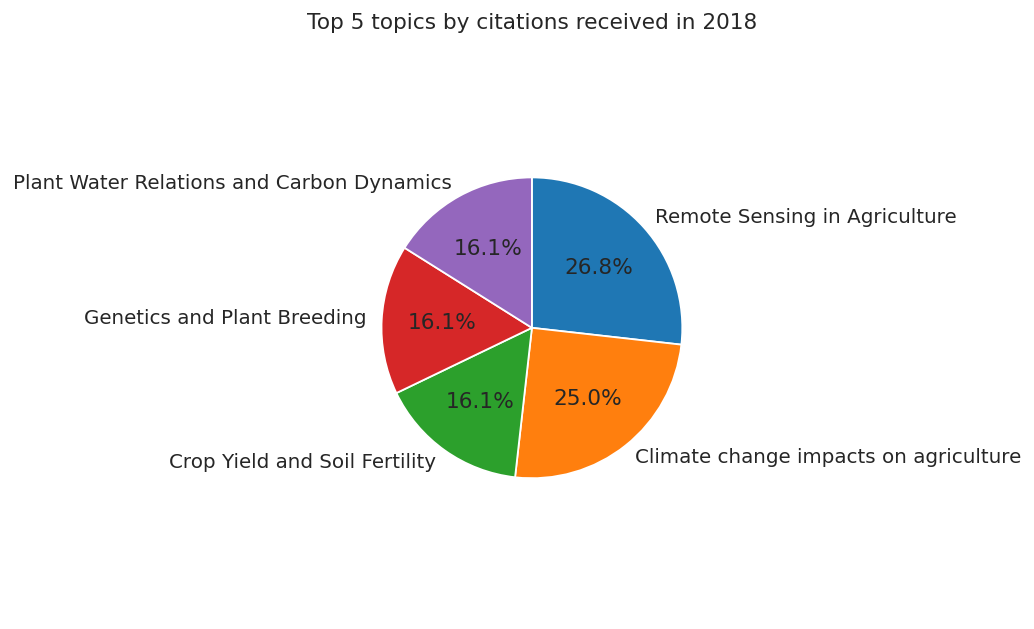

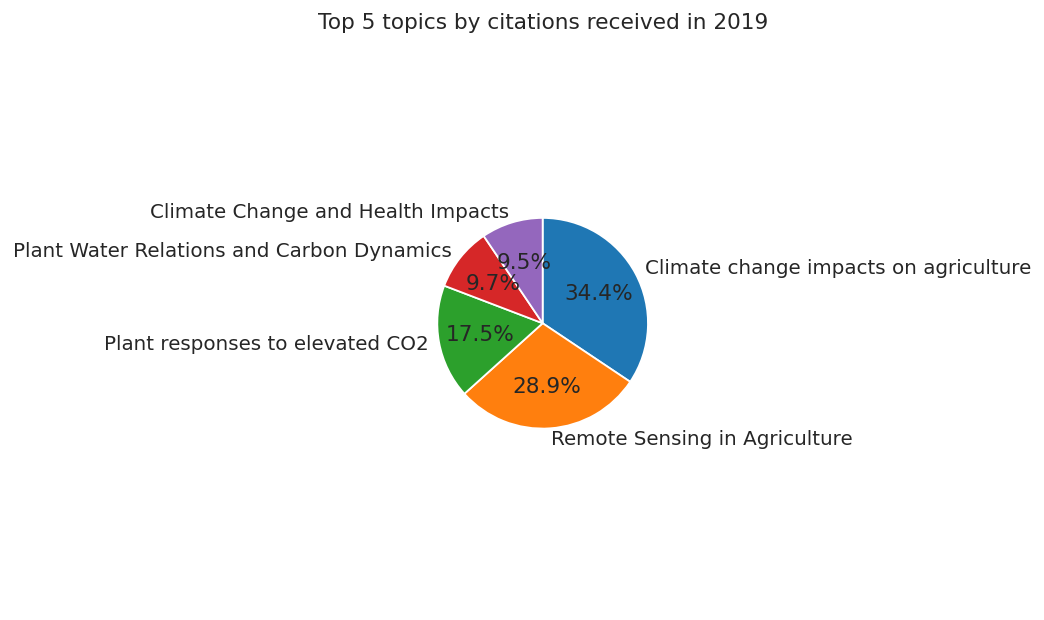

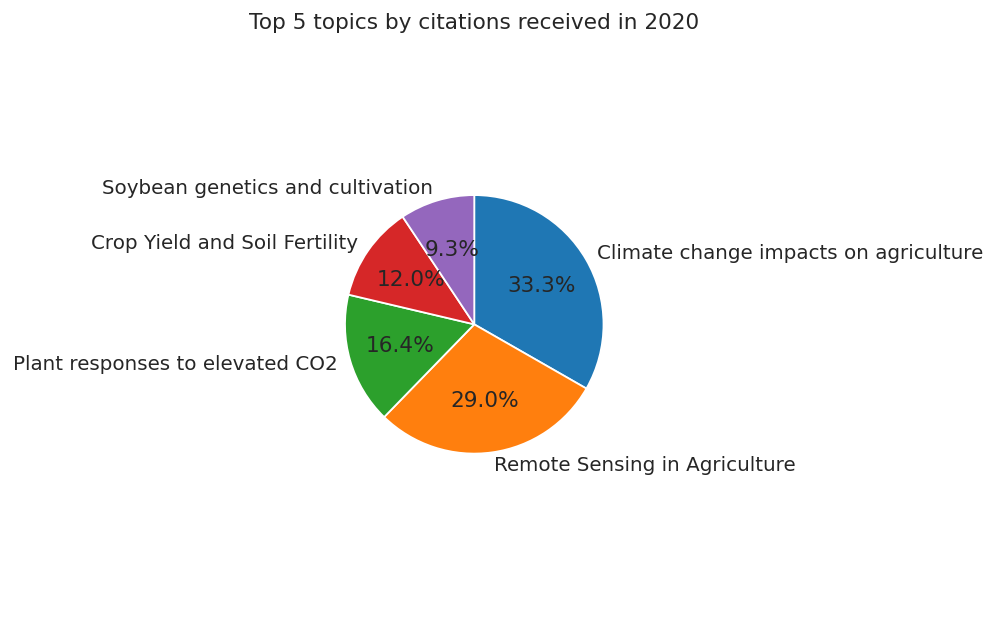

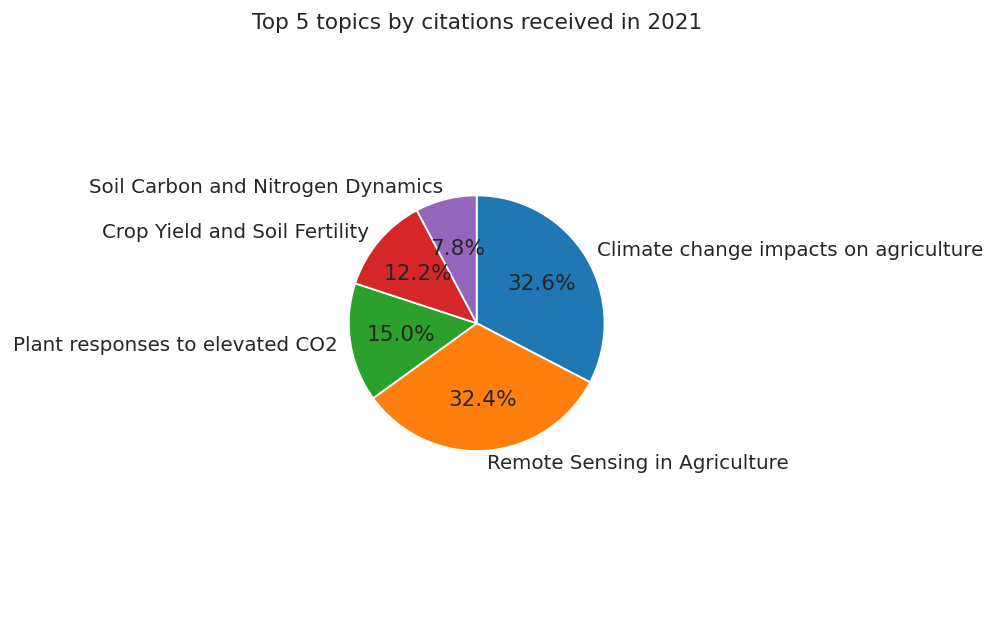

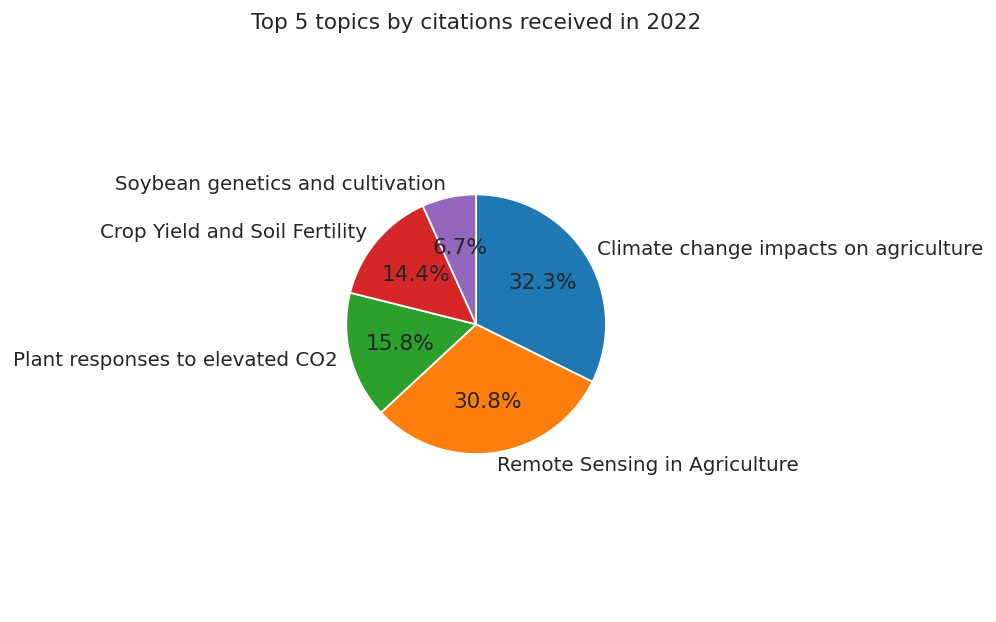

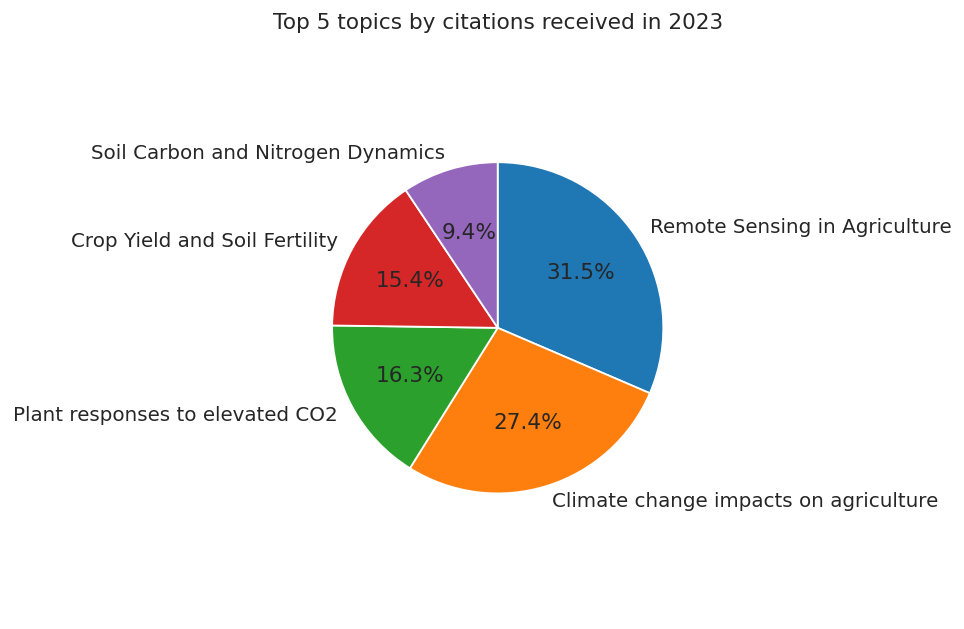

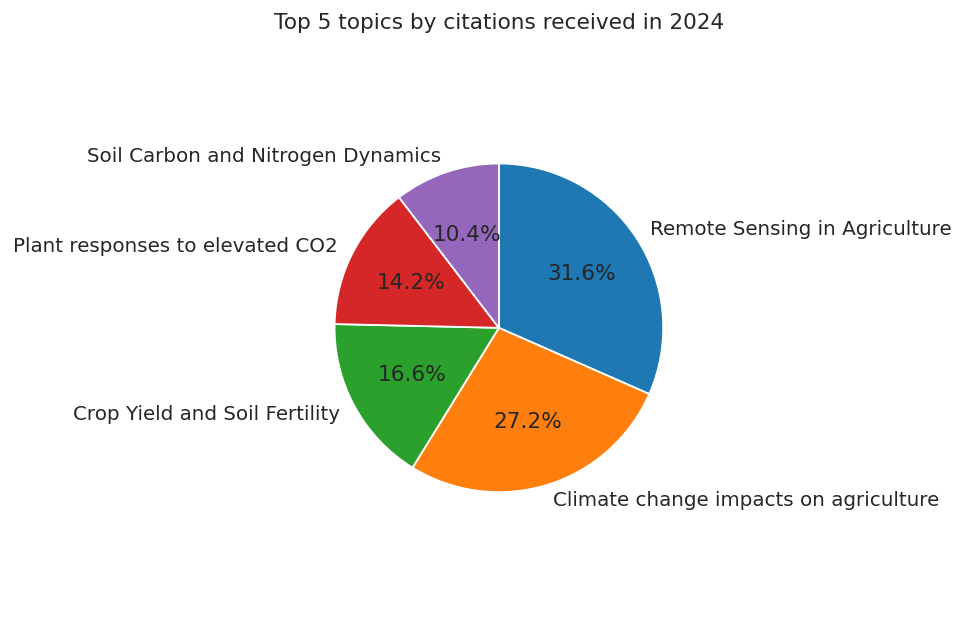

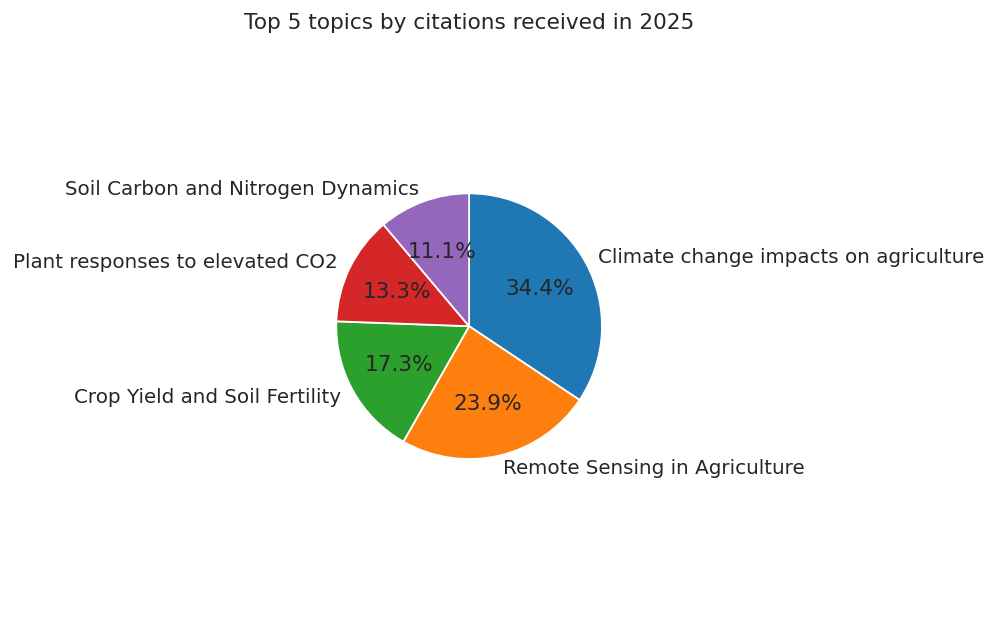

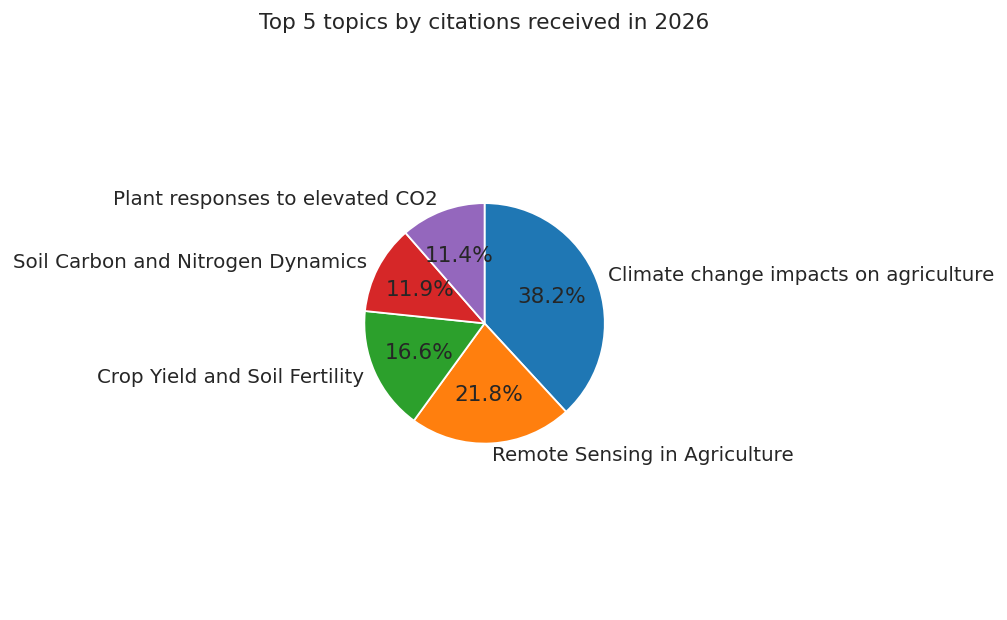

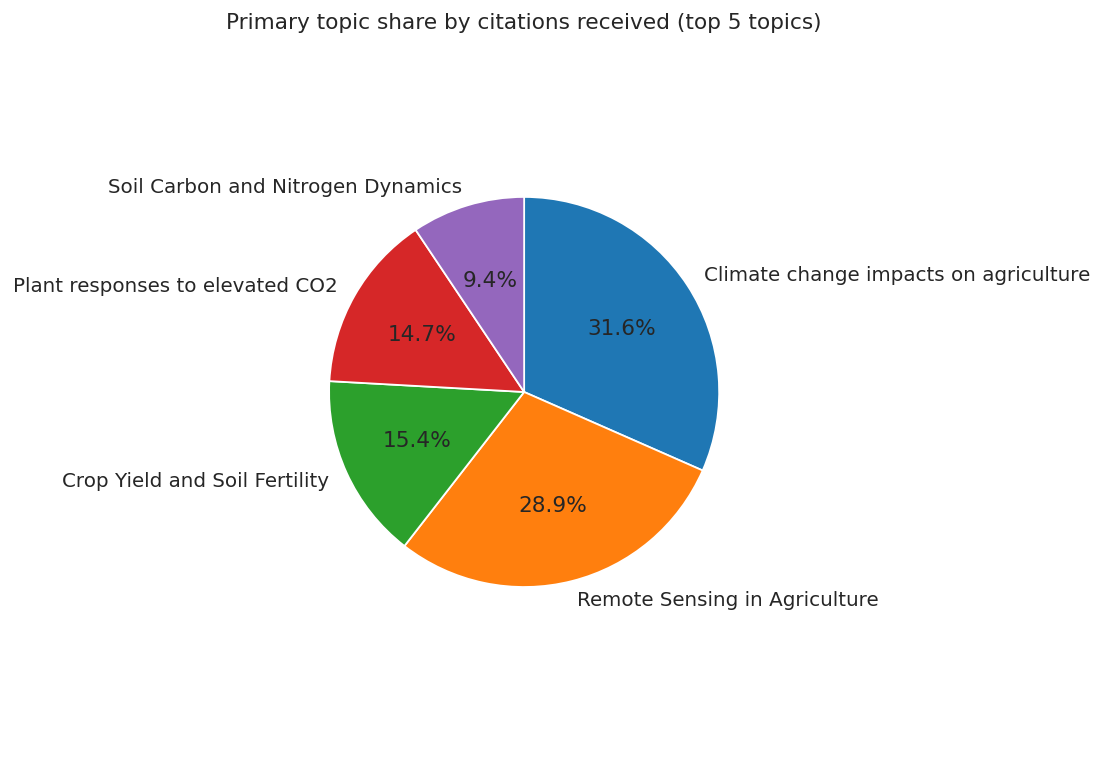

In [247]:
# Most cited topic per calendar year (citations received in that year)
topic_col = TOPIC_COL
df_topic = filtered_all_df_corr.copy()
cit_year_cols = [c for c in df_topic.columns if c.startswith("citations_year_")]
current_year = CURRENT_YEAR if "CURRENT_YEAR" in globals() else 2026

if not cit_year_cols:
    print("No citations_year_* columns found. Cannot compute calendar-year citations.")
else:
    df_cit = df_topic.dropna(subset=[topic_col, "publication_year"]).copy()
    melted = (
        df_cit[["article_id", "publication_year", topic_col] + cit_year_cols]
        .melt(
            id_vars=["article_id", "publication_year", topic_col],
            value_vars=cit_year_cols,
            var_name="cit_col",
            value_name="citations",
        )
    )
    melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
    melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
    melted["citations"] = melted["citations"].fillna(0)
    melted = melted[melted["calendar_year"] <= current_year]

    citations_by_year_topic = (
        melted.groupby(["calendar_year", topic_col])["citations"]
        .sum()
        .reset_index()
    )

    top_topic_by_year = (
        citations_by_year_topic
        .sort_values(["calendar_year", "citations", topic_col], ascending=[True, False, True])
        .groupby("calendar_year")
        .head(1)
        .reset_index(drop=True)
    )
    
    print("Most cited topic per calendar year (citations received that year):")
    display(top_topic_by_year.sort_values('citations', ascending=False))

    # Per-year top-5 citations (one pie chart per year).
    for year in sorted(citations_by_year_topic["calendar_year"].unique()):
        year_df = (
            citations_by_year_topic[citations_by_year_topic["calendar_year"] == year]
            .sort_values(["citations", topic_col], ascending=[False, True])
            .head(5)
        )
        if year_df.empty:
            continue
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.pie(
            year_df["citations"],
            labels=year_df[topic_col].astype(str),
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False,
            wedgeprops={"edgecolor": "white"},
        )
        ax.set_title(f"Top 5 topics by citations received in {year}")
        ax.axis("equal")
        plt.tight_layout()
        plt.show()

    # Overall topic share by citations (top 5 topics).
    total_citations_by_topic = (
        citations_by_year_topic.groupby(topic_col)["citations"]
        .sum()
        .sort_values(ascending=False)
    )
    top_n = 5
    pie_values = total_citations_by_topic.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(
        pie_values.values,
        labels=pie_values.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white"},
    )
    ax.set_title(f"{TOPIC_LEVEL_LABEL} share by citations received (top 5 topics)")
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

Most common subfield per publication year (paper counts):


,publication_year,primary_topic,n_papers
6,2024,Crop Yield and Soil Fertility,23
7,2025,Crop Yield and Soil Fertility,17
5,2023,Climate change impacts on agriculture,16
2,2020,Remote Sensing in Agriculture,15
4,2022,Remote Sensing in Agriculture,14
0,2018,Climate change impacts on agriculture,13
3,2021,Crop Yield and Soil Fertility,11
1,2019,Climate change impacts on agriculture,10


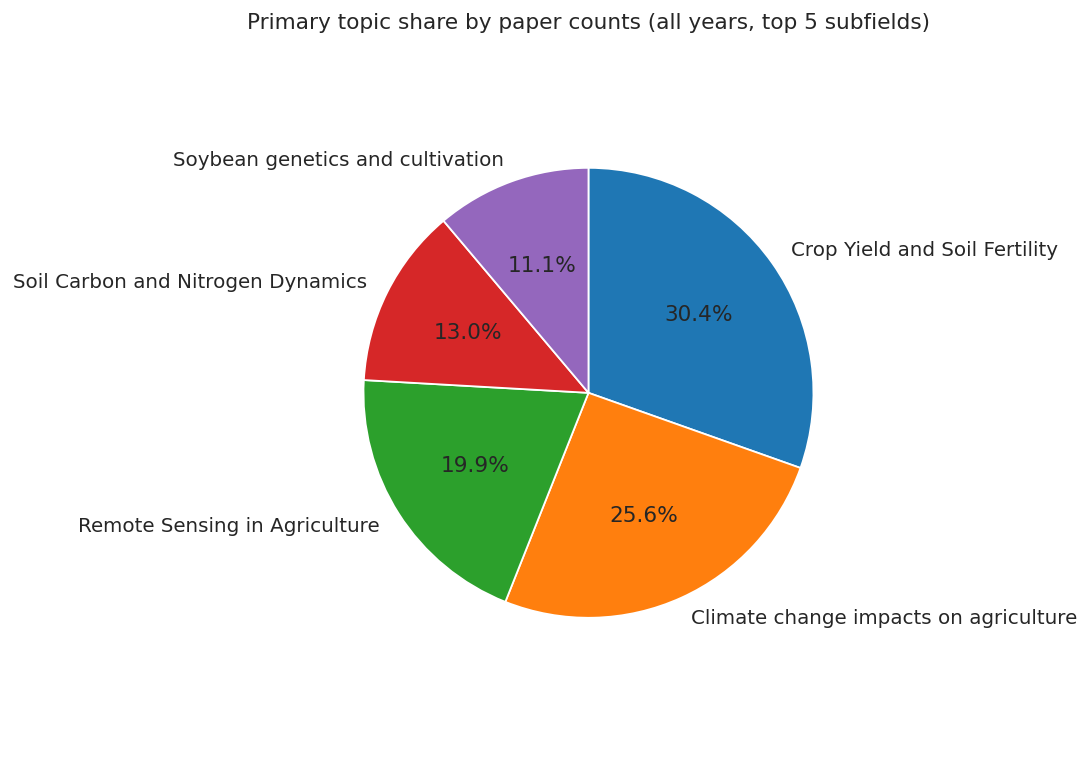

In [248]:
# Same view using paper counts (publication year)
df_counts = df_topic.dropna(subset=[topic_col, "publication_year"]).copy()
counts_by_year_topic = (
    df_counts.groupby(["publication_year", topic_col])
    .size()
    .reset_index(name="n_papers")
 )

top_topic_by_year_counts = (
    counts_by_year_topic
    .sort_values(["publication_year", "n_papers", topic_col], ascending=[True, False, True])
    .groupby("publication_year")
    .head(1)
    .reset_index(drop=True)
 )

print("Most common subfield per publication year (paper counts):")
display(top_topic_by_year_counts.sort_values('n_papers', ascending=False))

# Overall topic share by paper counts (top 5 subfields).
total_counts_by_topic = (
    counts_by_year_topic.groupby(topic_col)["n_papers"]
    .sum()
    .sort_values(ascending=False)
 )
top_n = 5
pie_values = total_counts_by_topic.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    pie_values.values,
    labels=pie_values.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title(f"{TOPIC_LEVEL_LABEL} share by paper counts (all years, top 5 subfields)")
ax.axis("equal")
plt.tight_layout()
plt.show()

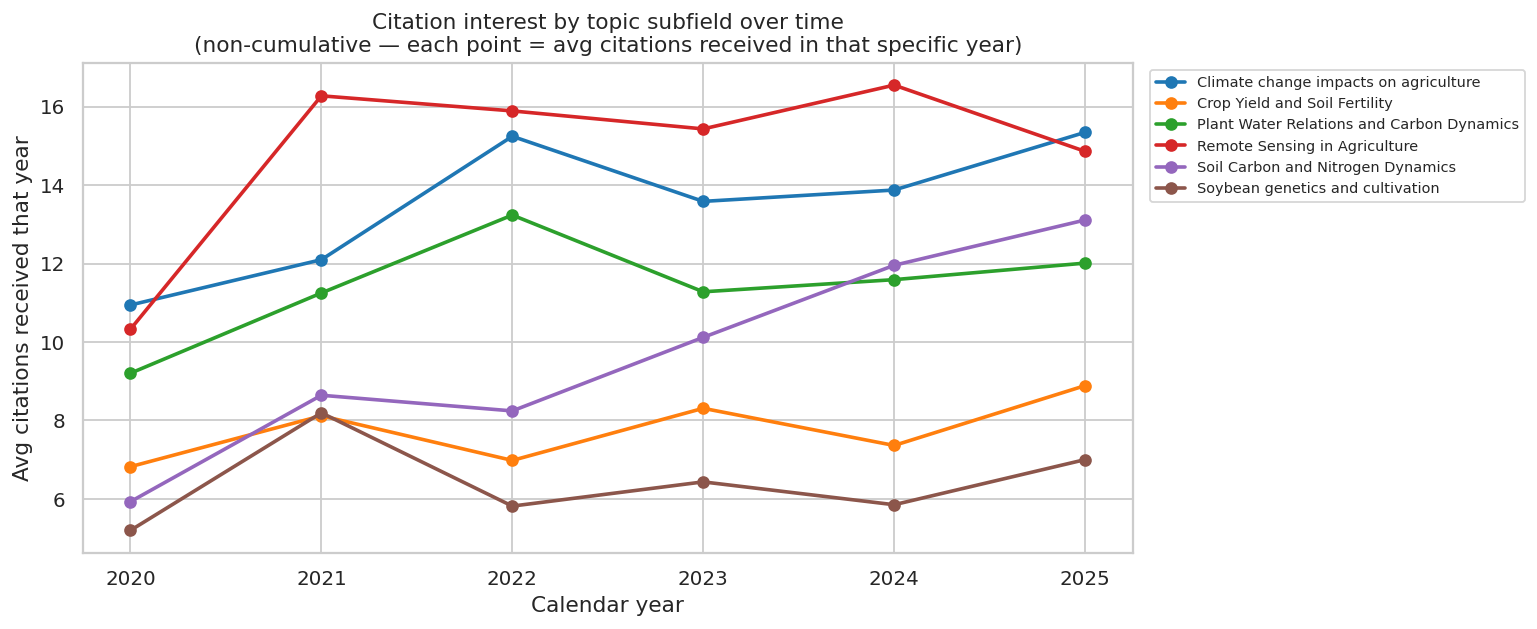

In [249]:
# ── Citation interest trend by topic subfield ─────────────────────────────────
# For each paper, citations_year_k = citations received in (publication_year + k).
# We convert offsets to actual calendar years, so every paper contributes its
# citations to the year they were received — not cumulative, purely that year.
# This lets us see whether a subfield's interest is rising or declining over time.

CURRENT_YEAR = 2026
cit_year_cols = [c for c in all_df.columns if c.startswith("citations_year_")]

top_subfields = (
    all_df.dropna(subset=["primary_topic"])
    .groupby("primary_topic")["article_id"].count()
    .nlargest(6).index.tolist()
)

df_top = (
    all_df
    .dropna(subset=["primary_topic", "publication_year"])
    .query("primary_topic in @top_subfields")
)

# Melt citation-year columns into long form, then map offset → calendar year
melted = (
    df_top[["article_id", "primary_topic", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "primary_topic", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted["offset"]        = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"]     = melted["citations"].fillna(0)

# Keep only complete past calendar years (2020–2025)
melted = melted[(melted["calendar_year"] >= 2020) & (melted["calendar_year"] <= CURRENT_YEAR - 1)]

# Average citations received that calendar year, per subfield
subfield_year_avg = (
    melted.groupby(["primary_topic", "calendar_year"])["citations"]
    .mean()
    .reset_index()
)

# ── Line chart: one line per subfield, X = calendar year ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for subfield, grp in subfield_year_avg.groupby("primary_topic"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["citations"], marker="o", linewidth=2, label=subfield)

ax.set_xlabel("Calendar year")
ax.set_ylabel("Avg citations received that year")
ax.set_title("Citation interest by topic subfield over time\n(non-cumulative — each point = avg citations received in that specific year)")
ax.set_xticks(range(2020, CURRENT_YEAR))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


---

#Journal Analysis
Where are these agronomists publishing? Which journals have the highest citation impact for this community?

###Journal citation analysis (corresponding authors, 2020-2025)

[journals:avg-total-citations] mean papers=4.52, threshold=5, kept categories=29/137


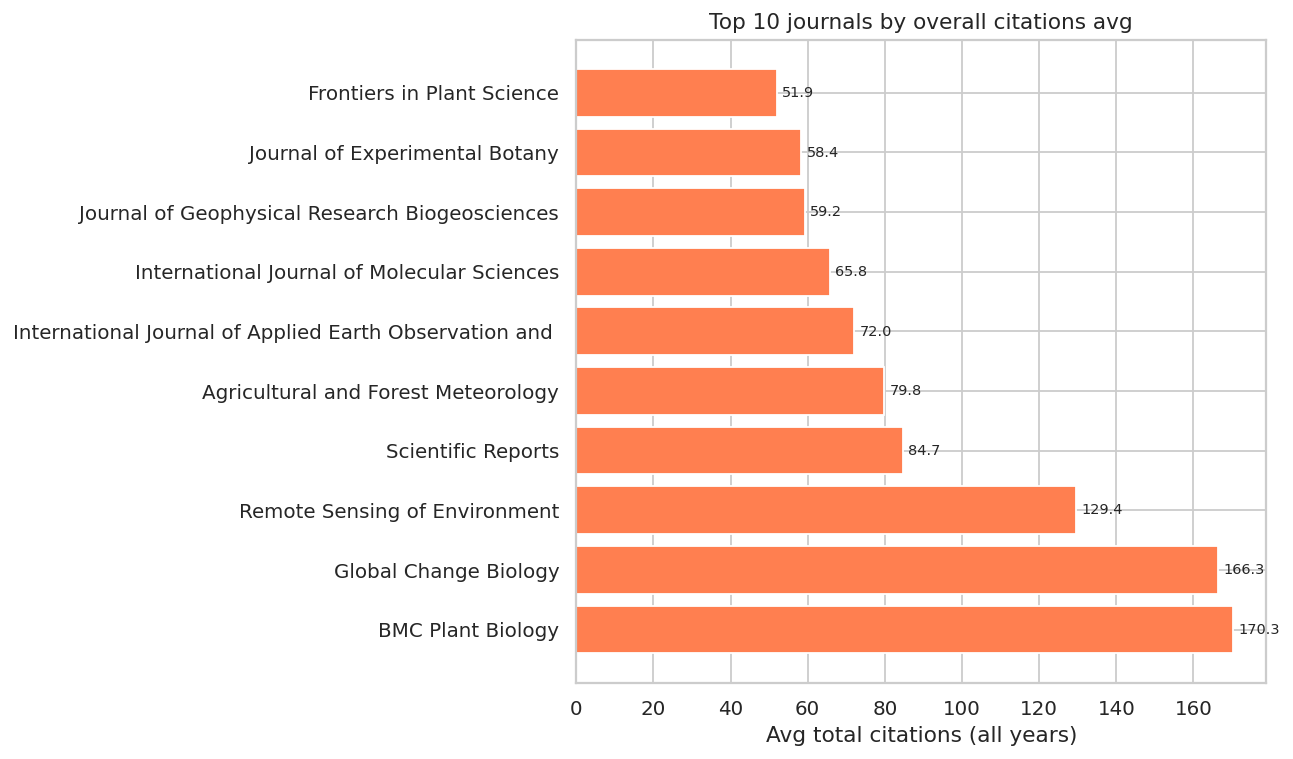

In [250]:
# ── Journal avg total citations (papers old enough) ─────────────────────────
CURRENT_YEAR = 2026
df_jnl = filtered_all_df_corr.copy()
df_jnl["age"] = CURRENT_YEAR - df_jnl["publication_year"].fillna(CURRENT_YEAR)

# Filter to papers with at least 2 years since publication
eligible = df_jnl[df_jnl["age"] >= 2].dropna(subset=["journal_display_name", "total_citations", "article_id"])
eligible, _, eligible_journals, min_papers_jnl_avg, _ = filter_categories_by_mean_plus_one(
    eligible,
    "journal_display_name",
    paper_id_col="article_id",
    label="journals:avg-total-citations",
)

jnl_avg = (
    eligible.groupby("journal_display_name")
    .agg(
        n=("article_id", "nunique"),
        avg_cit_all_years=("total_citations", "mean"),
        total_pubs_in_dataset=("article_id", "nunique"),
    )
    .sort_values("avg_cit_all_years", ascending=False)
    .head(10)
    .reset_index()
)

if jnl_avg.empty:
    print(f"No journals met threshold (>= {min_papers_jnl_avg} papers).")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        jnl_avg["journal_display_name"].str[:55],
        jnl_avg["avg_cit_all_years"],
        color="coral", edgecolor="white",
    )
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_xlabel("Avg total citations (all years)")
    ax.set_title("Top 10 journals by overall citations avg")
    plt.tight_layout()
    plt.show()

[author-journal pairs:target] mean papers=2.31, threshold=3, kept categories=38


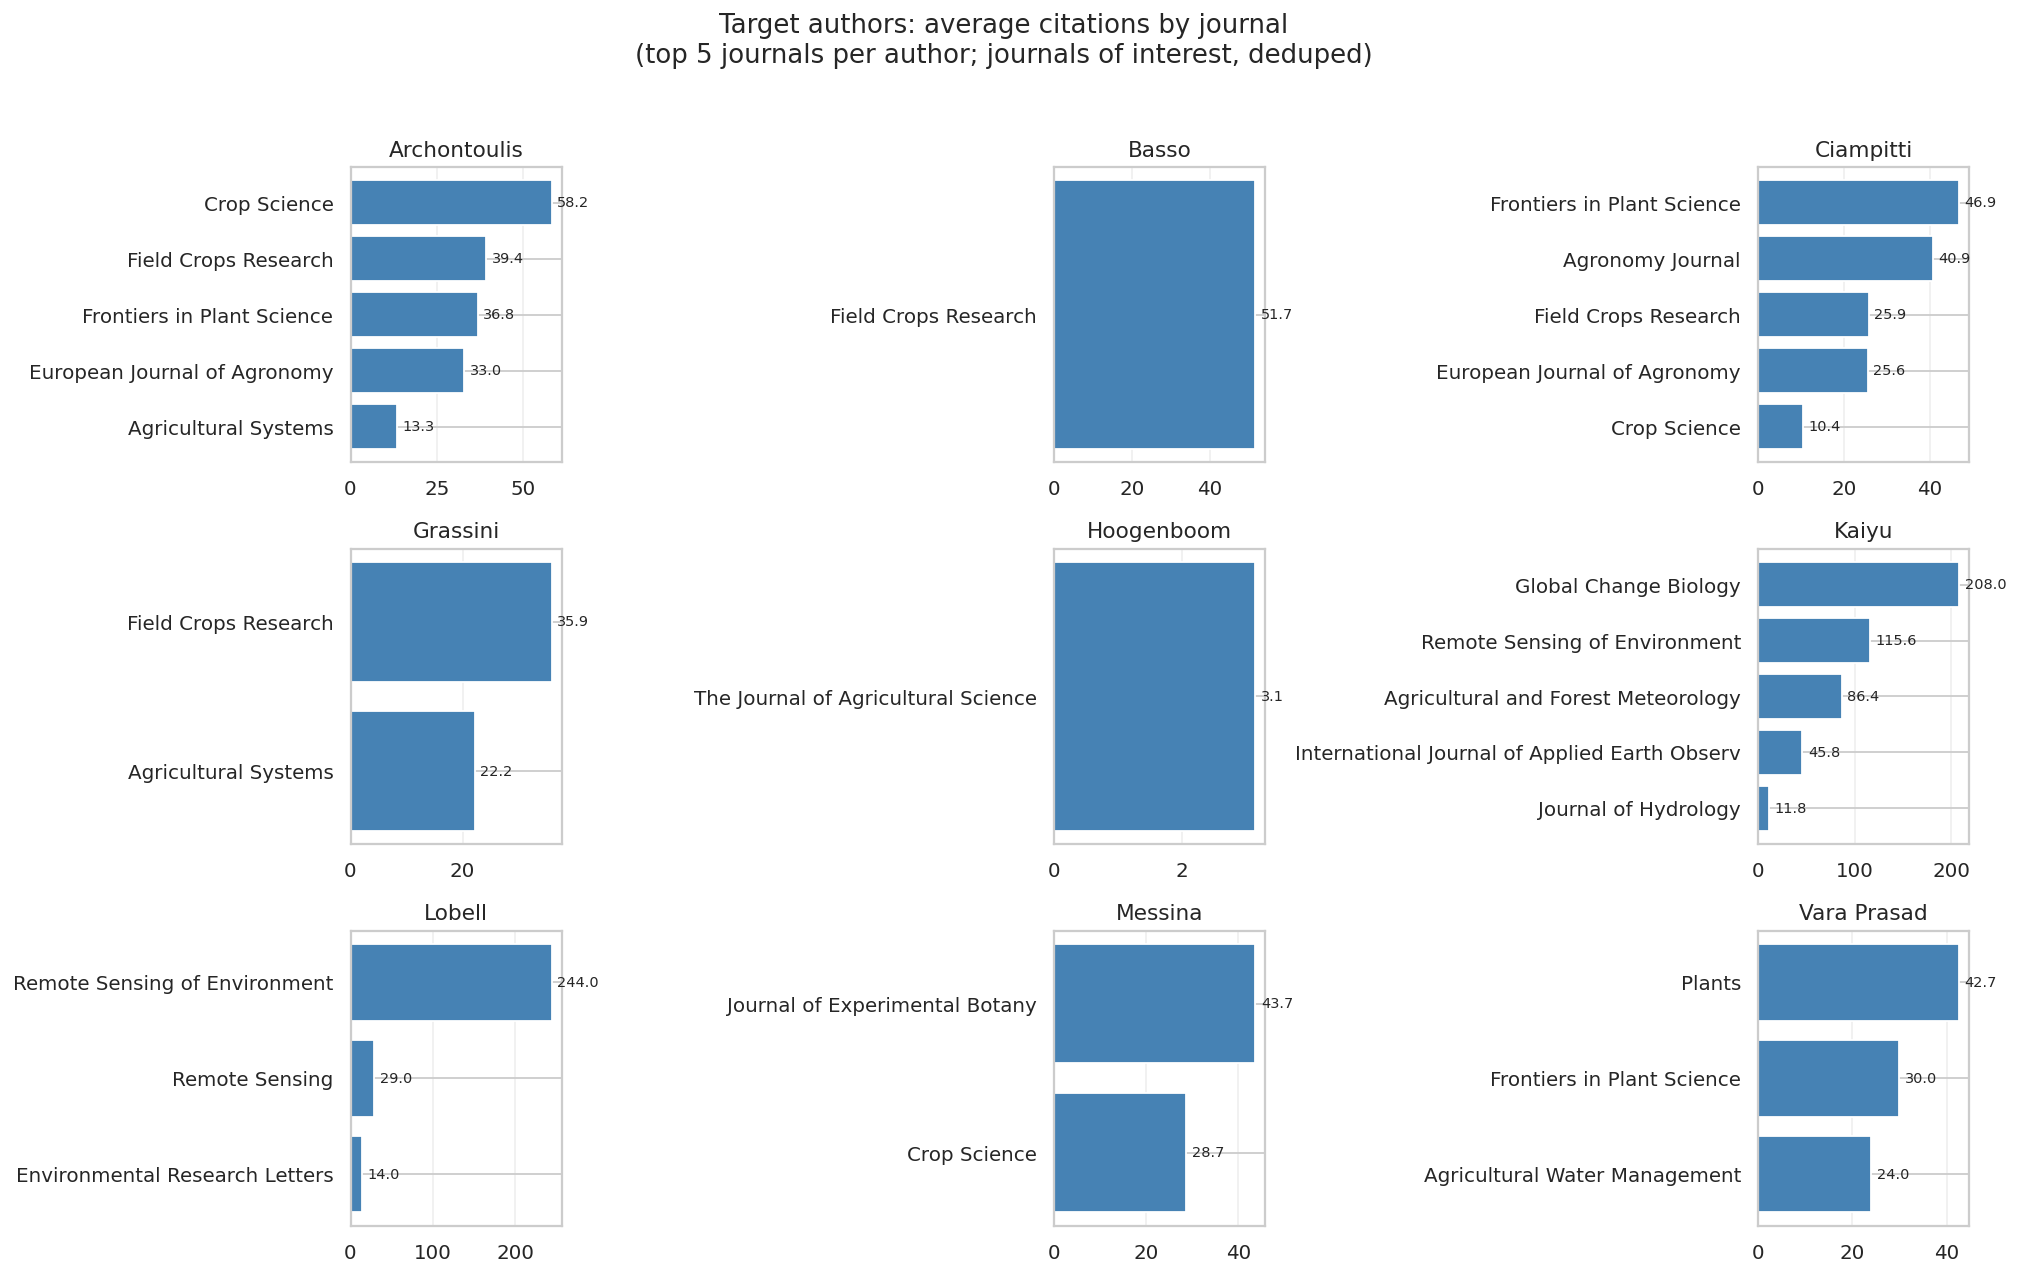

In [251]:
# ── Target authors: avg citations by journal (top 5 per author) ─────────────────
TOP_JOURNALS_PER_AUTHOR = 5

df_aj = (
    filtered_TargetA_df_corr
    .dropna(subset=["journal_display_name", "total_citations", "queried_author", "article_id"])
    .groupby(["queried_author", "journal_display_name"])
    .agg(
        n_papers=("article_id", "nunique"),
        avg_citations=("total_citations", "mean"),
        median_citations=("total_citations", "median"),
    )
    .reset_index()
)

mean_pair_papers = float(df_aj["n_papers"].mean()) if not df_aj.empty else 0.0
min_pair_papers = int(np.floor(mean_pair_papers)) + 1
df_aj = df_aj[df_aj["n_papers"] >= min_pair_papers].copy()
print(
    f"[author-journal pairs:target] mean papers={mean_pair_papers:.2f}, "
    f"threshold={min_pair_papers}, kept categories={len(df_aj)}"
)

# Keep top journals per author by paper count
Top_journals = (
    df_aj.sort_values(["queried_author", "n_papers", "avg_citations"], ascending=[True, False, False])
    .groupby("queried_author")
    .head(TOP_JOURNALS_PER_AUTHOR)
)

authors = Top_journals["queried_author"].unique().tolist()
n_authors = len(authors)

if n_authors == 0:
    print(f"No author-journal pairs met threshold (>= {min_pair_papers} papers per pair).")
else:
    ncols = 3
    nrows = int(np.ceil(n_authors / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.2 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    i = -1
    for i, author in enumerate(authors):
        ax = axes_flat[i]
        data = (
            Top_journals[Top_journals["queried_author"] == author]
            .sort_values("avg_citations", ascending=True)
        )
        bars = ax.barh(
            data["journal_display_name"].str[:45],
            data["avg_citations"],
            color="steelblue",
            edgecolor="white",
        )
        ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
        ax.set_title(author)
        ax.set_ylabel("")
        ax.grid(axis="x", alpha=0.3)

    # Hide unused axes
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle("Target authors: average citations by journal\n(top 5 journals per author; journals of interest, deduped)", y=1.02)
    plt.tight_layout()
    plt.show()

In [252]:
# ── Prepare paper-level base for IF plot (no journal list printout) ─────────────
CURRENT_YEAR = 2026

paper_if_base = (
    filtered_TargetA_df_corr
    .dropna(subset=["article_id", "queried_author", "journal_display_name", "publication_year", "total_citations"])
    .copy()
)

paper_if_base["paper_age_years"] = (CURRENT_YEAR - paper_if_base["publication_year"]).clip(lower=1)
paper_if_base["annual_citation_rate"] = paper_if_base["total_citations"] / paper_if_base["paper_age_years"]
paper_if_base["journal_name_norm"] = (
    paper_if_base["journal_display_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(f"Prepared papers for IF plot: {len(paper_if_base):,}")

Prepared papers for IF plot: 391


In [253]:
# ── Merge JOURNAL_IF_2025 into paper-level data ────────────────────────────────
# Expected columns in JOURNAL_IF_2025:
#   - journal_name (or journal_display_name)
#   - IF (or another IF-like column such as impact_factor)
if "JOURNAL_IF_2025" not in globals():
    raise NameError("JOURNAL_IF_2025 was not found. Run/create that dataframe first.")

journal_if = JOURNAL_IF_2025.copy()

if "journal_name" not in journal_if.columns:
    if "journal_display_name" in journal_if.columns:
        journal_if = journal_if.rename(columns={"journal_display_name": "journal_name"})
    else:
        raise ValueError("JOURNAL_IF_2025 must include 'journal_name' (or 'journal_display_name').")

if "IF" not in journal_if.columns:
    candidate_if_cols = [
        c for c in journal_if.columns
        if c.lower() in {"if", "impact_factor", "impactfactor", "journal_if", "jif", "if_2025"}
    ]
    if len(candidate_if_cols) == 1:
        journal_if = journal_if.rename(columns={candidate_if_cols[0]: "IF"})
    else:
        raise ValueError(
            "JOURNAL_IF_2025 must include an IF column. "
            f"Available columns: {list(journal_if.columns)}"
        )

journal_if["journal_name_norm"] = (
    journal_if["journal_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

journal_if_clean = (
    journal_if[["journal_name_norm", "IF"]]
    .dropna(subset=["journal_name_norm"])
    .drop_duplicates(subset=["journal_name_norm"], keep="last")
)

paper_if_plot = paper_if_base.merge(
    journal_if_clean,
    on="journal_name_norm",
    how="left",
)

print(f"Papers total: {len(paper_if_plot):,}")
print(f"Papers with IF from JOURNAL_IF_2025: {paper_if_plot['IF'].notna().sum():,}")
print(f"Papers missing IF: {paper_if_plot['IF'].isna().sum():,}")

Papers total: 391
Papers with IF from JOURNAL_IF_2025: 391
Papers missing IF: 0


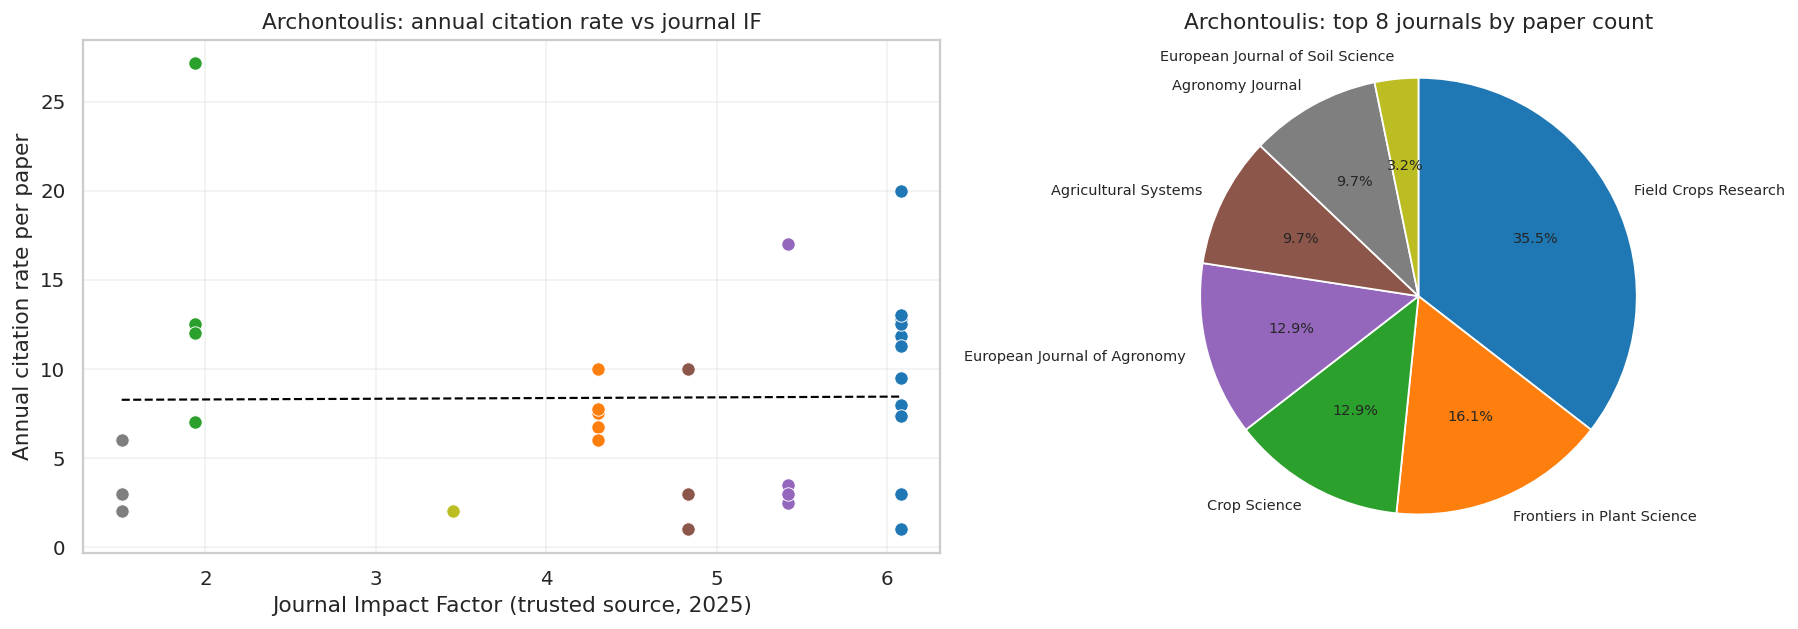

Archontoulis — slope: 0.039, intercept: 8.207, R²: 0.000, p-value: 0.9525


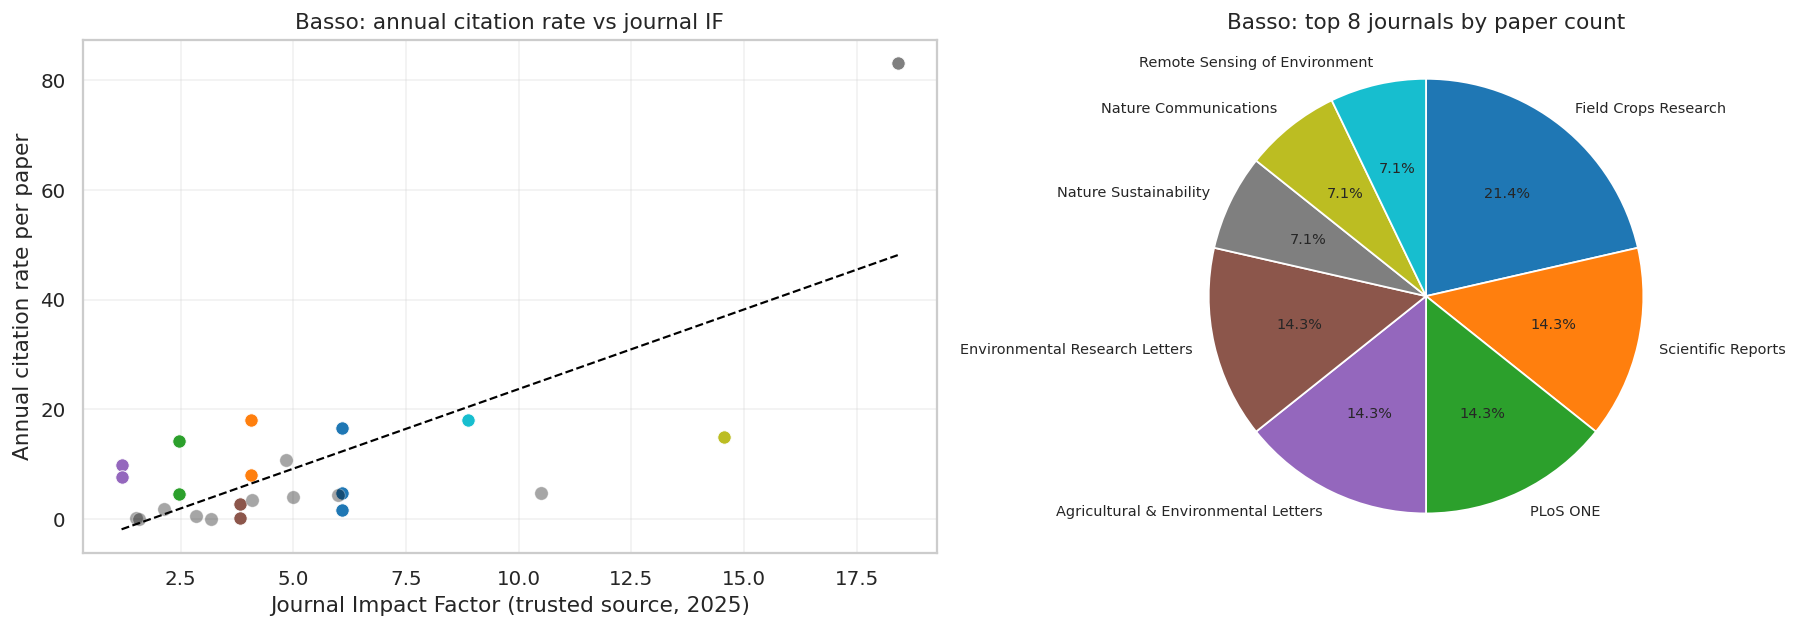

Basso — slope: 2.903, intercept: -5.321, R²: 0.533, p-value: 0.0001


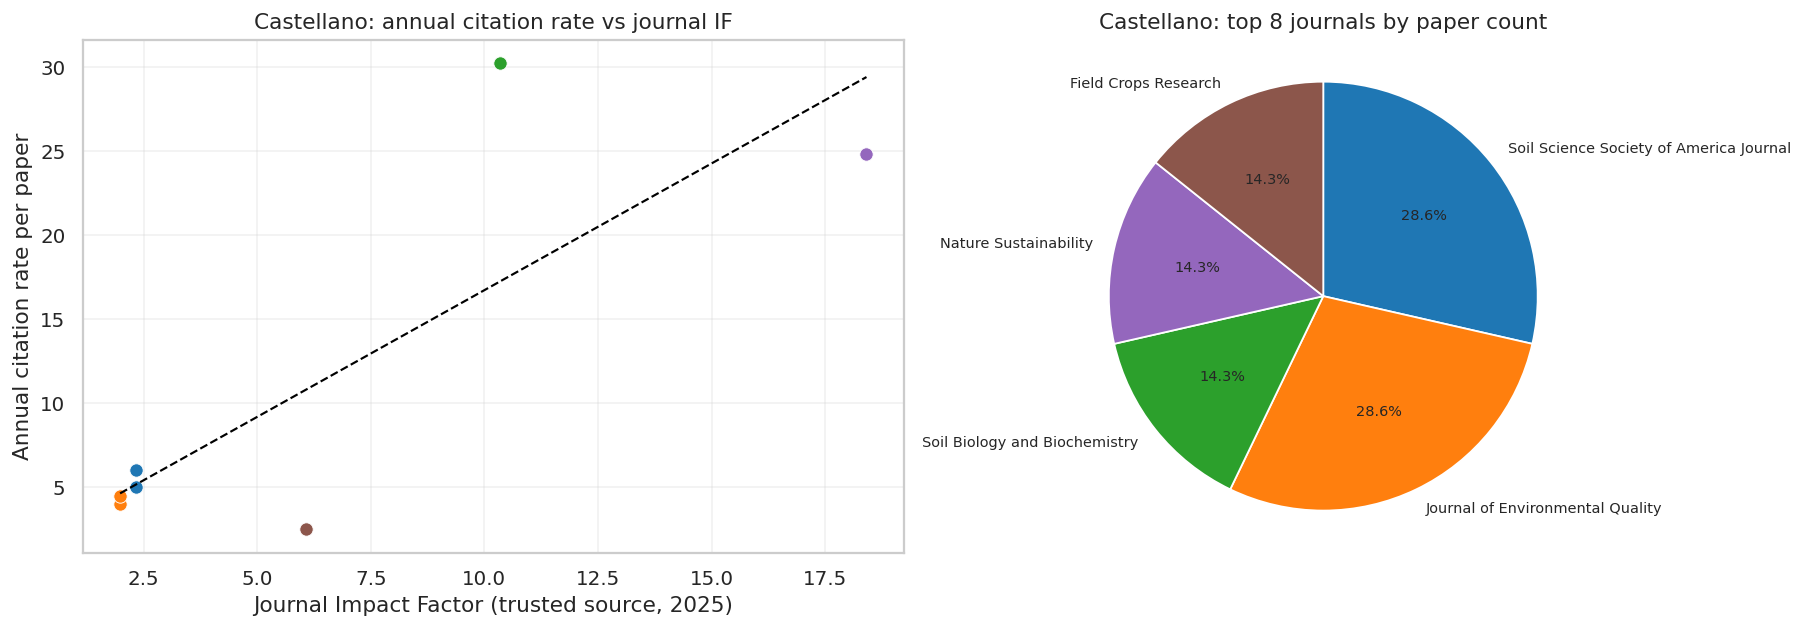

Castellano — slope: 1.508, intercept: 1.650, R²: 0.669, p-value: 0.0245


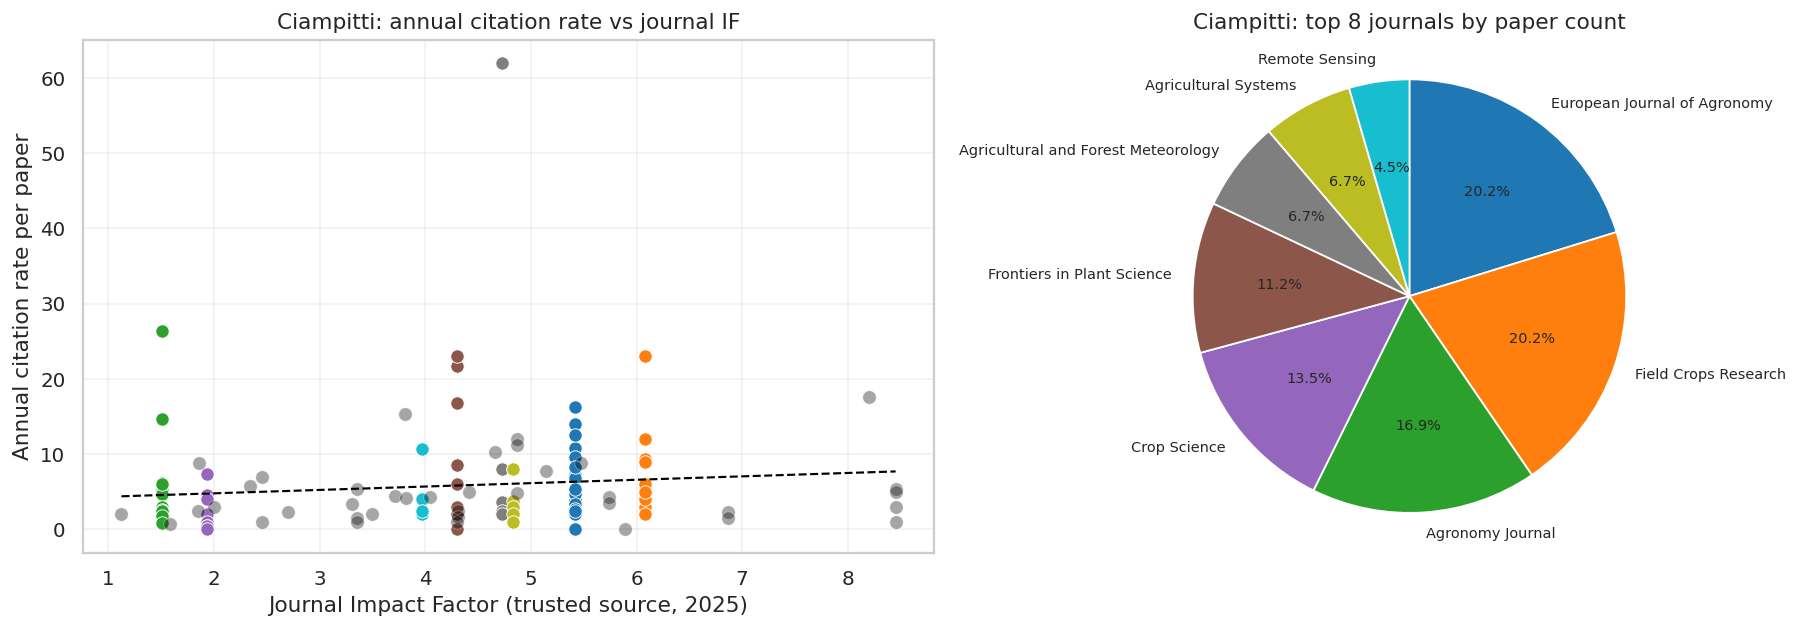

Ciampitti — slope: 0.451, intercept: 3.882, R²: 0.014, p-value: 0.1923


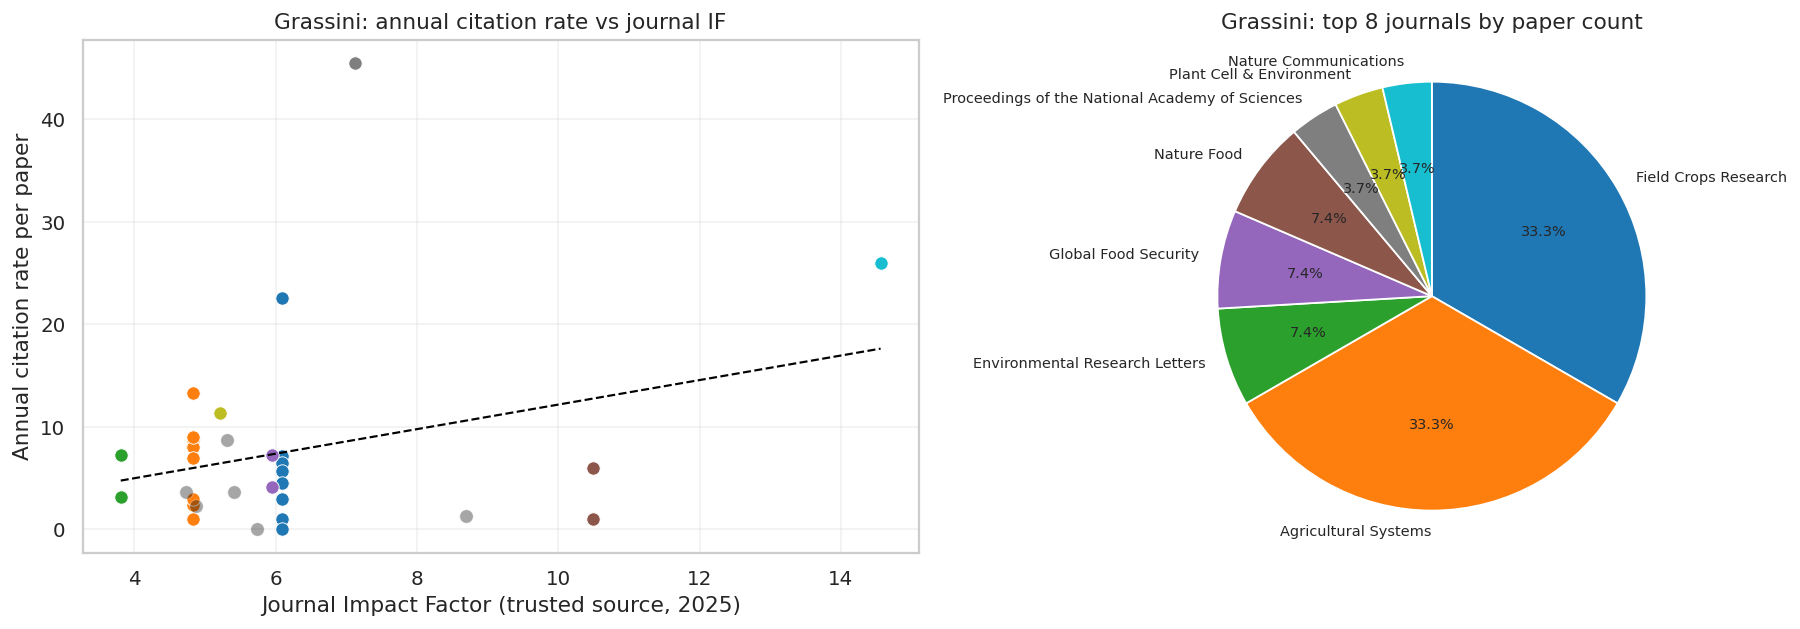

Grassini — slope: 1.197, intercept: 0.200, R²: 0.084, p-value: 0.1014


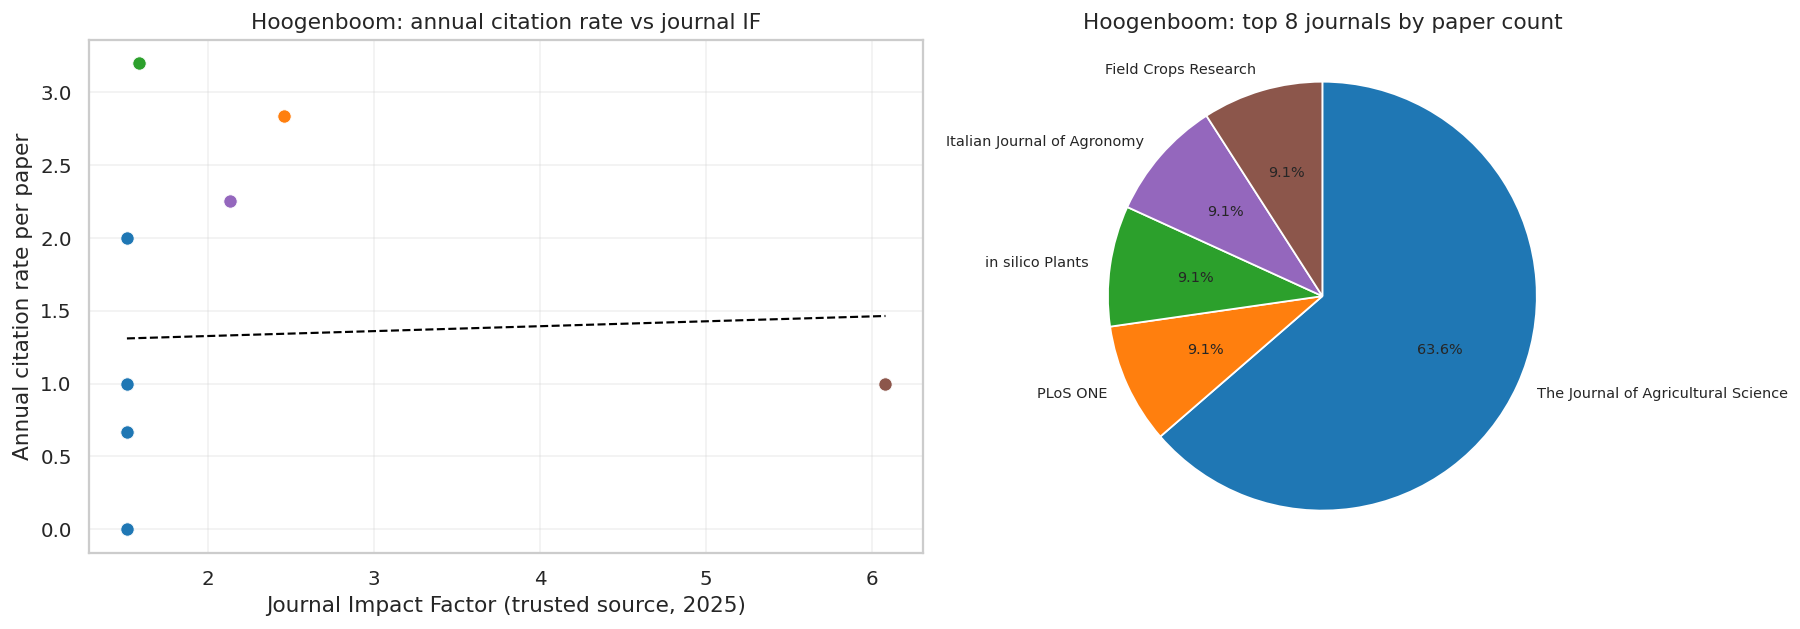

Hoogenboom — slope: 0.034, intercept: 1.259, R²: 0.002, p-value: 0.9015


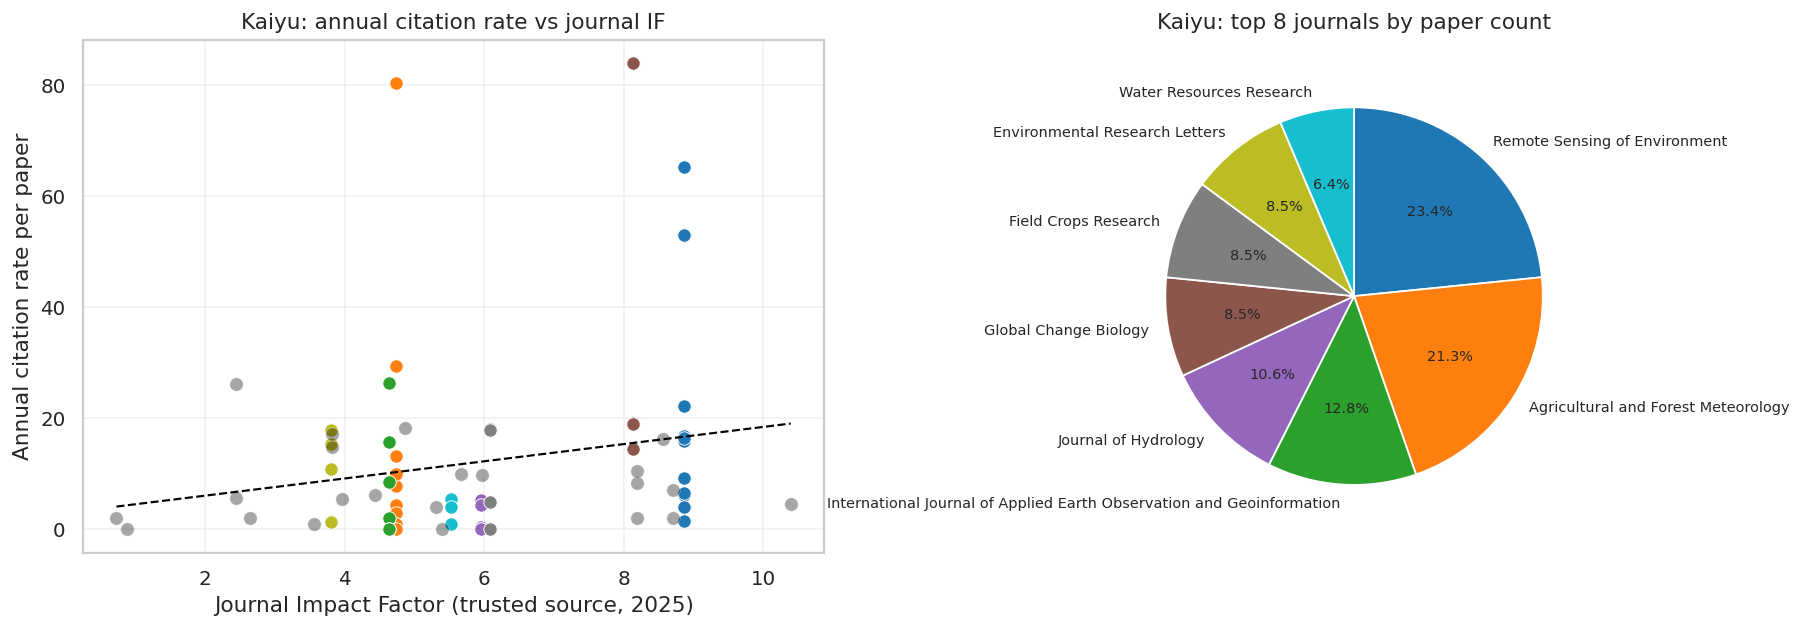

Kaiyu — slope: 1.548, intercept: 2.964, R²: 0.041, p-value: 0.0946


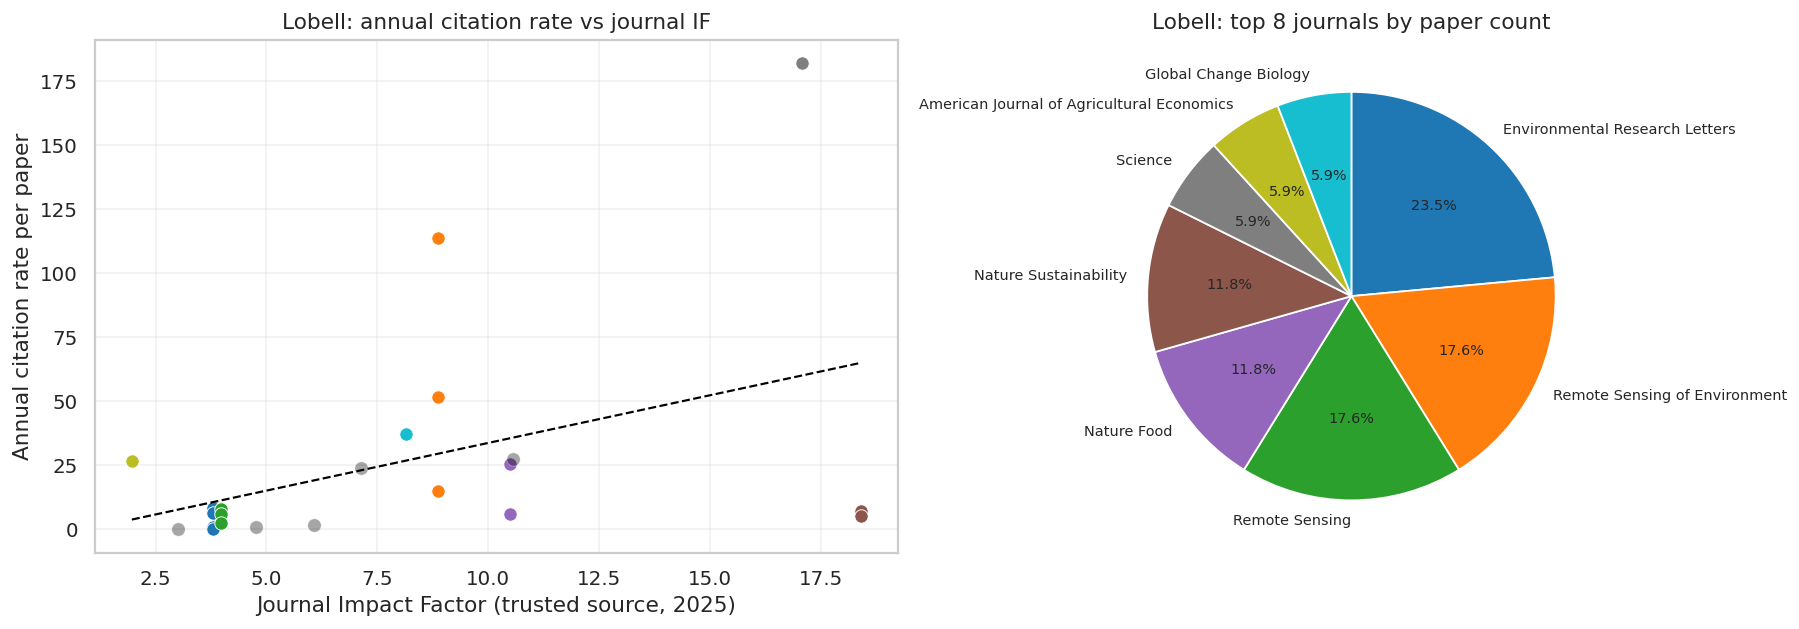

Lobell — slope: 3.721, intercept: -3.508, R²: 0.181, p-value: 0.0481


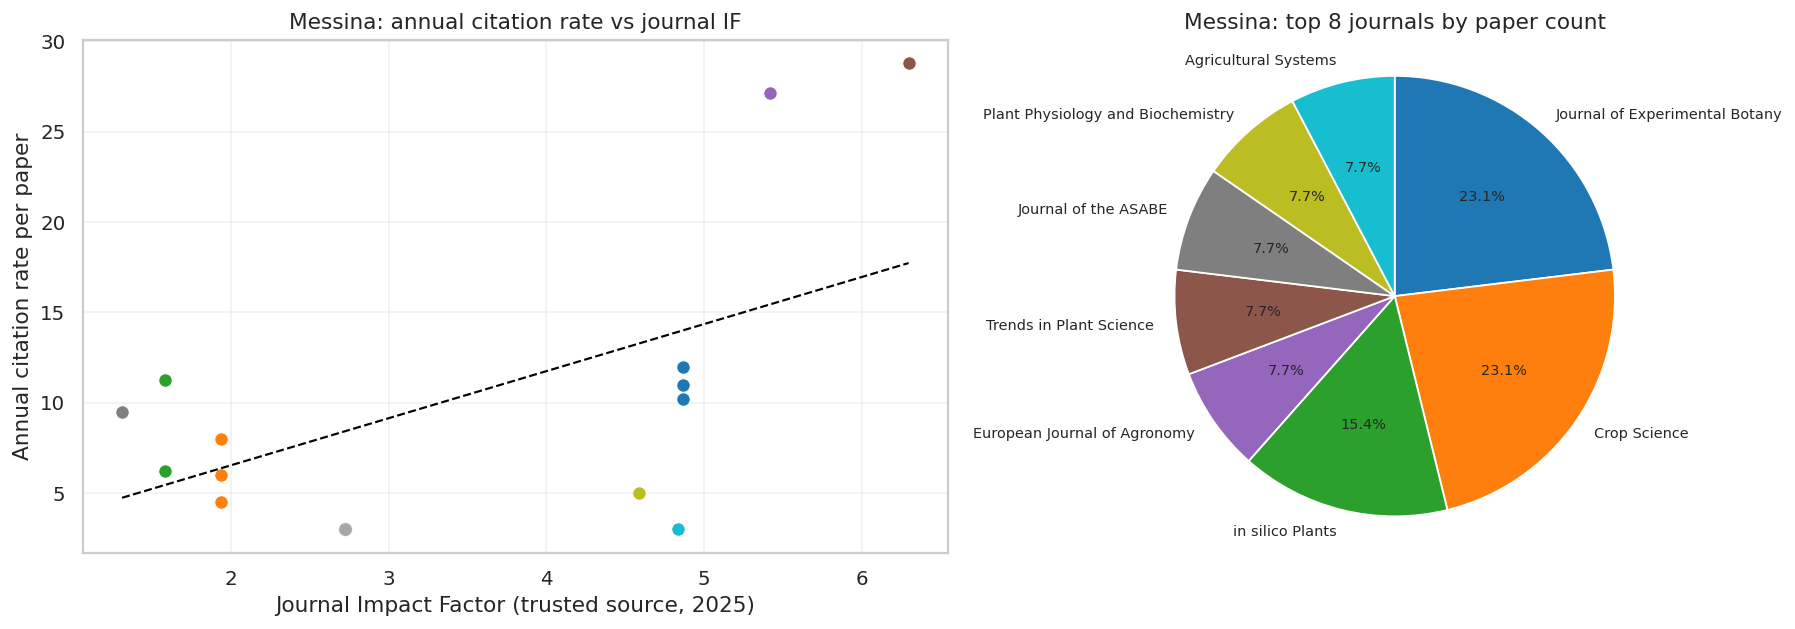

Messina — slope: 2.603, intercept: 1.340, R²: 0.324, p-value: 0.0336


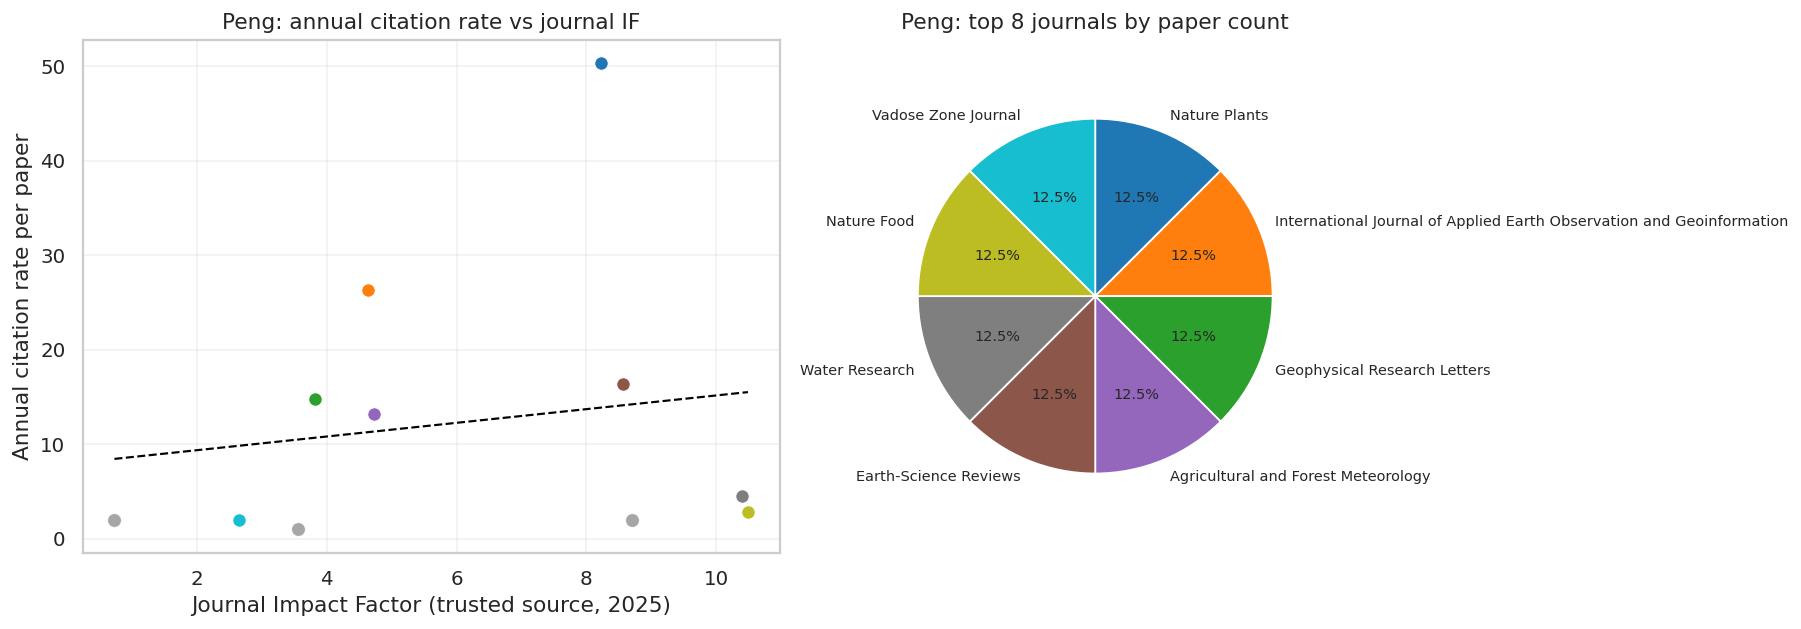

Peng — slope: 0.724, intercept: 7.919, R²: 0.026, p-value: 0.6370


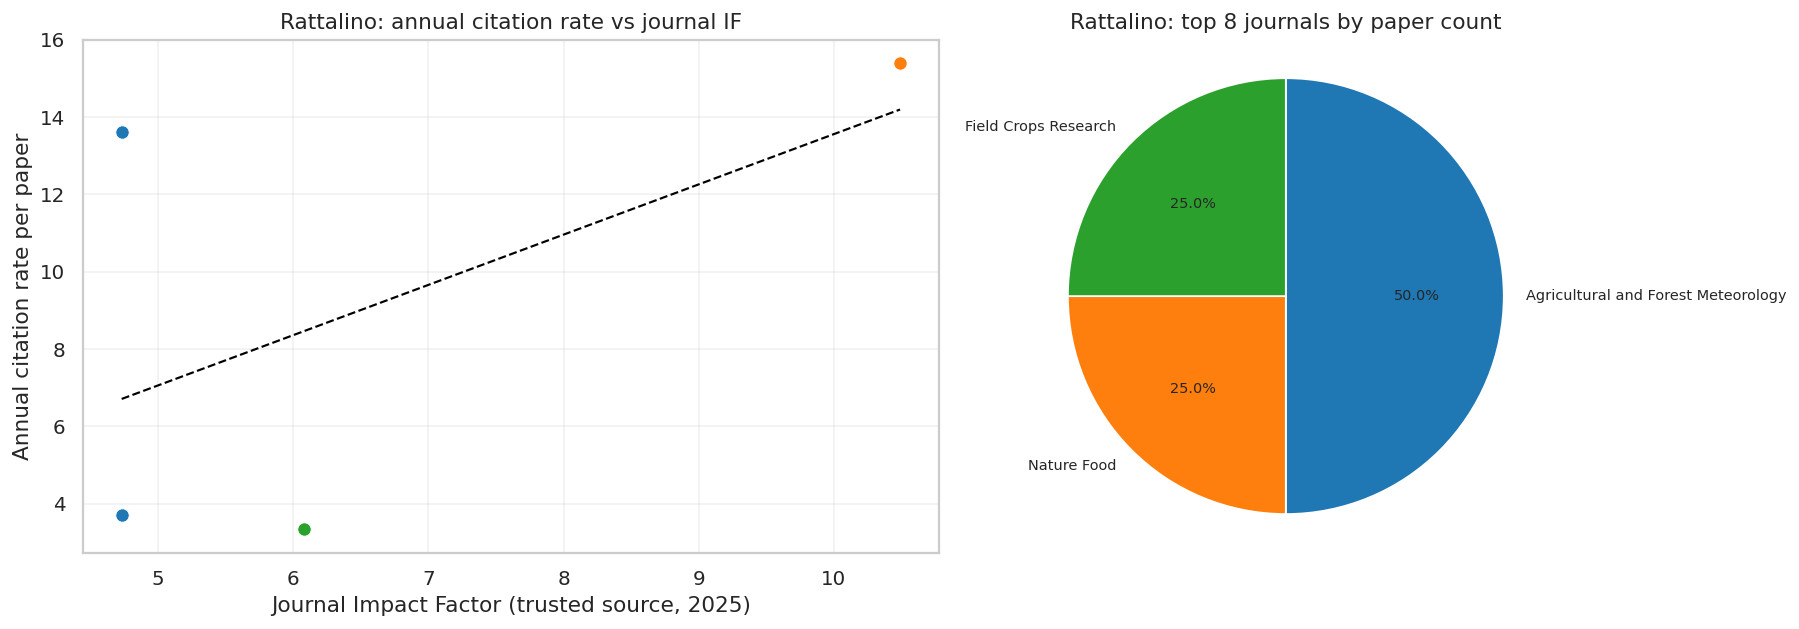

Rattalino — slope: 1.301, intercept: 0.553, R²: 0.309, p-value: 0.4443


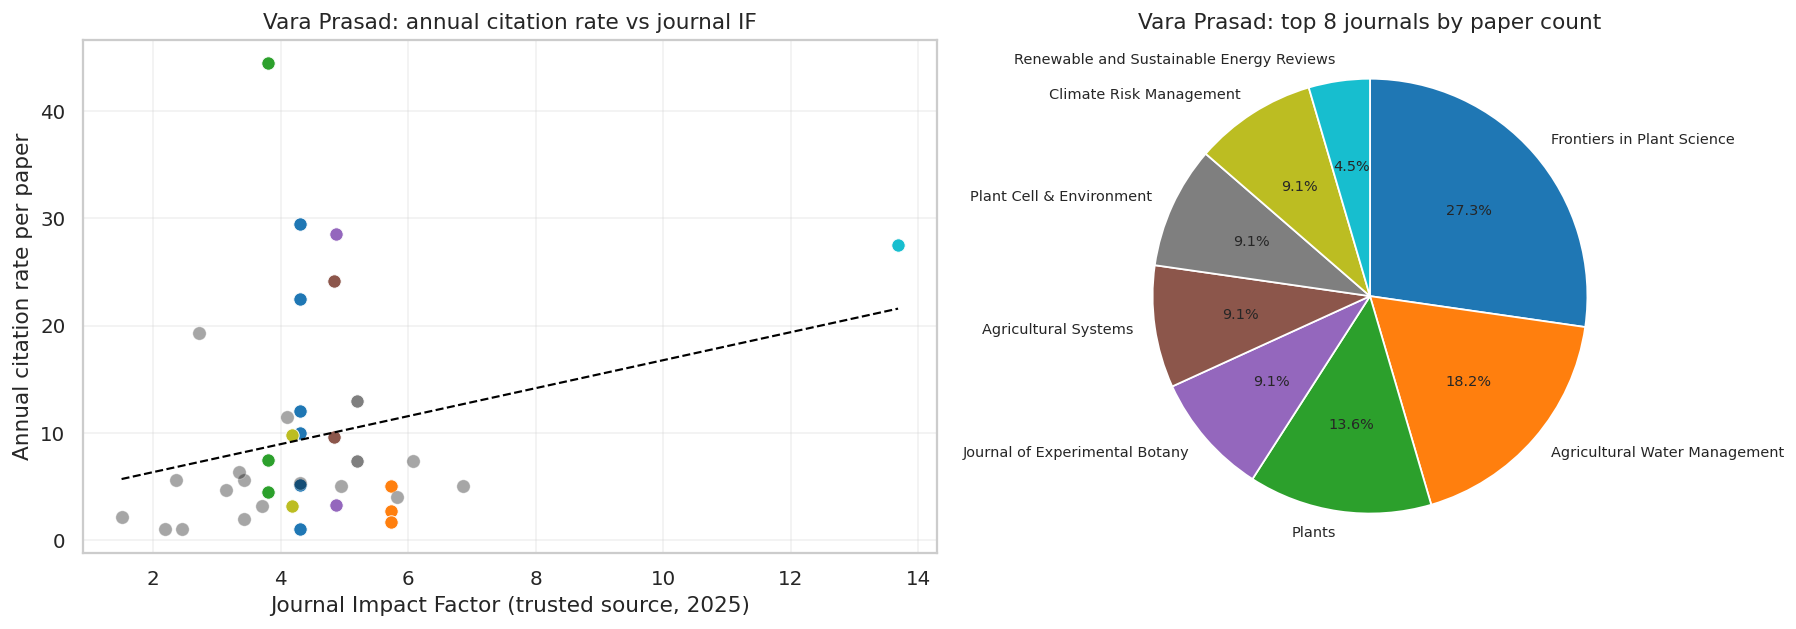

Vara Prasad — slope: 1.306, intercept: 3.718, R²: 0.064, p-value: 0.1248


In [180]:
# -- Plot papers: annual citation rate vs trusted journal IF (2025), one author at a time --
# Left panel: scatter with journal colors + legend
# Right panel: pie chart with journal share for the same author

plot_df_if = paper_if_plot.dropna(
    subset=["IF", "annual_citation_rate", "queried_author", journal_col]
).copy()



PIE_TOP_N = 8

authors_for_plot = sorted(plot_df_if["queried_author"].dropna().unique())

for author in authors_for_plot:
    author_df = plot_df_if[plot_df_if["queried_author"] == author].copy()
    if author_df.empty:
        continue

    x = author_df["IF"].to_numpy()
    y = author_df["annual_citation_rate"].to_numpy()

    # ── Color palette: top-8 get named colors, rest cycle through same palette ──
    journal_counts_all = author_df[journal_col].value_counts()
    all_journals = journal_counts_all.index.tolist()
    top8_journals = journal_counts_all.head(PIE_TOP_N).index.tolist()

    cmap = plt.cm.get_cmap("tab10", PIE_TOP_N)
    top8_color = {journal: cmap(i) for i, journal in enumerate(top8_journals)}

    # Non-top-8 journals get black
    def get_color(journal):
        if journal in top8_color:
            return top8_color[journal]
        return "black"

    fig, (ax_scatter, ax_pie) = plt.subplots(
        1, 2,
        figsize=(14, 5),
        gridspec_kw={"width_ratios": [2.5, 1.4]},
    )

    # ── Scatter: ALL journals plotted, top-8 labeled in legend ──────────
    for journal in all_journals:
        grp = author_df[author_df[journal_col] == journal]
        is_top8 = journal in top8_journals
        ax_scatter.scatter(
            grp["IF"], grp["annual_citation_rate"],
            color=get_color(journal),
            alpha=1 if is_top8 else 0.35,
            s=55,
            edgecolors="white", linewidth=0.5,
            label=journal if is_top8 else "_nolegend_",
        )

    # ── Regression line ──────────────────────────────────────────────────
    if len(author_df) >= 2 and np.unique(x).size > 1:
        slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
        r_squared = r_value ** 2
        x_line = np.linspace(x.min(), x.max(), 200)
        ax_scatter.plot(
            x_line, slope * x_line + intercept,
            color="black", linewidth=1.2, linestyle="--",
            label=f"Regression ($R^2 = {r_squared:.2f}$)",
        )
        stats_text = (
            f"{author} — slope: {slope:.3f}, intercept: {intercept:.3f}, "
            f"R²: {r_squared:.3f}, p-value: {p_value:.4f}"
        )
    else:
        stats_text = f"{author} — not enough variation in IF for regression"

    ax_scatter.set_xlabel("Journal Impact Factor (trusted source, 2025)")
    ax_scatter.set_ylabel("Annual citation rate per paper")
    ax_scatter.set_title(f"{author}: annual citation rate vs journal IF")
    ax_scatter.grid(alpha=0.25)
    # ax_scatter.legend(
    #     fontsize=7, loc="upper left",
    #     framealpha=0.7, markerscale=1.1,
    # )

    # ── Pie chart: top-8 only, same colors ──────────────────────────────
    pie_counts = journal_counts_all.head(PIE_TOP_N)
    pie_colors = [top8_color[j] for j in pie_counts.index]

    ax_pie.pie(
        pie_counts.values,
        labels=pie_counts.index.tolist(),
        colors=pie_colors,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        textprops={"fontsize": 8},
    )
    ax_pie.set_title(f"{author}: top {PIE_TOP_N} journals by paper count")
    ax_pie.axis("equal")

    plt.tight_layout()
    plt.show()
    print(stats_text)